# Data Pipeline Exploration

How `df_master` was assembled, stat family by stat family — ingestion, integrity checks, and exploratory analysis across the NBA Stats endpoints. This notebook documents the data-engineering work behind the model; the modeling pipeline itself lives in `01_modeling.ipynb`.

> Note: cells here re-fetch from the NBA Stats API. They are exploratory and not meant to be run end-to-end; the finished master is cached to parquet.

# NBA Stats API Data Sources

## LeagueDashPlayerStats - General

### Base & Advanced Player Stats

In [22]:
seasons = ["2024-25", "2025-26"]

#master_registry = get_multi_season_registry(seasons)

df_master = build_master_df(
    seasons=['2024-25', '2025-26'],
    stat_types=['Base', 'Advanced'],
    season_types=('Regular Season', 'Playoffs')
)

check_master_integrity(df_master)


📅 Building Regular Season master...
DEBUG: Routing Base to source: player
📂 Loading cache: nba_stats_player_base_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_player_base_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Advanced to source: player
📂 Loading cache: nba_stats_player_advanced_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_player_advanced_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)

📅 Building Playoffs master...
DEBUG: Routing Base to source: player
📂 Loading cache: nba_stats_player_base_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_player_base_2025-26_playoffs_player_pergame_offens

In [23]:
df_master.columns[0:100]

Index(['index', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'DD2',
       'TD3', 'TEAM_COUNT', 'OFF_RATING', 'DEF_RATING', 'NET_RATING',
       'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT',
       'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'PIE', 'POSS', 'FGM_PG', 'FGA_PG'],
      dtype='object')

In [24]:
df_master.xs(('2025-26', 'Playoffs', ),
                         level=('SEASON', 'SEASON_TYPE')).query("MIN>=10")['EFG_PCT'].describe()

count    146.000000
mean       0.525199
std        0.112430
min        0.179000
25%        0.470000
50%        0.510500
75%        0.584500
max        0.929000
Name: EFG_PCT, dtype: float64

In [25]:
df_master.xs(('2025-26', 'Playoffs', ),
                         level=('SEASON', 'SEASON_TYPE')).query("MIN>=10")['TS_PCT'].describe()

count    146.000000
mean       0.557267
std        0.104712
min        0.235000
25%        0.501250
50%        0.556000
75%        0.608750
max        0.931000
Name: TS_PCT, dtype: float64

In [26]:
df_master.xs(('2025-26', 'Playoffs', ),
                         level=('SEASON', 'SEASON_TYPE'))\
                         .sort_values('PTS', ascending=False)\
                          [['GP','MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV',\
                            'FGA','FG_PCT', 'FG3A','FG3_PCT','FTA', 'FT_PCT',\
                            'EFG_PCT','TS_PCT','USG_PCT', 'TM_TOV_PCT']].iloc[0:60]

,,,,GP,MIN,PTS,REB,AST,STL,BLK,TOV,FGA,FG_PCT,FG3A,FG3_PCT,FTA,FT_PCT,EFG_PCT,TS_PCT,USG_PCT,TM_TOV_PCT
PLAYER_NAME,PLAYER_ID,TEAM_ABBREVIATION,TEAM_ID,,,,,,,,,,,,,,,,,,
Jalen Brunson,1628973,NYK,1610612752,19,36.9,28.4,3.2,6.1,1.2,0.0,2.7,21.7,0.465,6.5,0.363,6.8,0.846,0.519,0.573,0.317,8.0
Cade Cunningham,1630595,DET,1610612765,14,40.8,28.1,5.1,7.5,1.1,0.6,5.6,21.0,0.432,7.3,0.402,8.2,0.861,0.502,0.572,0.315,15.0
Shai Gilgeous-Alexander,1628983,OKC,1610612760,15,36.3,27.6,2.9,7.9,1.3,0.9,3.1,19.0,0.463,3.9,0.305,9.9,0.892,0.495,0.591,0.308,8.9
Paolo Banchero,1631094,ORL,1610612753,7,39.0,26.3,9.0,6.3,1.4,0.7,3.4,20.4,0.420,6.0,0.333,10.6,0.676,0.469,0.524,0.314,9.9
Donovan Mitchell,1628378,CLE,1610612739,18,36.2,26.0,4.8,3.1,1.2,0.3,2.6,21.1,0.451,8.7,0.327,5.1,0.815,0.518,0.558,0.306,9.0
Dillon Brooks,1628415,PHX,1610612756,4,37.3,26.0,6.0,1.8,0.3,0.3,1.5,21.3,0.459,8.0,0.438,3.0,1.000,0.541,0.576,0.268,5.9
Nikola Jokic,203999,DEN,1610612743,6,39.5,25.8,13.2,9.5,1.0,0.8,3.8,20.2,0.446,6.0,0.194,7.2,0.930,0.475,0.554,0.295,10.5
Jaylen Brown,1627759,BOS,1610612738,7,35.6,25.7,5.7,3.3,0.9,1.1,3.6,20.4,0.455,6.0,0.405,6.6,0.717,0.514,0.551,0.325,11.9
Scottie Barnes,1630567,TOR,1610612761,7,39.0,24.1,6.1,8.6,1.1,1.7,3.4,16.6,0.509,3.0,0.381,7.7,0.796,0.543,0.605,0.256,10.7


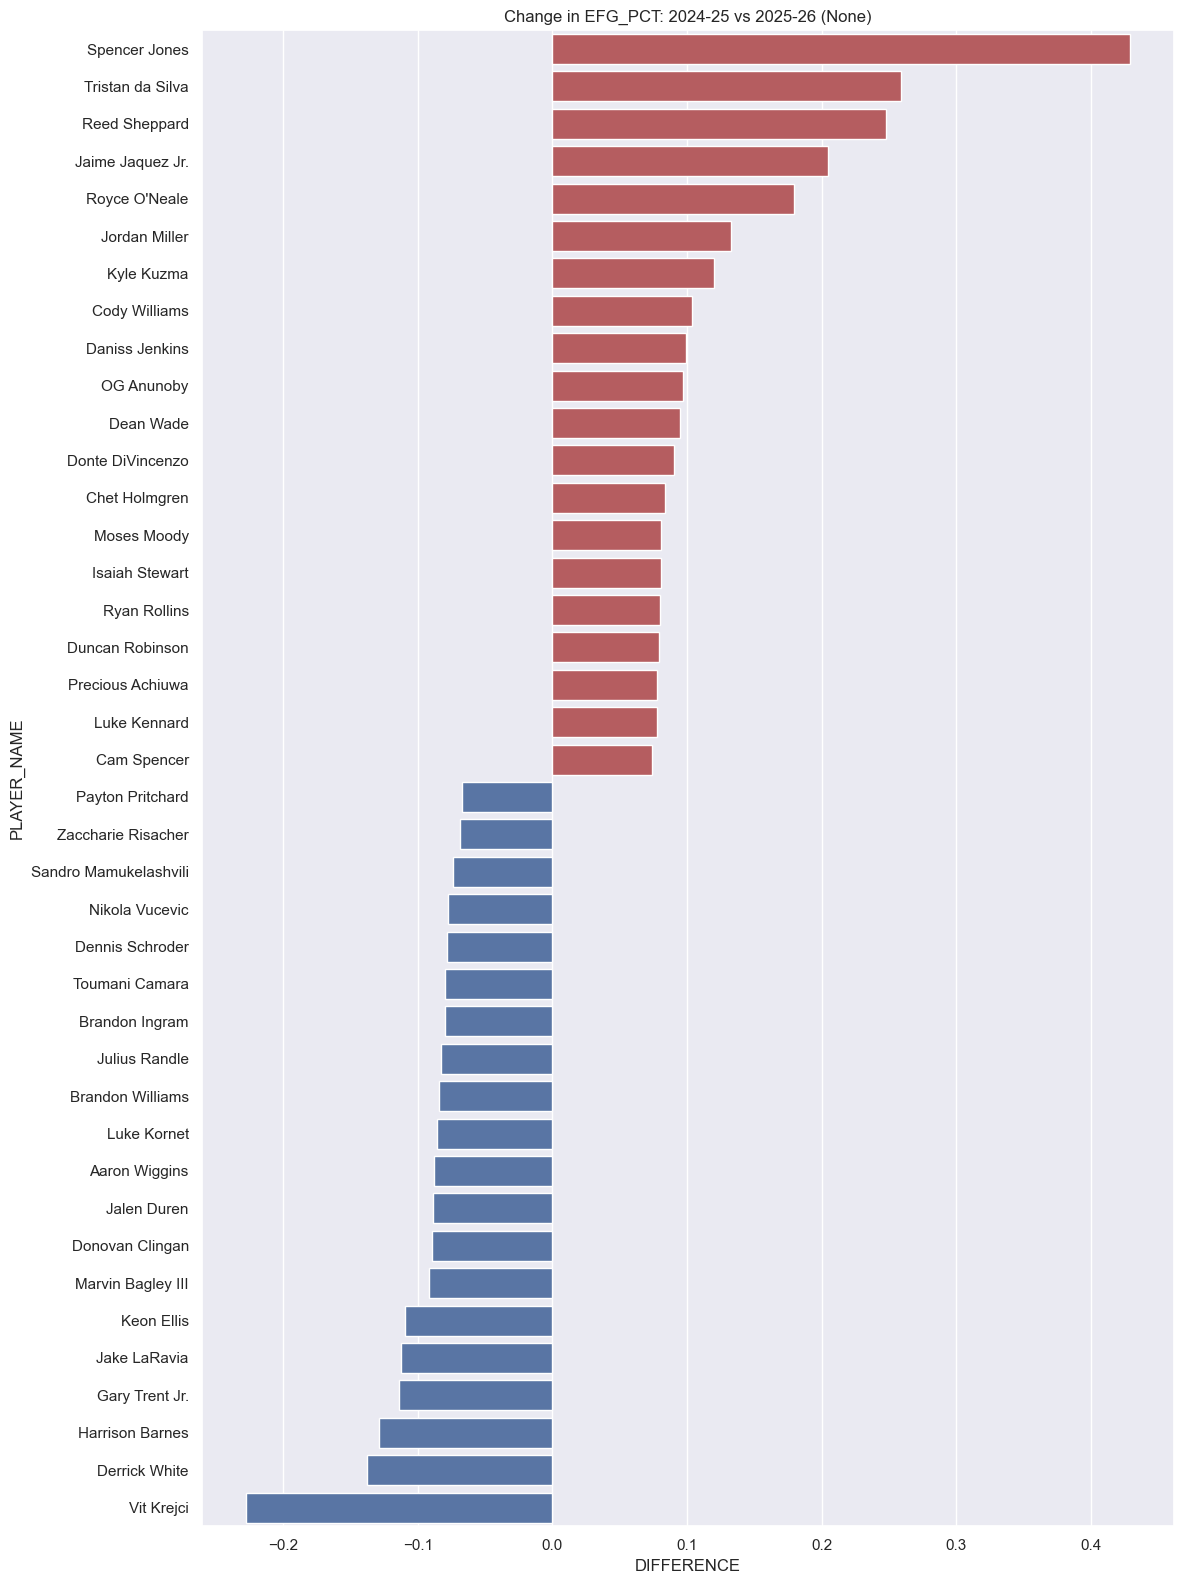

In [27]:
filters = [
    "SEASON_TYPE == 'Regular Season'",
    "GP >= 58",
    "MIN >= 20"
]
df_results, fig = analyze_player_changes(
    df=df_master,
    compare_col='SEASON',
    base='2024-25',
    comp='2025-26',
    stat_column='EFG_PCT',
    query_conditions=filters,
    season_filter=None,# ← add this
    palette='coolwarm_r',
    n=20
)

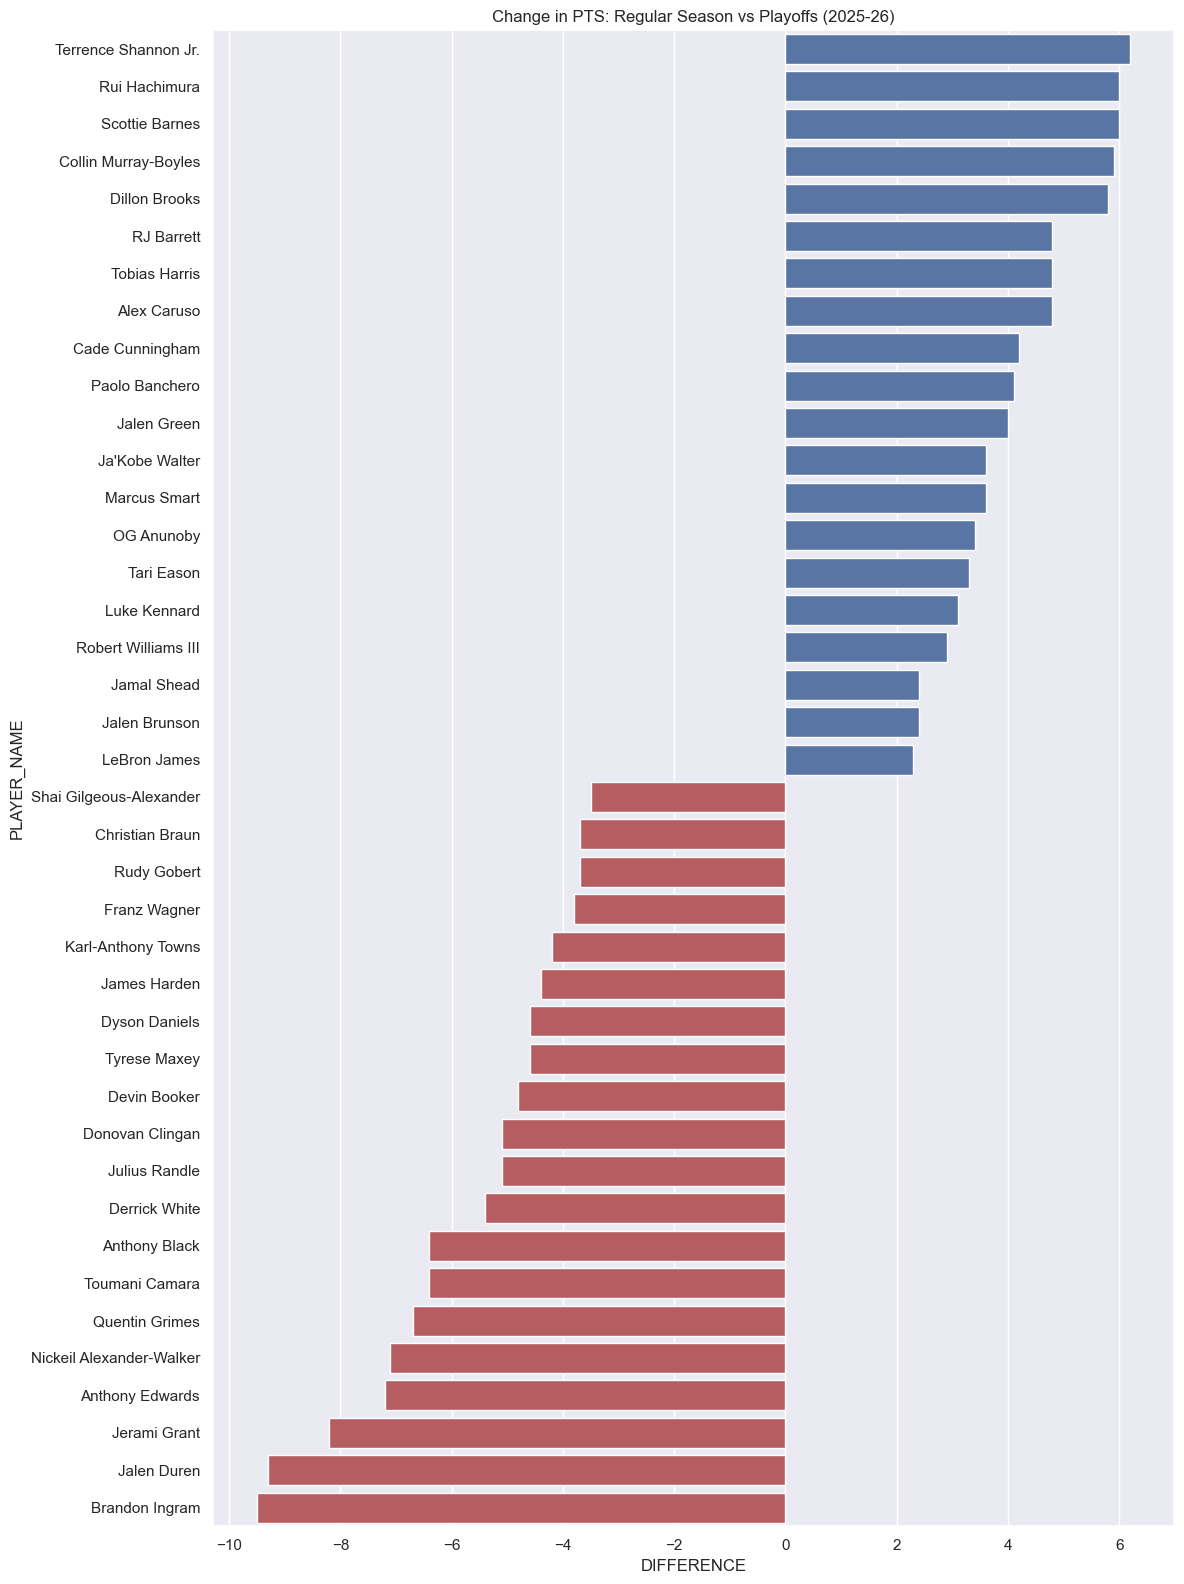

In [28]:
# Define your filters clearly
filters = [
    "MIN >= 20",
    "GP >= 4",
    # "FG3A >= 2"
]

# Call the function
df_results, fig = analyze_player_changes(
    df=df_master,
    compare_col='SEASON_TYPE',
    base='Regular Season',
    comp='Playoffs',
    season_filter='2025-26',  # locks to one season internally
    stat_column='PTS',
    query_conditions=filters,
    palette='coolwarm',
    n=20
)

In [29]:
plot = plot_interactive_barh(
    df=df_master.reset_index(), # reset_index if your data is MultiIndexed
    x_col='EFG_PCT',
    y_col='PLAYER_NAME',
    season='2025-26',
    season_type = 'Playoffs',
    title="Interactive EFG% Leaderboard",
    query_condition="MIN >= 20"
)

plot

:Bars   [PLAYER_NAME]   (EFG_PCT)

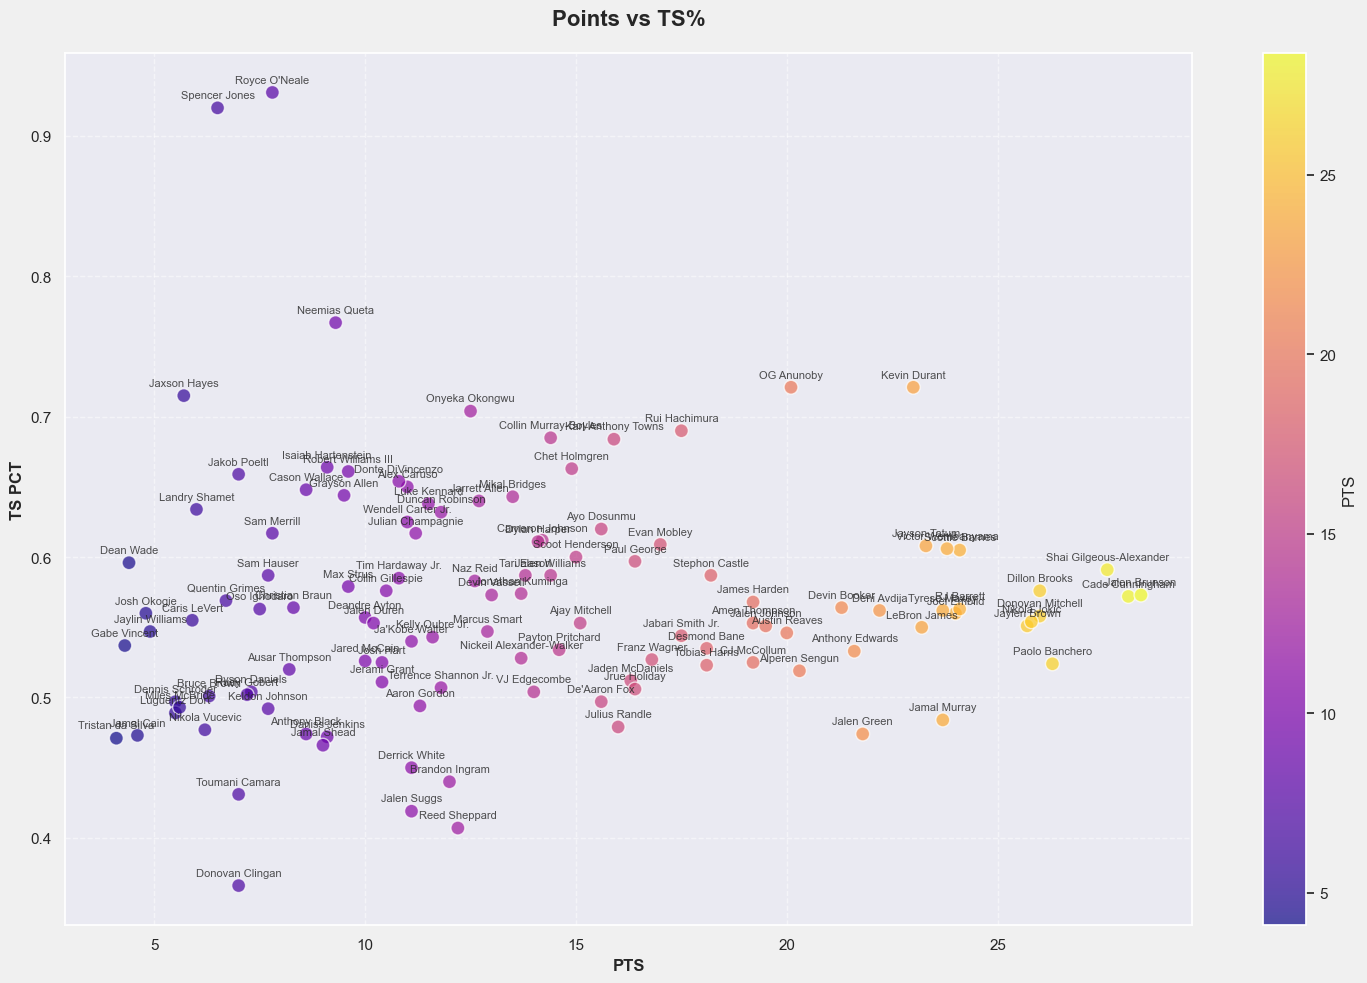

In [30]:
scatter_nba_stats(df_master, 'PTS', 'TS_PCT', '2025-26',
                  season_type = 'Playoffs',
                  color_stat='PTS', min_min=15,
                  title='Points vs TS%')

### Usage

In [31]:
df_master = ingest_nba_stat(
    df_master,
    'Usage',
    ['2024-25', '2025-26']
)

DEBUG: Routing Usage to source: player
📂 Loading cache: nba_stats_player_usage_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_player_usage_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Usage to source: player
📂 Loading cache: nba_stats_player_usage_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_player_usage_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_usage_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [32]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 67)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [33]:
df_master.columns

Index(['index', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'DD2',
       'TD3', 'TEAM_COUNT', 'OFF_RATING', 'DEF_RATING', 'NET_RATING',
       'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT',
       'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'USG_PCT', 'E_PACE', 'PACE',
       'PACE_PER40', 'PIE', 'POSS', 'FGM_PG', 'FGA_PG', 'PCT_FGM', 'PCT_FGA',
       'PCT_FG3M', 'PCT_FG3A', 'PCT_FTM', 'PCT_FTA', 'PCT_OREB', 'PCT_DREB',
       'PCT_REB', 'PCT_AST', 'PCT_TOV', 'PCT_STL', 'PCT_BLK', 'PCT_BLKA',
       'PCT_PF', 'PCT_PFD', 'PCT_PTS'],
      dtype='object')

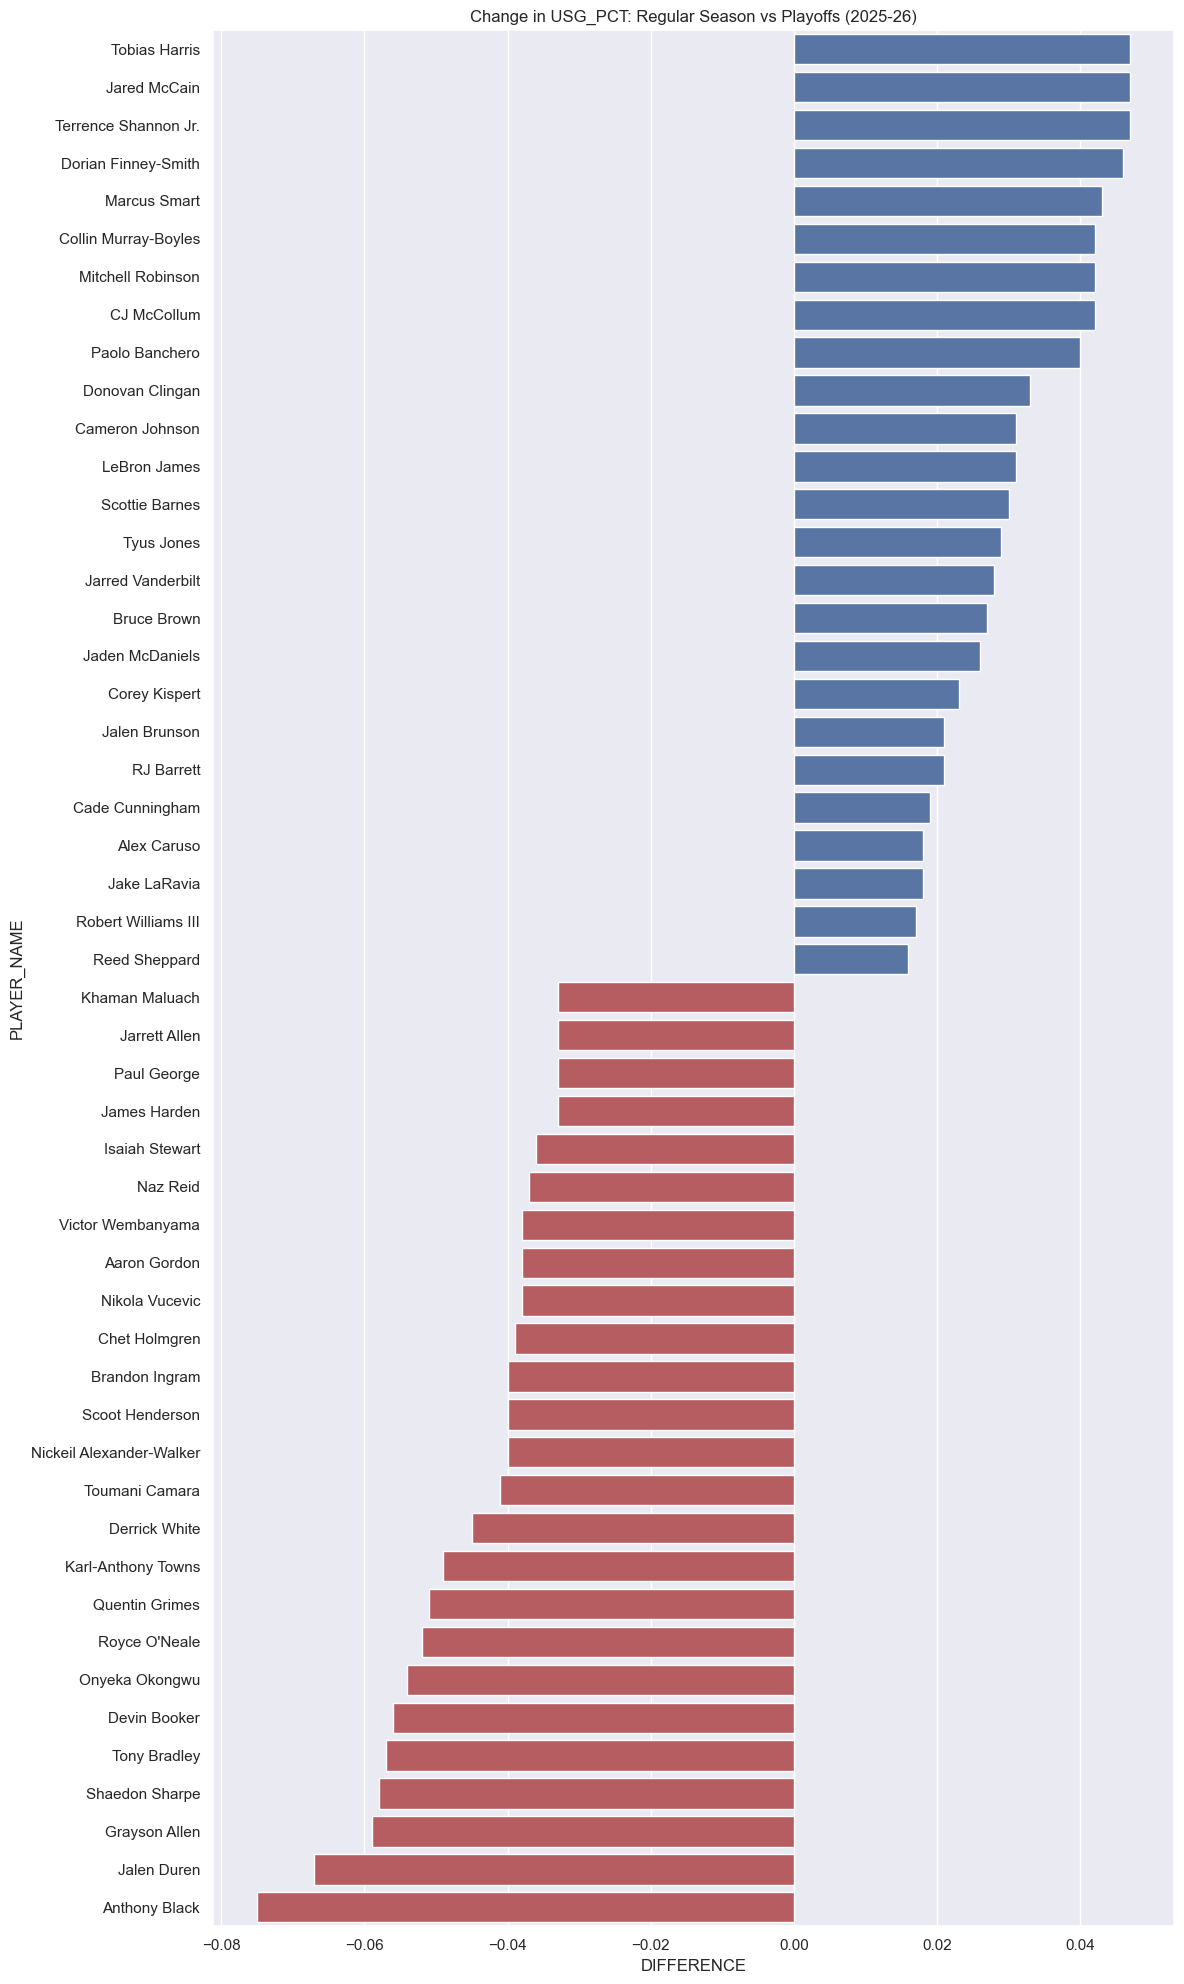

In [34]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='USG_PCT',
        query_conditions=["MIN >= 10"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

### Scoring

In [35]:
df_master = ingest_nba_stat(
    df_master,
    'Scoring',
    ['2024-25', '2025-26']
)

DEBUG: Routing Scoring to source: player
📂 Loading cache: nba_stats_player_scoring_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_player_scoring_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Scoring to source: player
📂 Loading cache: nba_stats_player_scoring_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_player_scoring_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_scoring_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [36]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 82)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [37]:
df_master.columns[160:]

Index([], dtype='object')

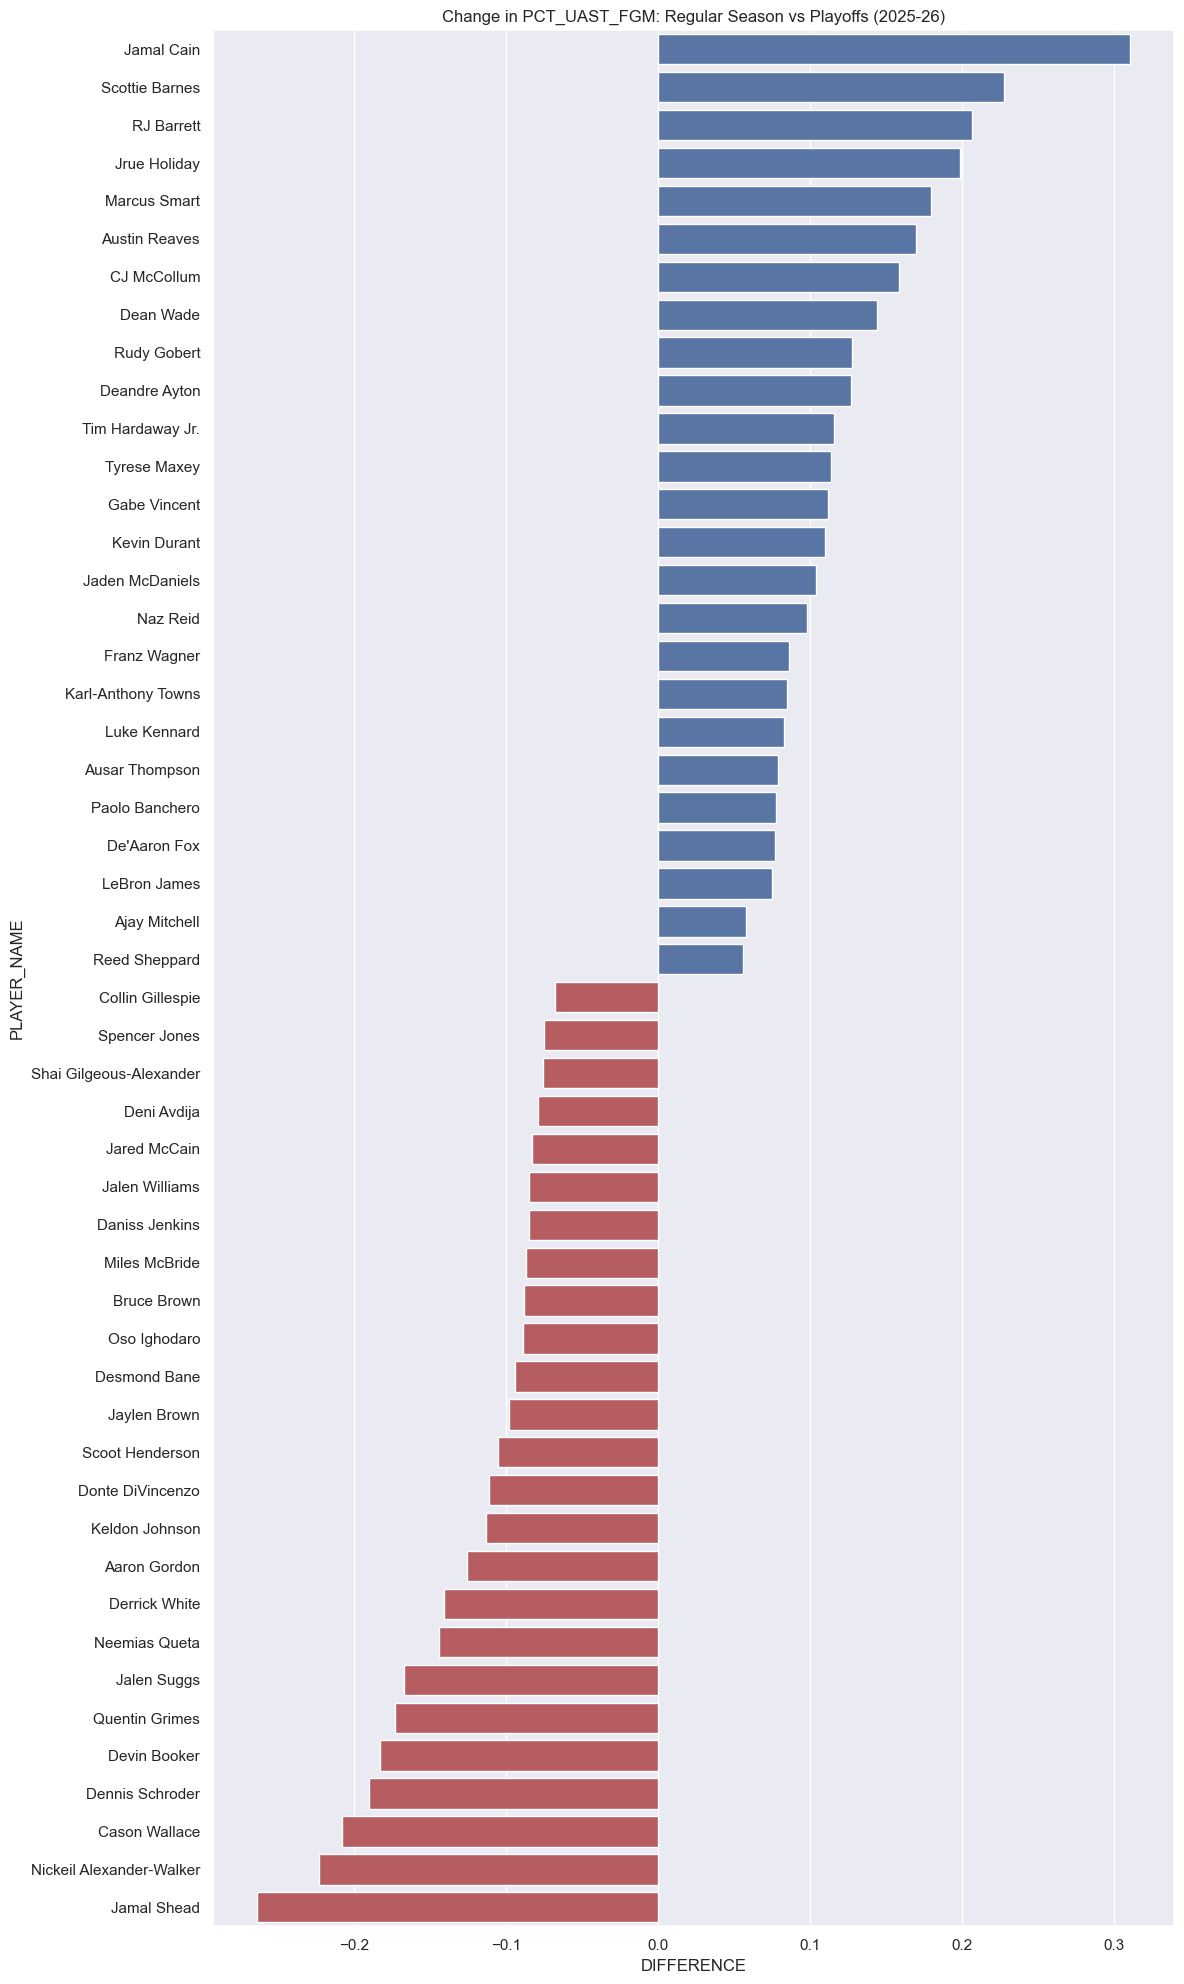

In [38]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='PCT_UAST_FGM',
        query_conditions=["MIN >= 15"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

In [39]:
scatter_nba_stats(plot_df_temp, 'PCT_PTS_PAINT', 'PCT_PTS_3PT', '2025-26',
                  color_stat='PTS', min_pts=10, min_gp=40,
                  title='Pct of Pts In Paint vs Pct of Pts from 3')

NameError: name 'plot_df_temp' is not defined

In [ ]:
plot_interactive_barh(
    df_master[df_master['PLAYER_POSITION'].str.contains('G', na=False)],
    x_col='PCT_UAST_FGM', # This is the numeric stat
    y_col='PLAYER_NAME',      # This is the categorical label
    season='2025-26',
    query_condition="GP >= 50 and MIN >= 20"
)

### Miscellaneous

In [ ]:
misc_cols = [
    'PTS_OFF_TOV',
    'PTS_2ND_CHANCE',
    'PTS_FB',
    'OPP_PTS_OFF_TOV',
    'OPP_PTS_2ND_CHANCE',
    'OPP_PTS_FB',
    'OPP_PTS_PAINT'
]

df_master = ingest_nba_stat(
    df_master,
    'Misc',
    ['2024-25', '2025-26'],
    suffix='misc',
    keep_cols=misc_cols,
    timeout=120
)

DEBUG: Routing Misc to source: player
🌐 Fetching fresh: nba_stats_player_misc_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_misc_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_player_misc_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_misc_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Misc to source: player
🌐 Fetching fresh: nba_stats_player_misc_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_misc_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_player_misc_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_misc_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Pl

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 661)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master

GP  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2015-16 Playoffs       Aaron Harrison  1626151   CHA               1610612766   2   
                       Al Horford      201143    ATL               1610612737  10   
                       Al Jefferson    2744      CHA               1610612766   7   
                       Al-Farouq Aminu 202329    POR               1610612757  11   
                       Allen Crabbe    203459    POR               1610612757  11   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  39   
                       Zeke Nnaji      1630192   DEN               1610612743  52   
                       Ziaire Williams 1630533   BKN               1610612751  56   
                       Zion Williamson 1629627   NOP               1610612740  62   
                       Zyon Pullin     1642389   MIN               1610612750   5   

                                                                                W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2015-16 Playoffs       Aaron Harrison  1626151   CHA               1610612766   1   
                       Al Horford      201143    ATL               1610612737   4   
                       Al Jefferson    2744      CHA               1610612766   3   
                       Al-Farouq Aminu 202329    POR               1610612757   5   
                       Allen Crabbe    203459    POR               1610612757   5   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2015-16 Playoffs       Aaron Harrison  1626151   CHA               1610612766   1   
                       Al Horford      201143    ATL               1610612737   6   
                       Al Jefferson    2744      CHA               1610612766   4   
                       Al-Farouq Aminu 202329    POR               1610612757   6   
                       Allen Crabbe    203459    POR               1610612757   6   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  30   
                       Zeke Nnaji      1630192   DEN               1610612743  14   
                       Ziaire Williams 1630533   BKN               1610612751  43   
                       Zion Williamson 1629627   NOP               1610612740  40   
                       Zyon Pullin     1642389   MIN               1610612750   1   

                                                                               W_PCT  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2015-16 Playoffs       Aaron Harrison  1626151   CHA               1610612766  0.500   
                       Al Horford      201143    ATL               1610612737  0.400   
                       Al Jefferson    2744      CHA               1610612766  0.429   
                       Al-Farouq Aminu 202329    POR               1610612757  0.455   
                       Allen Crabbe    203459    POR               1610612757  0.455   
...                                                                              ...   
2025-26 Regular Season Zach LaVine     203897    SAC     

### Player Defense

In [ ]:
player_defense_df = fetch_nba_stats(
    "Defense",
    ["2024-25", "2025-26"],
    source_override="player",
    season_types=("Regular Season", "Playoffs"),
    timeout=180
)

DEBUG: Routing Defense to source: player
🌐 Fetching fresh: nba_stats_player_defense_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_defense_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_player_defense_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_defense_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_player_defense_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_defense_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
🌐 Fetching fresh: nba_stats_player_defense_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_defense_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
player_defense_df.columns

Index(['W', 'L', 'W_PCT', 'MIN', 'DEF_RATING', 'DREB', 'DREB_PCT', 'PCT_DREB',
       'STL', 'PCT_STL', 'BLK', 'PCT_BLK', 'OPP_PTS_OFF_TOV',
       'OPP_PTS_2ND_CHANCE', 'OPP_PTS_FB', 'OPP_PTS_PAINT', 'DEF_WS',
       'DEF_WS_RAW', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK',
       'DEF_RATING_RANK', 'DREB_RANK', 'DREB_PCT_RANK', 'PCT_DREB_RANK',
       'STL_RANK', 'PCT_STL_RANK', 'BLK_RANK', 'PCT_BLK_RANK',
       'OPP_PTS_OFF_TOV_RANK', 'OPP_PTS_2ND_CHANCE_RANK', 'OPP_PTS_FB_RANK',
       'OPP_PTS_PAINT_RANK', 'DEF_WS_RANK'],
      dtype='object')

In [ ]:
df_master[['DEF_RATING', 'DREB', 'DREB_PCT', 'PCT_DREB',
       'STL', 'PCT_STL', 'BLK', 'PCT_BLK', 'OPP_PTS_OFF_TOV',
       'OPP_PTS_2ND_CHANCE', 'OPP_PTS_FB', 'OPP_PTS_PAINT']]

DEF_RATING  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID                  
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749       110.5   
                       Aaron Gordon    203932    DEN               1610612743       113.9   
                       Aaron Holiday   1628988   HOU               1610612745       116.7   
                       Aaron Nesmith   1630174   IND               1610612754       108.8   
                       Aaron Wiggins   1630598   OKC               1610612760        99.5   
...                                                                                   ...   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758       121.9   
                       Zeke Nnaji      1630192   DEN               1610612743       113.7   
                       Ziaire Williams 1630533   BKN               1610612751       113.2   
                       Zion Williamson 1629627   NOP               1610612740       114.9   
                       Zyon Pullin     1642389   MIN               1610612750       118.9   

                                                                               DREB  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID            
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   2.4   
                       Aaron Gordon    203932    DEN               1610612743   4.0   
                       Aaron Holiday   1628988   HOU               1610612745   0.3   
                       Aaron Nesmith   1630174   IND               1610612754   4.5   
                       Aaron Wiggins   1630598   OKC               1610612760   1.6   
...                                                                             ...   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   2.6   
                       Zeke Nnaji      1630192   DEN               1610612743   2.0   
                       Ziaire Williams 1630533   BKN               1610612751   1.9   
                       Zion Williamson 1629627   NOP               1610612740   3.7   
                       Zyon Pullin     1642389   MIN               1610612750   0.4   

                                                                               DREB_PCT  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID                
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749     0.085   
                       Aaron Gordon    203932    DEN               1610612743     0.104   
                       Aaron Holiday   1628988   HOU               1610612745     0.038   
                       Aaron Nesmith   1630174   IND               1610612754     0.149   
                       Aaron Wiggins   1630598   OKC               1610612760     0.113   
...                                                                                 ...   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758     0.083   
                       Zeke Nnaji      1630192   DEN               1610612743     0.147   
                       Ziaire Williams 1630533   BKN               1610612751     0.084   
                       Zion Williamson 1629627   NOP               1610612740     0.116   
                       Zyon Pullin     1642389   MIN               1610612750     0.035   

                                                                               PCT_DREB  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID                
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749     0.121   
                       Aaron Gordon    203932    DEN               1610612743     0.149   
                       Aaron Holiday   1628988   HOU               1610612745     0.067   
                       Aaron Nesmith   1630174   IND               1610612754     0.231   
       

In [ ]:
rank_cols = [
    c for c in df_master.columns
    if "RANK" in c.upper()
]

rank_cols

['GP_RANK',
 'W_RANK',
 'L_RANK',
 'W_PCT_RANK',
 'MIN_RANK',
 'FGM_RANK',
 'FGA_RANK',
 'FG_PCT_RANK',
 'FG3M_RANK',
 'FG3A_RANK',
 'FG3_PCT_RANK',
 'FTM_RANK',
 'FTA_RANK',
 'FT_PCT_RANK',
 'OREB_RANK',
 'DREB_RANK',
 'REB_RANK',
 'AST_RANK',
 'TOV_RANK',
 'STL_RANK',
 'BLK_RANK',
 'BLKA_RANK',
 'PF_RANK',
 'PFD_RANK',
 'PTS_RANK',
 'PLUS_MINUS_RANK',
 'NBA_FANTASY_PTS_RANK',
 'DD2_RANK',
 'TD3_RANK',
 'WNBA_FANTASY_PTS_RANK',
 'E_OFF_RATING_RANK',
 'OFF_RATING_RANK',
 'sp_work_OFF_RATING_RANK',
 'E_DEF_RATING_RANK',
 'DEF_RATING_RANK',
 'sp_work_DEF_RATING_RANK',
 'E_NET_RATING_RANK',
 'NET_RATING_RANK',
 'sp_work_NET_RATING_RANK',
 'AST_PCT_RANK',
 'AST_TO_RANK',
 'AST_RATIO_RANK',
 'OREB_PCT_RANK',
 'DREB_PCT_RANK',
 'REB_PCT_RANK',
 'TM_TOV_PCT_RANK',
 'E_TOV_PCT_RANK',
 'EFG_PCT_RANK',
 'TS_PCT_RANK',
 'USG_PCT_RANK',
 'E_USG_PCT_RANK',
 'E_PACE_RANK',
 'PACE_RANK',
 'sp_work_PACE_RANK',
 'PIE_RANK',
 'FGM_PG_RANK',
 'FGA_PG_RANK',
 'PCT_FGM_RANK',
 'PCT_FGA_RANK',
 'PCT_FG3M_RA

In [ ]:
player_defense_cols = ["DEF_WS"]

df_master = ingest_nba_stat(
    df_master,
    "Defense",
    ["2024-25", "2025-26"],
    suffix=None,
    keep_cols=player_defense_cols,
    source_override="player",
    timeout=180
)

DEBUG: Routing Defense to source: player
📂 Loading cache: nba_stats_player_defense_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_player_defense_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Defense to source: player
📂 Loading cache: nba_stats_player_defense_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_player_defense_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_player_defense_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
df_master['DEF_WS']

SEASON   SEASON_TYPE     PLAYER_NAME      PLAYER_ID  TEAM_ABBREVIATION  TEAM_ID   
2024-25  Playoffs        AJ Green         1631260    MIL                1610612749   -0.705
                         Aaron Gordon     203932     DEN                1610612743   -1.028
                         Aaron Holiday    1628988    HOU                1610612745   -0.302
                         Aaron Nesmith    1630174    IND                1610612754   -0.711
                         Aaron Wiggins    1630598    OKC                1610612760   -0.284
                                                                                      ...  
2025-26  Regular Season  Zach LaVine      203897     SAC                1610612758    0.019
                         Zeke Nnaji       1630192    DEN                1610612743    0.035
                         Ziaire Williams  1630533    BKN                1610612751    0.072
                         Zion Williamson  1629627    NOP                1610612740    0.078
                         Zyon Pullin      1642389    MIN                1610612750    0.013
Name: DEF_WS, Length: 1600, dtype: float64

## Player Shot Locations

In [ ]:
shoot_cols = [
    'Restricted_Area_FGM', 'Restricted_Area_FGA', 'Restricted_Area_FG_PCT',
    'In_The_Paint_Non_RA_FGM', 'In_The_Paint_Non_RA_FGA', 'In_The_Paint_Non_RA_FG_PCT',
    'Mid_Range_FGM', 'Mid_Range_FGA', 'Mid_Range_FG_PCT',
    'Corner_3_FGM', 'Corner_3_FGA', 'Corner_3_FG_PCT',
    'Above_the_Break_3_FGM', 'Above_the_Break_3_FGA', 'Above_the_Break_3_FG_PCT'
]

df_master = ingest_stat(
    df_master,
    fetch_nba_shot_locations,
    seasons=['2024-25', '2025-26'],
    suffix='shoot',
    keep_cols=shoot_cols
)

Fetching Shot Locations for 2024-25 (Regular Season)...
📂 Loading cache: shot_locations_2024-25_regular_season_pergame.parquet
Fetching Shot Locations for 2025-26 (Regular Season)...
📂 Loading cache: shot_locations_2025-26_regular_season_pergame.parquet
Fetching Shot Locations for 2024-25 (Playoffs)...
📂 Loading cache: shot_locations_2024-25_playoffs_pergame.parquet
Fetching Shot Locations for 2025-26 (Playoffs)...
🌐 Fetching fresh: shot_locations_2025-26_playoffs_pergame.parquet
💾 Saved cache: shot_locations_2025-26_playoffs_pergame.parquet


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 137)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.query("SEASON=='2025-26' & SEASON_TYPE=='Playoffs' & MIN>=10")['Above_the_Break_3_FGA'].describe()

,Above_the_Break_3_FGA
count,141.000000
mean,2.834752
std,2.265265
min,0.000000
25%,1.300000
50%,2.500000
75%,4.000000
max,9.700000


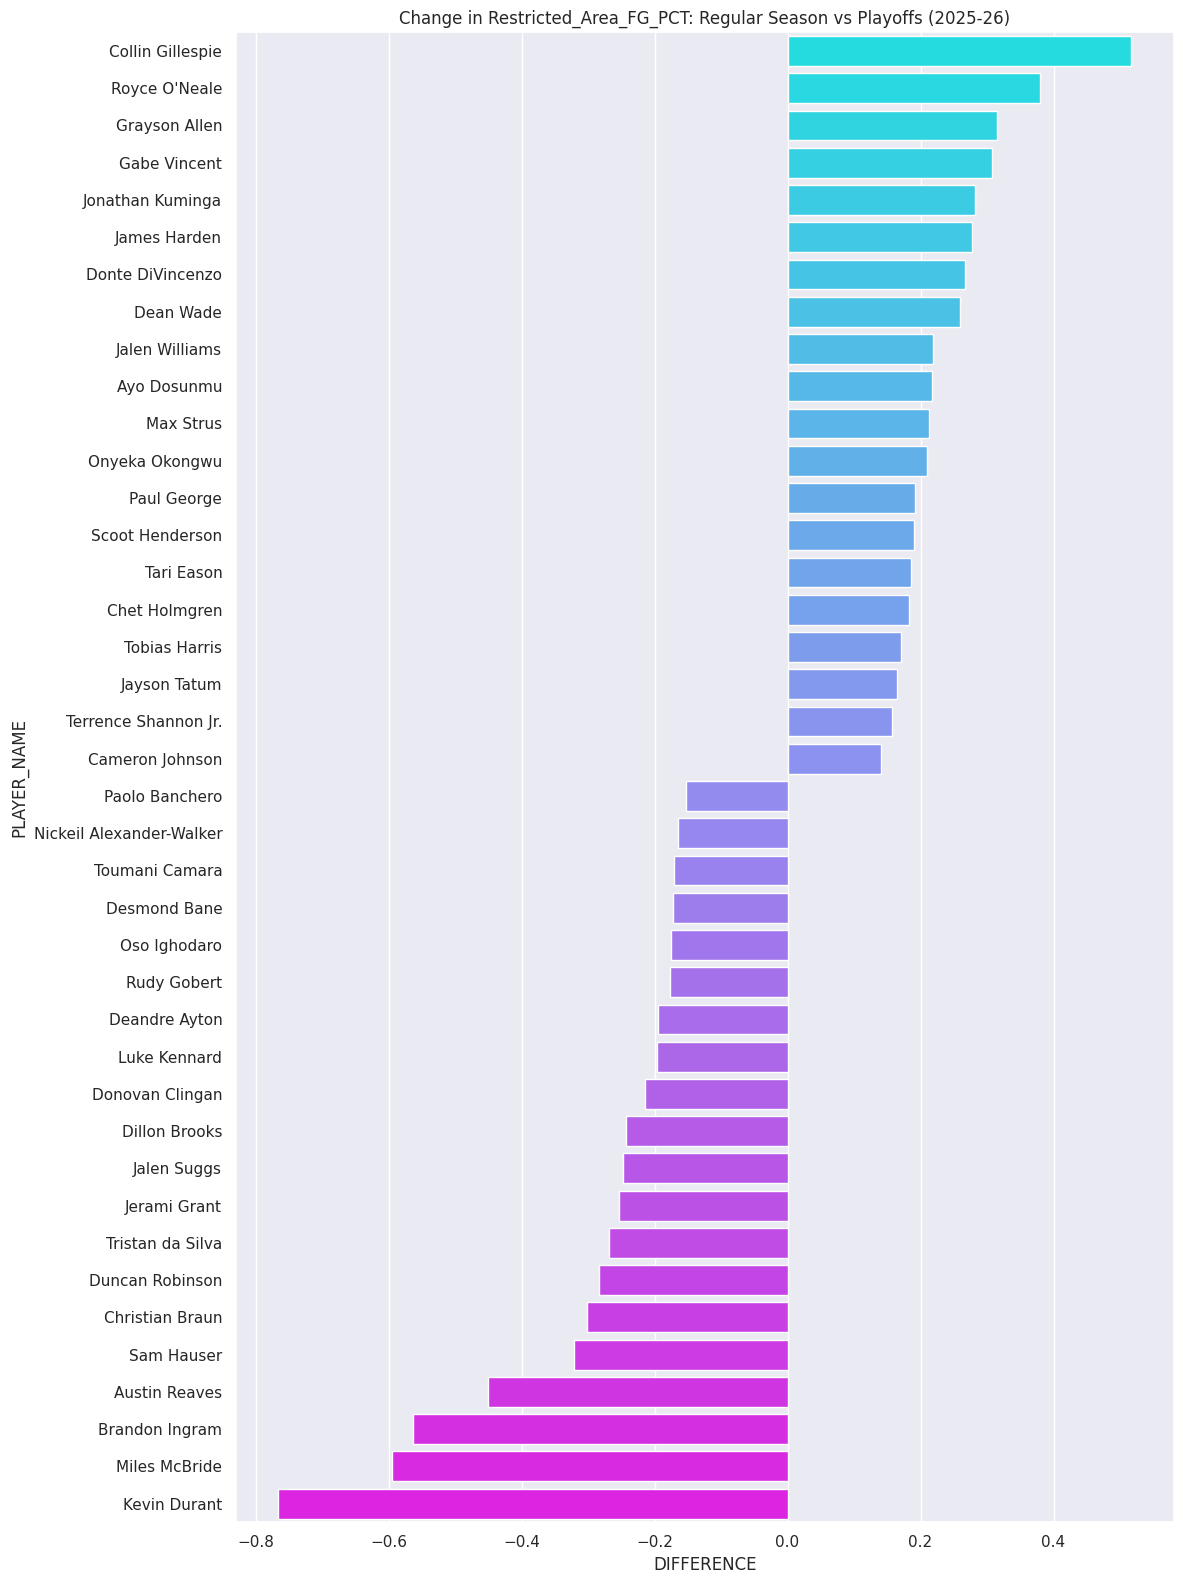

In [ ]:
df_results, fig = analyze_player_changes(
    df=df_master,
    stat_column="Restricted_Area_FG_PCT",
    query_conditions="MIN>=15",
    compare_col="SEASON_TYPE",
    base="Regular Season",
    comp="Playoffs",
    palette="cool",
    n=20
)

In [ ]:
df_master[df_master['PLAYER_POSITION'].str.contains('G', na=False)]

In [ ]:
df_master[df_master['PLAYER_POSITION'].str.contains('G', na=False)]\
.query("SEASON=='2025-26' & GP>=20 & MIN>=15")['Restricted_Area_FG_PCT'].describe()

In [ ]:
df_master[df_master['PLAYER_POSITION'].str.contains('F', na=False)]\
.query("SEASON=='2025-26' & GP>=20 & MIN>=15 & In_The_Paint_Non_RA_FGA>=0.75")\
.sort_values(by='In_The_Paint_Non_RA_FG_PCT', ascending=False)\
 [['GP',  'MIN', 'PTS', 'REB', 'AST', 'TS_PCT', 'In_The_Paint_Non_RA_FGM',\
   'In_The_Paint_Non_RA_FGA', 'In_The_Paint_Non_RA_FG_PCT']].iloc[60:120]

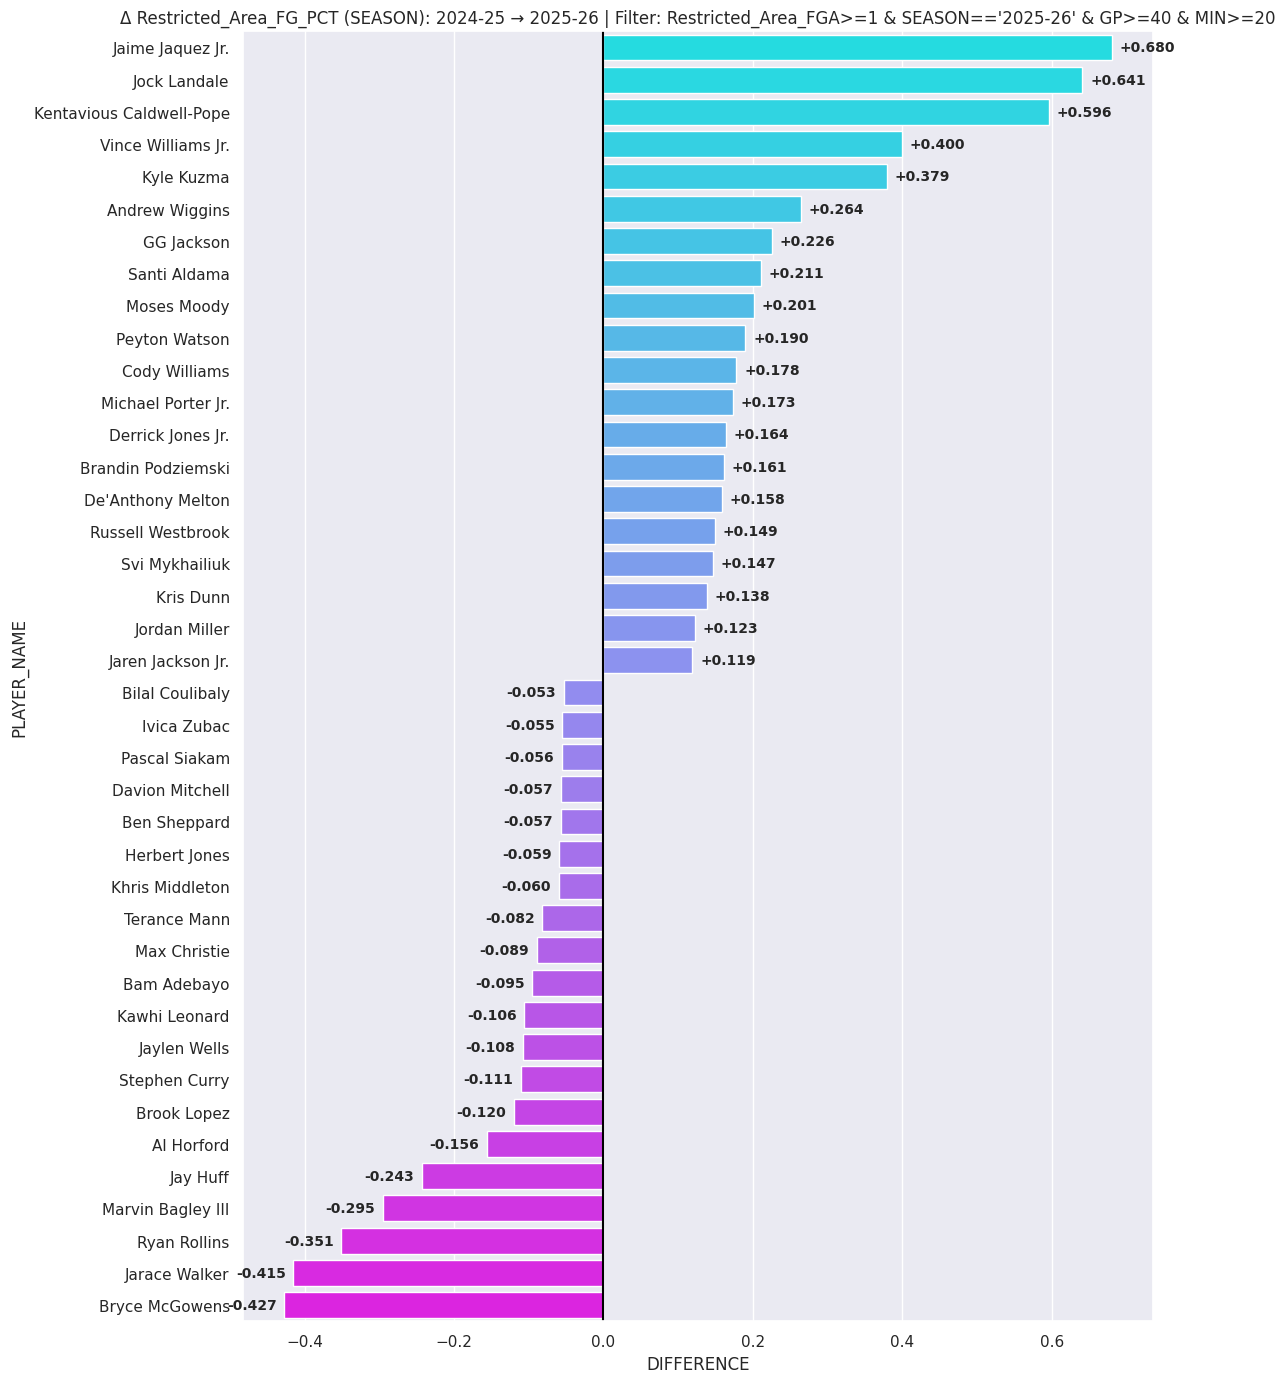

(SEASON               PLAYER_NAME  2024-25  2025-26  DIFFERENCE
 0               Jaime Jaquez Jr.    0.000    0.680       0.680
 1                   Jock Landale    0.000    0.641       0.641
 2       Kentavious Caldwell-Pope    0.000    0.596       0.596
 3             Vince Williams Jr.    0.000    0.400       0.400
 4                     Kyle Kuzma    0.308    0.687       0.379
 ..                           ...      ...      ...         ...
 88                      Jay Huff    1.000    0.757      -0.243
 89             Marvin Bagley III    1.000    0.705      -0.295
 90                  Ryan Rollins    1.000    0.649      -0.351
 91                 Jarace Walker    1.000    0.585      -0.415
 92                Bryce McGowens    1.000    0.573      -0.427
 
 [93 rows x 4 columns],
 <Figure size 1200x1400 with 1 Axes>)

In [ ]:
analyze_player_changes(df=df_master,
                              stat_column="Restricted_Area_FG_PCT",
                              query_conditions = "Restricted_Area_FGA>=1 & SEASON=='2025-26' & GP>=40 & MIN>=20",
                              compare_col="SEASON",
                              base="2024-25",
                              comp="2025-26",
                              palette = "cool",
                              n=20)

In [ ]:
analyze_player_changes(df=df_master,
                              stat_column="Restricted_Area_FG_PCT",
                              query_conditions = "SEASON=='2025-26' & MIN>=15 & GP>=2",
                              compare_col="SEASON_TYPE",
                              base="Regular Season",
                              comp="Playoffs",
                              palette = "cool",
                              n=20)

❌ Error: 'Regular Season' rows vanished after filtering for qualifiers.


(Empty DataFrame
 Columns: []
 Index: [],
 None)

In [ ]:
plot_interactive_barh(df_master[df_master['PLAYER_POSITION'].str.contains('G', na=False)],
                      y_col = "PLAYER_NAME",
                      x_col = "Restricted_Area_FG_PCT",
                      season = "2025-26",
                      query_condition = "GP>=20 & MIN>=15&Restricted_Area_FGA>=1")

In [ ]:
def analyze_shot_distribution(df):
    """
    Analyze shot distribution by player and zone, calculating percentages of total shots taken in each zone.

    Parameters:
    df: DataFrame with columns containing shooting data for all players

    Returns:
    DataFrame: Shot distribution analysis with percentages for each zone
    """
    # Get shooting zones
    FGA_zones = [col for col in player_shooting_reg_season_df.columns if 'FGA' in col]

    # Initialize results DataFrame with player names
    results = pd.DataFrame()
    results.index = df.index

    # Calculate total FGA for each player across all zones
    total_fga = 0
    for attempts in FGA_zones[:-1]:
        total_fga += df[attempts]

    results['TOTAL_FGA'] = total_fga

    # Calculate percentage of shots taken in each zone
    for zone in FGA_zones:
        zone_name = f"Pct_of_FGA_{zone.split('_FGA')[0]}"
        results[zone_name] = (df[zone] / results['TOTAL_FGA'] * 100).round(2)
        # # Also store raw FGA for reference
        results[f"{zone}"] = df[zone]

    # results.drop(['TOTAL_FGA'], axis=1, inplace=True)
    results.drop_duplicates(inplace=True)
    # results.reset_index(drop=True, inplace=True)

    # # Calculate percentage of total league shots
    # total_league_fga = results['TOTAL_FGA'].sum()
    # results['LEAGUE_FGA_PCT'] = (results['TOTAL_FGA'] / total_league_fga * 100).round(2)

    # # Sort by total FGA descending
    # results = results.sort_values('TOTAL_FGA', ascending=False)

    return results

# Calculate the distribution
shot_distribution = analyze_shot_distribution(player_shooting_reg_season_df)
shot_distribution = shot_distribution.join(player_individual_regular_season_df[['MIN', 'GP']], how = 'inner')
cols = ['GP', 'MIN', 'TOTAL_FGA', 'Pct_of_FGA_Restricted_Area', 'Restricted_Area_FGA',
       'Pct_of_FGA_In_The_Paint_Non_RA', 'In_The_Paint_Non_RA_FGA',
       'Pct_of_FGA_Mid_Range', 'Mid_Range_FGA', 'Pct_of_FGA_Left_Corner_3',
       'Left_Corner_3_FGA', 'Pct_of_FGA_Right_Corner_3', 'Right_Corner_3_FGA',
       'Pct_of_FGA_Above_the_Break_3', 'Above_the_Break_3_FGA',
       'Pct_of_FGA_Backcourt', 'Backcourt_FGA', 'Pct_of_FGA_Corner_3',
       'Corner_3_FGA']

shot_distribution = shot_distribution[cols]


In [ ]:
shot_distribution.query("SEASON=='2024-25' & MIN>=15 & GP>=12").sort_values(by = 'TOTAL_FGA', ascending = False).iloc[0:60]

In [ ]:
SEASONS = ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21',\
            '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']  # your full list, 2016-17 → 2025-26
for season in SEASONS:
    for st in ['Regular Season', 'Playoffs']:
        df_master = refresh_and_patch_custom_stat(
            df_master, fetch_nba_shot_locations,
            active_season=season, active_season_type=st,
            keep_cols=shoot_cols, force_refresh=True,
        )

Fetching Shot Locations for 2015-16 (Regular Season)...
🌐 Fetching fresh: shot_locations_2015-16_regular_season_pergame.parquet
💾 Saved cache: shot_locations_2015-16_regular_season_pergame.parquet
Fetching Shot Locations for 2015-16 (Playoffs)...
🌐 Fetching fresh: shot_locations_2015-16_playoffs_pergame.parquet
💾 Saved cache: shot_locations_2015-16_playoffs_pergame.parquet
Fetching Shot Locations for 2016-17 (Regular Season)...
🌐 Fetching fresh: shot_locations_2016-17_regular_season_pergame.parquet
💾 Saved cache: shot_locations_2016-17_regular_season_pergame.parquet
Fetching Shot Locations for 2016-17 (Playoffs)...
🌐 Fetching fresh: shot_locations_2016-17_playoffs_pergame.parquet
💾 Saved cache: shot_locations_2016-17_playoffs_pergame.parquet
Fetching Shot Locations for 2017-18 (Regular Season)...
🌐 Fetching fresh: shot_locations_2017-18_regular_season_pergame.parquet
💾 Saved cache: shot_locations_2017-18_regular_season_pergame.parquet
Fetching Shot Locations for 2017-18 (Playoffs)...
🌐

In [ ]:
slice_2425 = df_master.xs('2024-25', level='SEASON')
missing = slice_2425.columns[slice_2425.isna().all()]
print(len(missing))
sorted(set(c.split('_')[0] for c in missing))

67


['CLOSESTDEF', 'PUTBACK']

## Player Tracking

### Drives

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Drives',
    ['2024-25', '2025-26']
)

DEBUG: Routing Drives to source: pt
📂 Loading cache: nba_stats_pt_drives_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_pt_drives_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Drives to source: pt
📂 Loading cache: nba_stats_pt_drives_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_drives_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_drives_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 155)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


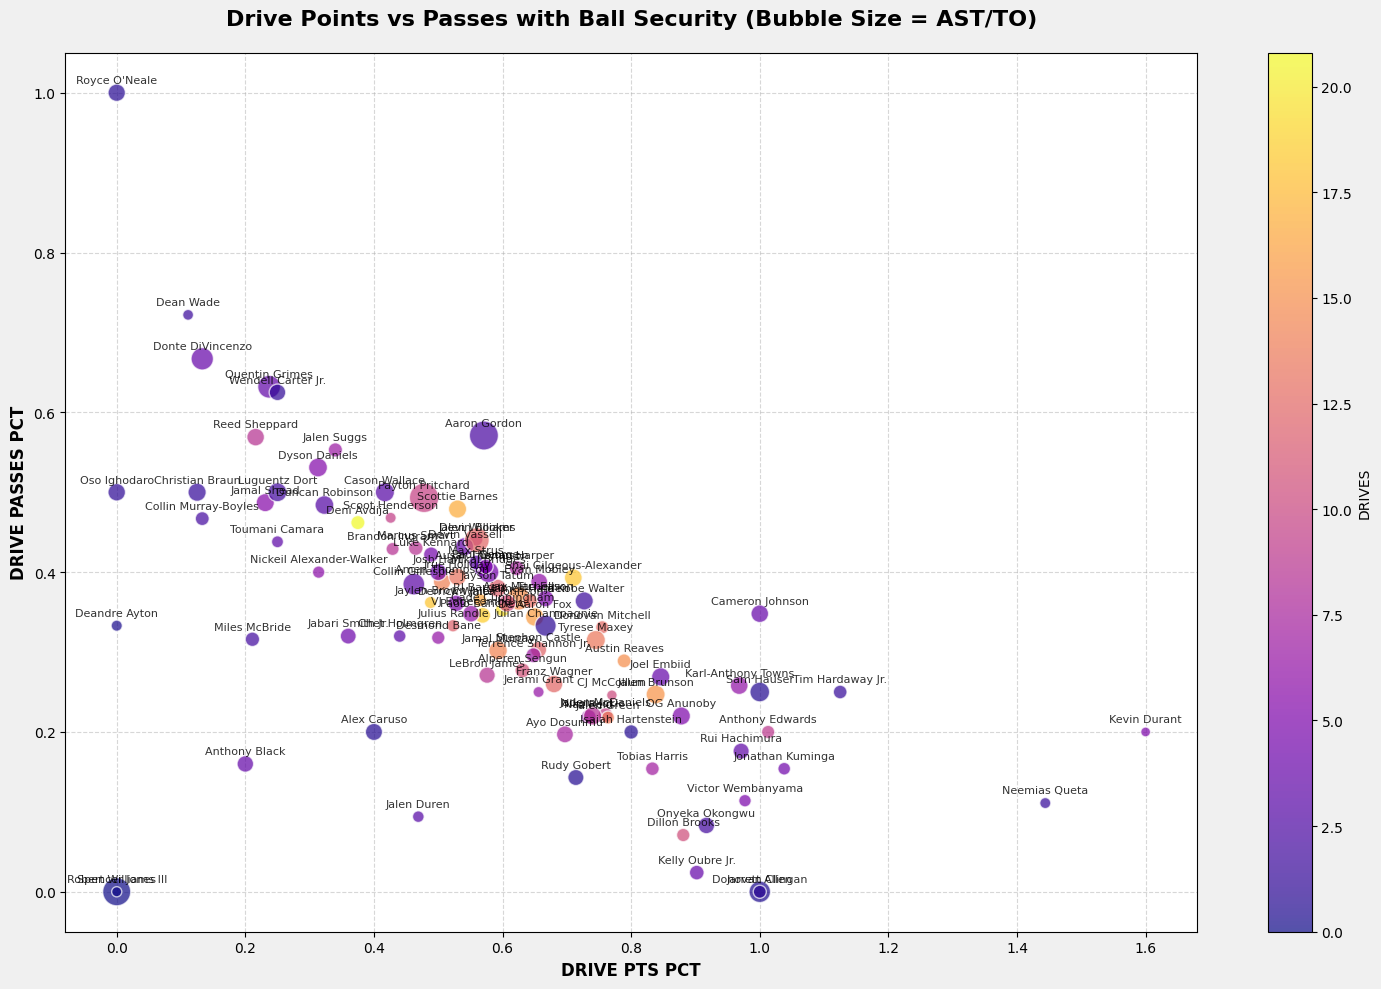

In [ ]:
# --- Run the updated Analysis ---
scatter_nba_stats(df_master, 'DRIVE_PTS_PCT', 'DRIVE_PASSES_PCT', '2025-26',
                  color_stat='DRIVES',
                  size_stat='AST_TO', # Bubble size = Assist-to-Turnover Ratio
                  min_min=20,
                  season_type="Playoffs",
                  title='Drive Points vs Passes with Ball Security (Bubble Size = AST/TO)')

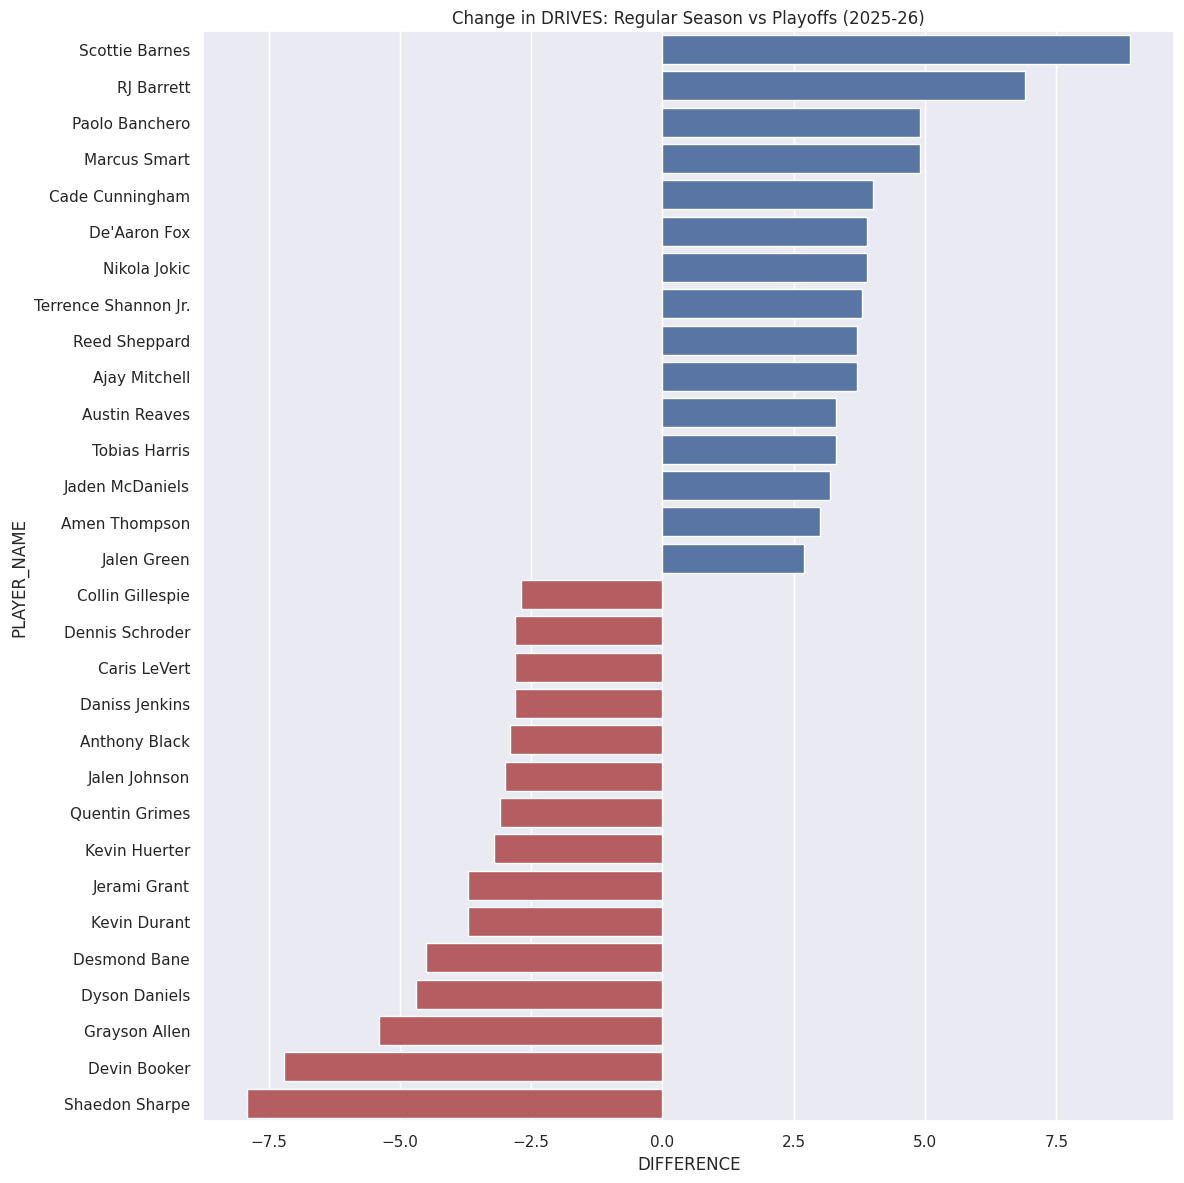

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='DRIVES',
        query_conditions=["MIN >= 10"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26',
        n=15
    )

In [ ]:
plot = plot_interactive_barh(drives_reg_season_df, 'PLAYER_NAME', 'DRIVE_PTS_PCT',
                         season='2024-25', sort_by='DRIVE_PTS_PCT', ascending=True,\
                              query_condition= "GP>=15 & MIN >=15 & DRIVES>=1 & DRIVE_FGA >=1",title = "Drive Pts Pct", color = 'cool')
plot

### Possessions

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Possessions',
    ['2024-25', '2025-26']
)

DEBUG: Routing Possessions to source: pt
📂 Loading cache: nba_stats_pt_possessions_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_pt_possessions_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Possessions to source: pt
📂 Loading cache: nba_stats_pt_possessions_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_possessions_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_possessions_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 168)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master

GP  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   5   
                       Aaron Gordon    203932    DEN               1610612743  14   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  23   
                       Aaron Wiggins   1630598   OKC               1610612760  22   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  39   
                       Zeke Nnaji      1630192   DEN               1610612743  52   
                       Ziaire Williams 1630533   BKN               1610612751  56   
                       Zion Williamson 1629627   NOP               1610612740  62   
                       Zyon Pullin     1642389   MIN               1610612750   5   

                                                                                W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   1   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  15   
                       Aaron Wiggins   1630598   OKC               1610612760  15   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   4   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   0   
                       Aaron Nesmith   1630174   IND               1610612754   8   
                       Aaron Wiggins   1630598   OKC               1610612760   7   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  30   
                       Zeke Nnaji      1630192   DEN               1610612743  14   
                       Ziaire Williams 1630533   BKN               1610612751  43   
                       Zion Williamson 1629627   NOP               1610612740  40   
                       Zyon Pullin     1642389   MIN               1610612750   1   

                                                                               W_PCT  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749  0.200   
                       Aaron Gordon    203932    DEN               1610612743  0.500   
                       Aaron Holiday   1628988   HOU               1610612745  1.000   
                       Aaron Nesmith   1630174   IND               1610612754  0.652   
                       Aaron Wiggins   1630598   OKC               1610612760  0.682   
...                                                                              ...   
2025-26 Regular Season Zach LaVine     203897    SAC     

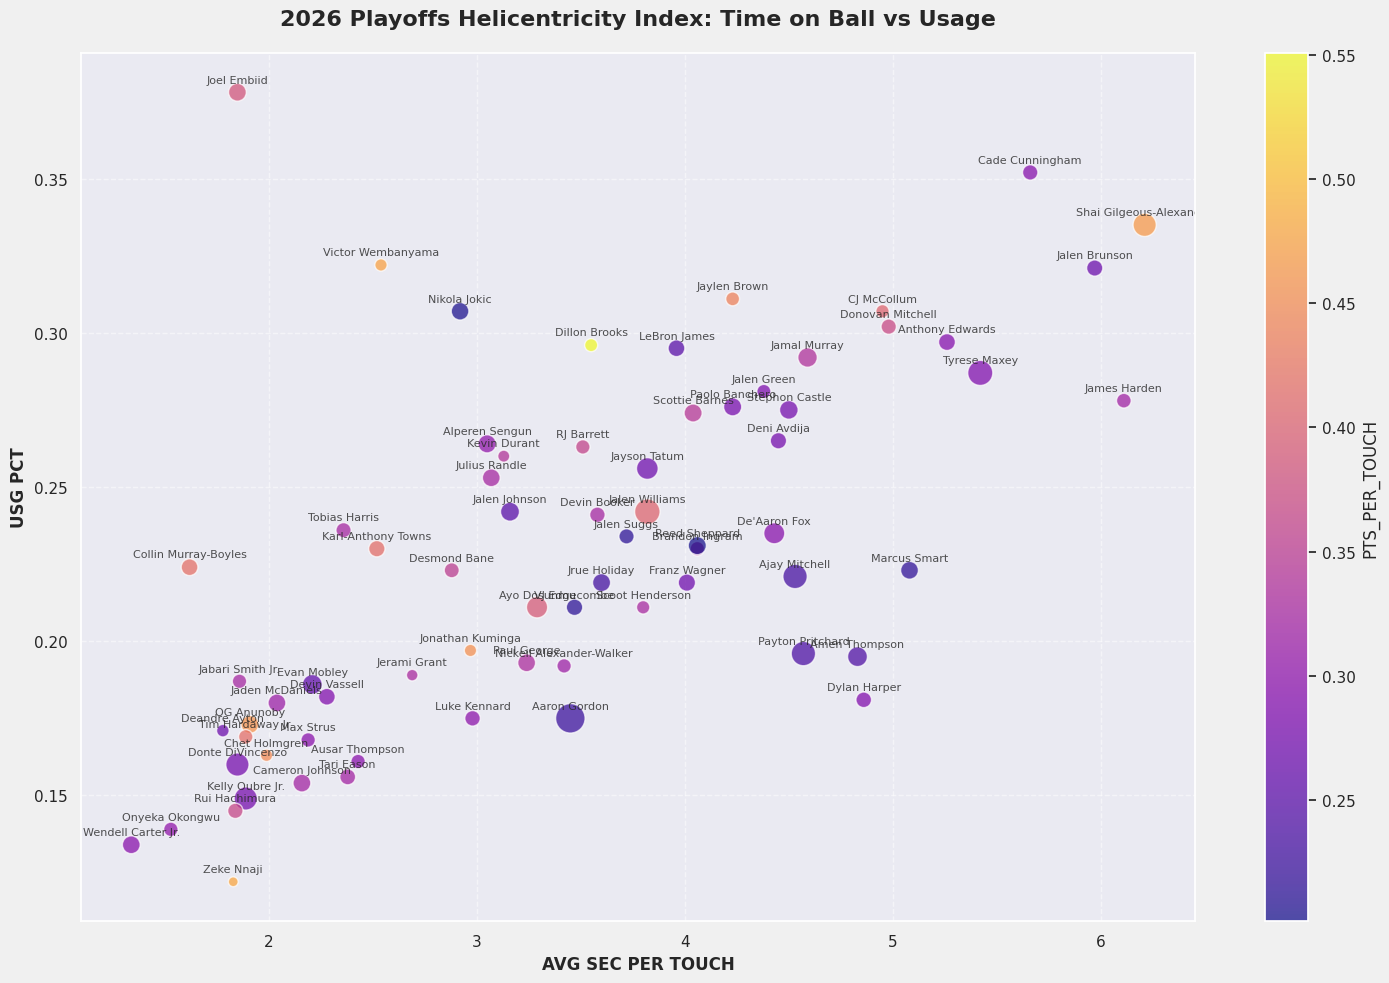

In [ ]:
# --- The 2026 Helicentricity Index ---
scatter_nba_stats(
    df_master,
    x_stat='AVG_SEC_PER_TOUCH',
    y_stat='USG_PCT',
    season='2025-26',
    color_stat='PTS_PER_TOUCH',
    size_stat='AST_TO', # Bubble size shows ball security
    min_min=15,
    min_pts=10,
    season_type="Playoffs",
    title='2026 Playoffs Helicentricity Index: Time on Ball vs Usage'
)

In [ ]:
# --- The Gravity & Spacing Map ---
scatter_nba_stats(
    df_master,
    x_stat='DRIVES',
    y_stat='Above_the_Break_3_FG_PCT',
    season='2025-26',
    color_stat='PTS',
    size_stat='DRIVE_PTS_PCT',
    min_pts=12,
    min_gp=30,
    title='2026 Gravity Map: Driving Volume vs Perimeter Spacing'
)

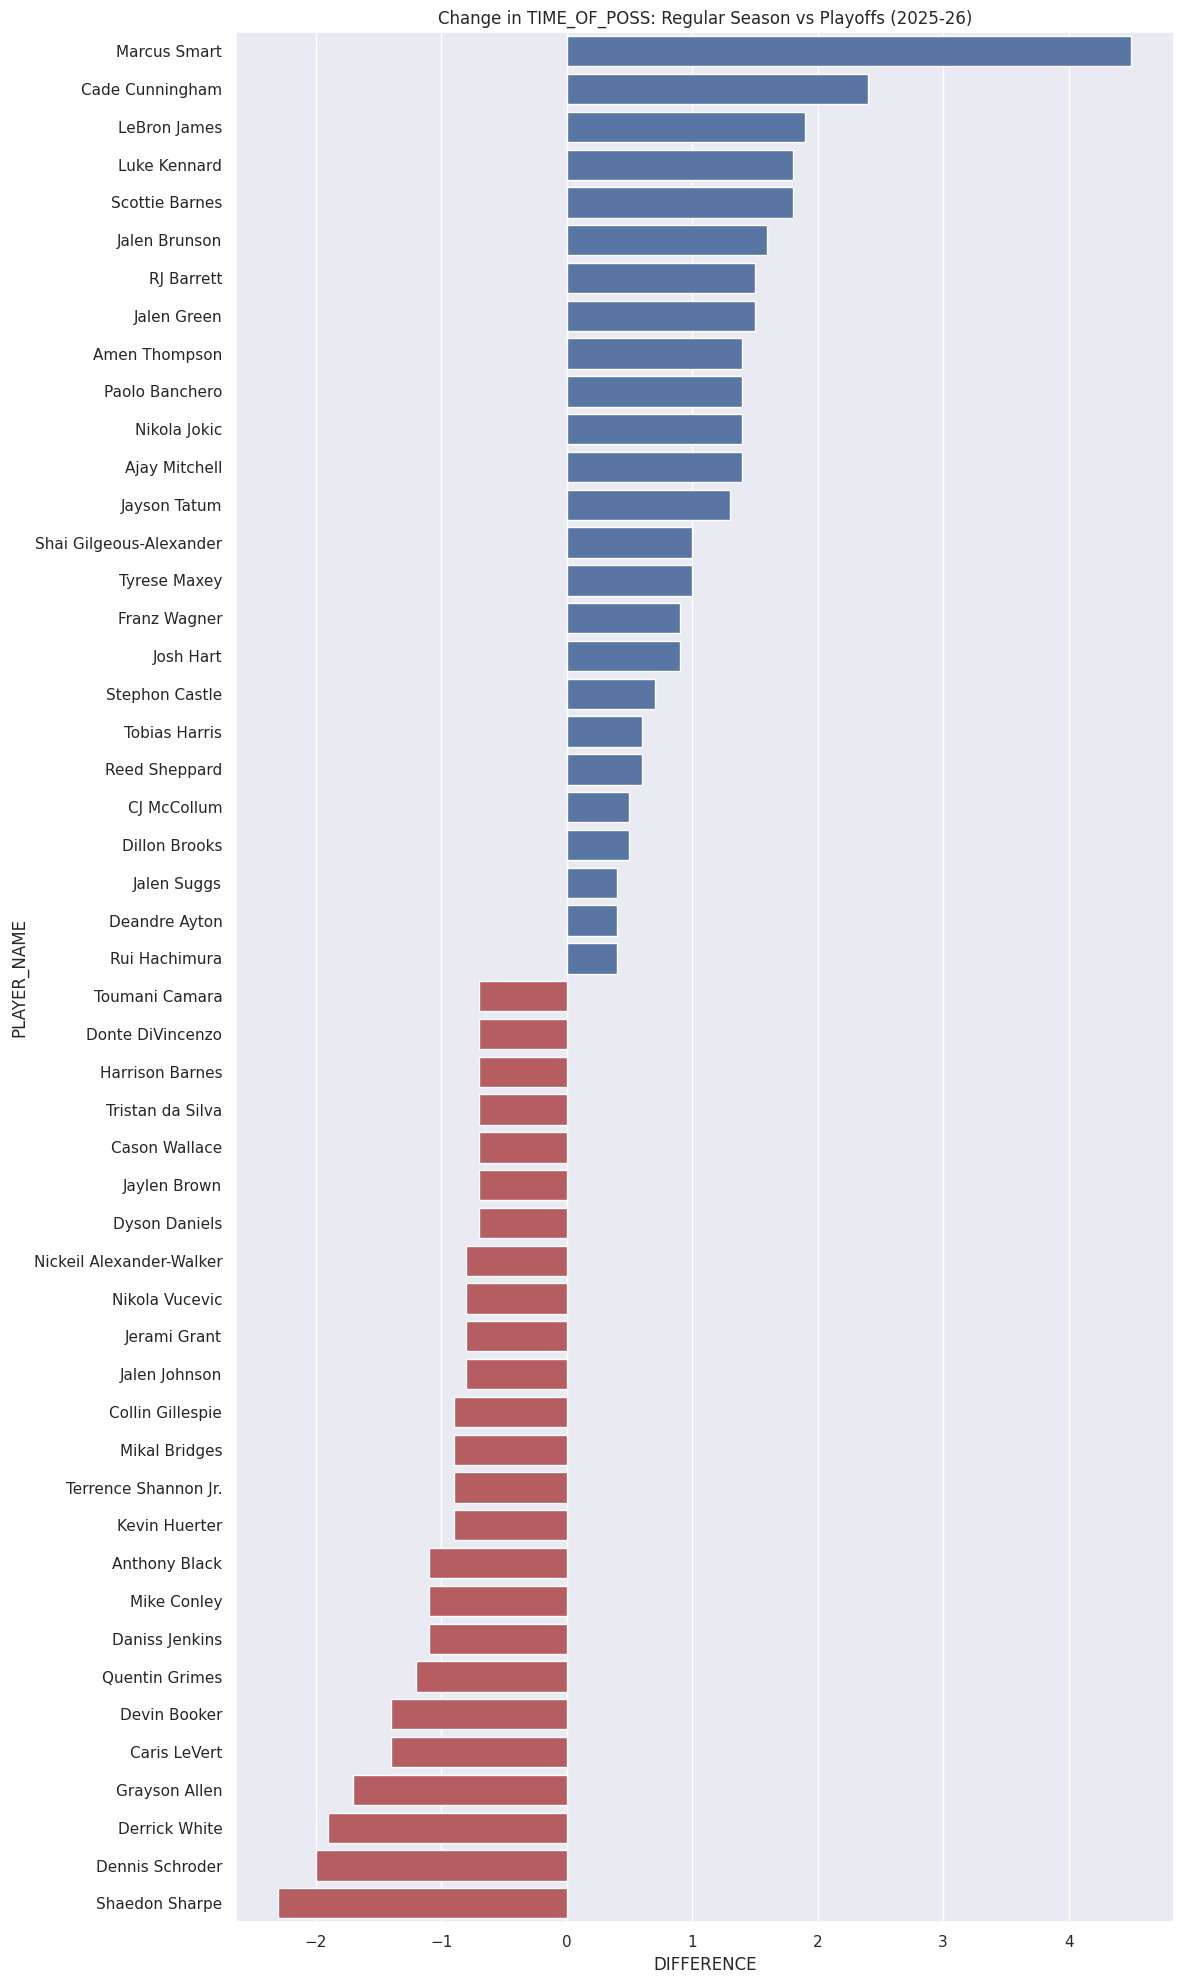

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='TIME_OF_POSS',
        query_conditions=["MIN >= 10"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

In [ ]:
plot = plot_interactive_barh(
    df=possessions_df.reset_index(), # reset_index if your data is MultiIndexed
    x_col='AVG_SEC_PER_TOUCH',
    y_col='PLAYER_NAME',
    season='2025-26',
    title="Interactive Avg Second Per Touch Leaderboard",
    query_condition="GP >= 20 & MIN >= 20 & TOUCHES>=30"
)

plot

### Pull-Up Shooting

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'PullUpShot',
    ['2024-25', '2025-26']
)

DEBUG: Routing PullUpShot to source: pt
📂 Loading cache: nba_stats_pt_pullupshot_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_pt_pullupshot_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing PullUpShot to source: pt
📂 Loading cache: nba_stats_pt_pullupshot_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_pullupshot_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_pullupshot_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 240)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.query("SEASON=='2025-26'&MIN >=15 & SEASON_TYPE=='Playoffs'")['PULL_UP_FG3A'].describe()

,PULL_UP_FG3A
count,115.000000
mean,1.455652
std,1.776315
min,0.000000
25%,0.000000
50%,0.800000
75%,2.000000
max,8.000000


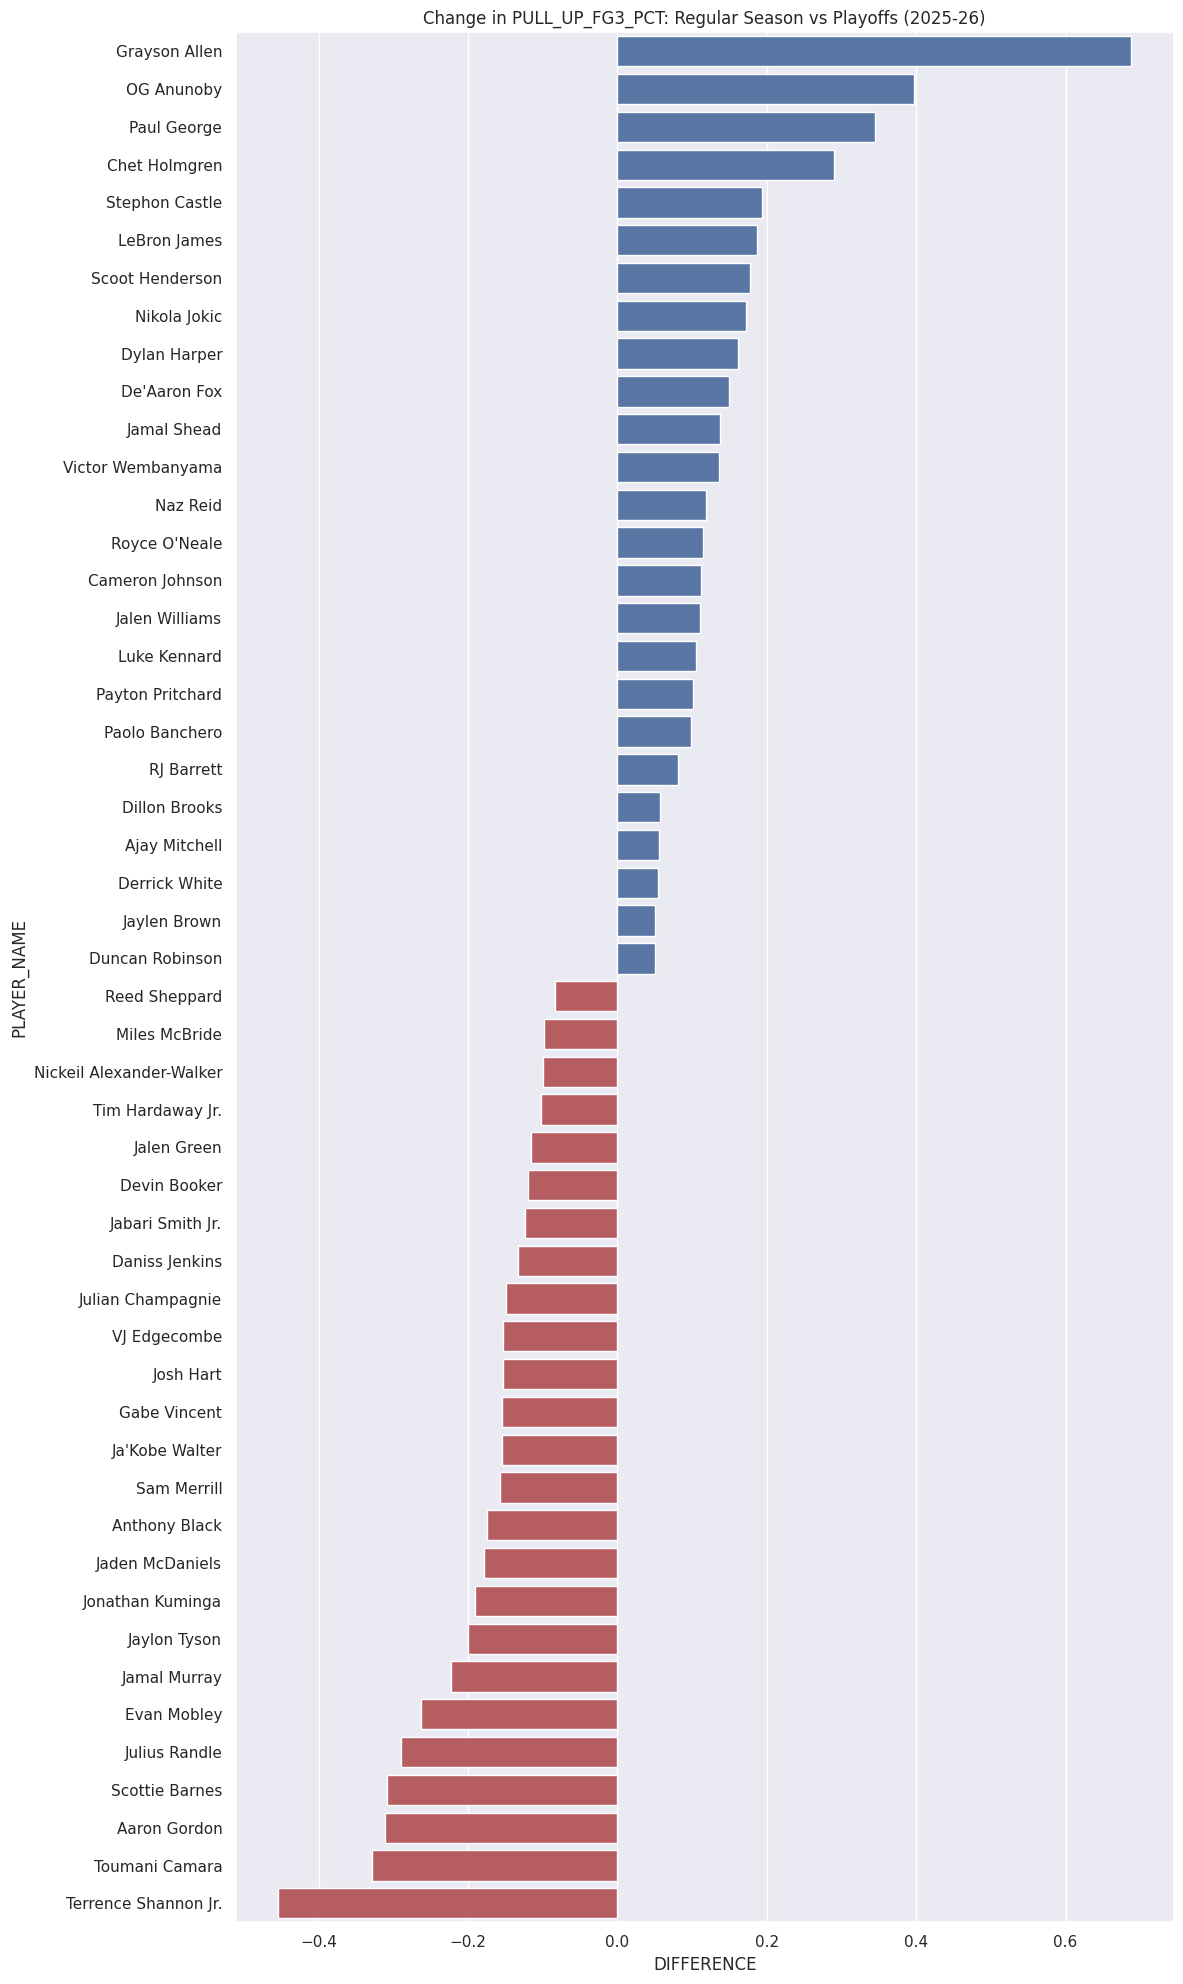

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='PULL_UP_FG3_PCT',
        query_conditions=["MIN >= 15 & PULL_UP_FG3A>=0.5"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

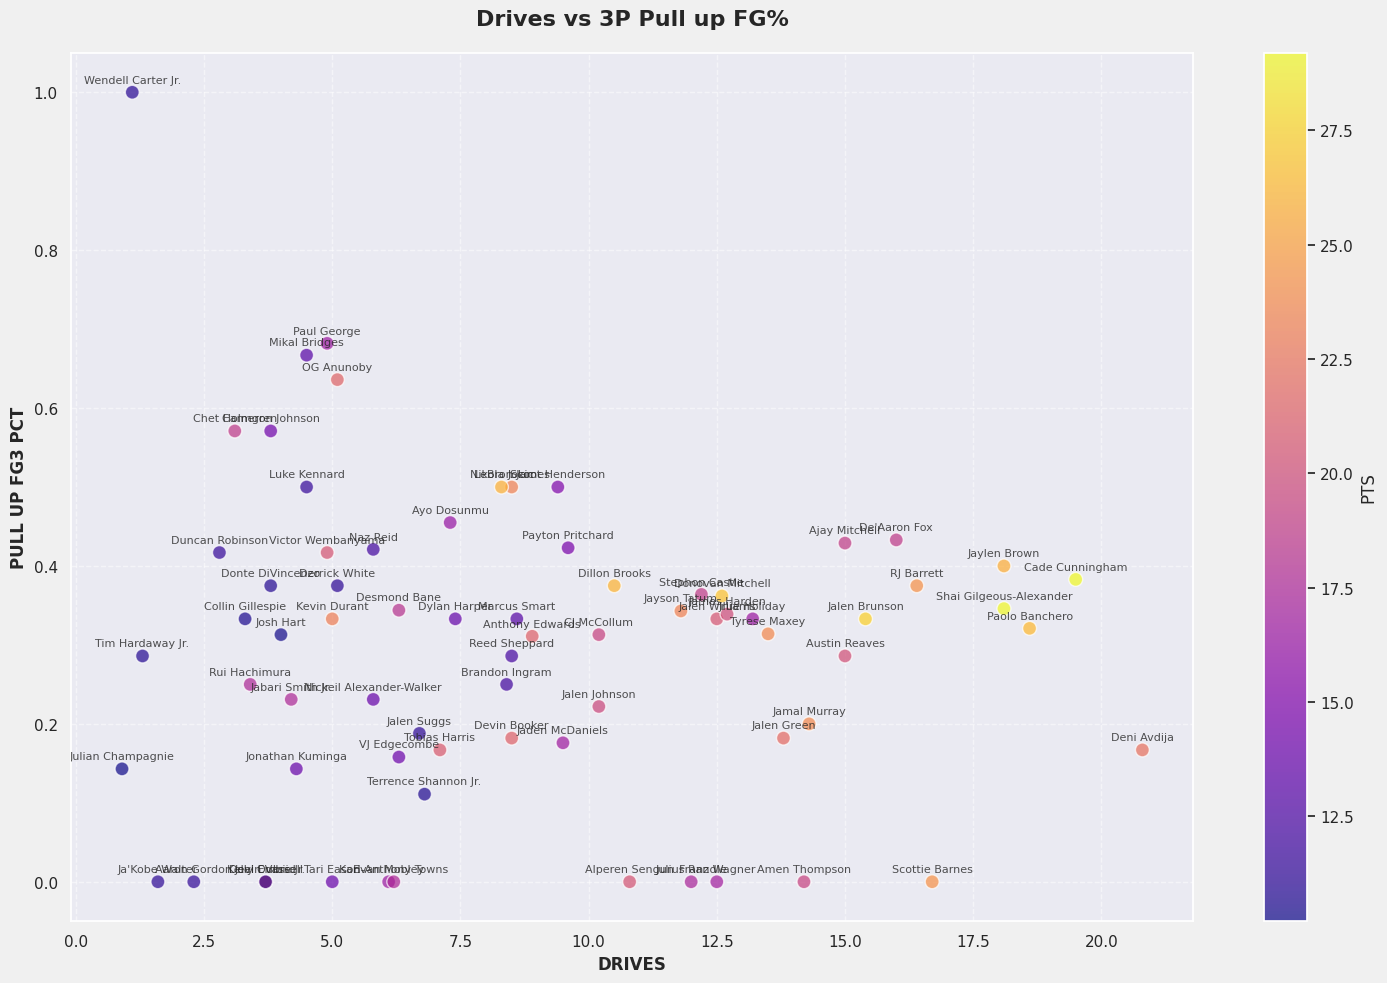

In [ ]:
scatter_nba_stats(df_master, 'DRIVES', 'PULL_UP_FG3_PCT', '2025-26',
                  color_stat='PTS', min_pts=10, season_type="Playoffs",
                  title='Drives vs 3P Pull up FG%')

In [ ]:
pull_up_df.query('MIN >=20 & GP >=50 & PULL_UP_FG3A>=0.5')['PULL_UP_FG3_PCT'].describe()

In [ ]:
plot = plot_interactive_barh(
    df=pull_up_df.reset_index(), # reset_index if your data is MultiIndexed
    x_col='PULL_UP_FG3_PCT',
    y_col='PLAYER_NAME',
    season='2025-26',
    title="Interactive Pull Up 3P% Leaderboard",
    query_condition="GP >= 50 & MIN >= 20 & PULL_UP_FG3A>=1"
)

plot

### Catch & Shoot

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'CatchShoot',
    ['2024-25', '2025-26']
)

DEBUG: Routing CatchShoot to source: pt
🌐 Fetching fresh: nba_stats_pt_catchshoot_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_catchshoot_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_catchshoot_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_catchshoot_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing CatchShoot to source: pt
🌐 Fetching fresh: nba_stats_pt_catchshoot_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_catchshoot_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_catchshoot_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_catchshoot_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 520)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master

index  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749    0.0   
                       Aaron Gordon    203932    DEN               1610612743    1.0   
                       Aaron Holiday   1628988   HOU               1610612745    2.0   
                       Aaron Nesmith   1630174   IND               1610612754    3.0   
                       Aaron Wiggins   1630598   OKC               1610612760    4.0   
...                                                                              ...   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  577.0   
                       Zeke Nnaji      1630192   DEN               1610612743  578.0   
                       Ziaire Williams 1630533   BKN               1610612751  579.0   
                       Zion Williamson 1629627   NOP               1610612740  580.0   
                       Zyon Pullin     1642389   MIN               1610612750  581.0   

                                                                               GP  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   5   
                       Aaron Gordon    203932    DEN               1610612743  14   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  23   
                       Aaron Wiggins   1630598   OKC               1610612760  22   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  39   
                       Zeke Nnaji      1630192   DEN               1610612743  52   
                       Ziaire Williams 1630533   BKN               1610612751  56   
                       Zion Williamson 1629627   NOP               1610612740  62   
                       Zyon Pullin     1642389   MIN               1610612750   5   

                                                                                W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   1   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  15   
                       Aaron Wiggins   1630598   OKC               1610612760  15   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   4   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   0   
                       Aaron Nesmith   1630174   IND               1610612754   8   
                       Aaron Wiggins   1630598   OKC               1610612760   7   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203

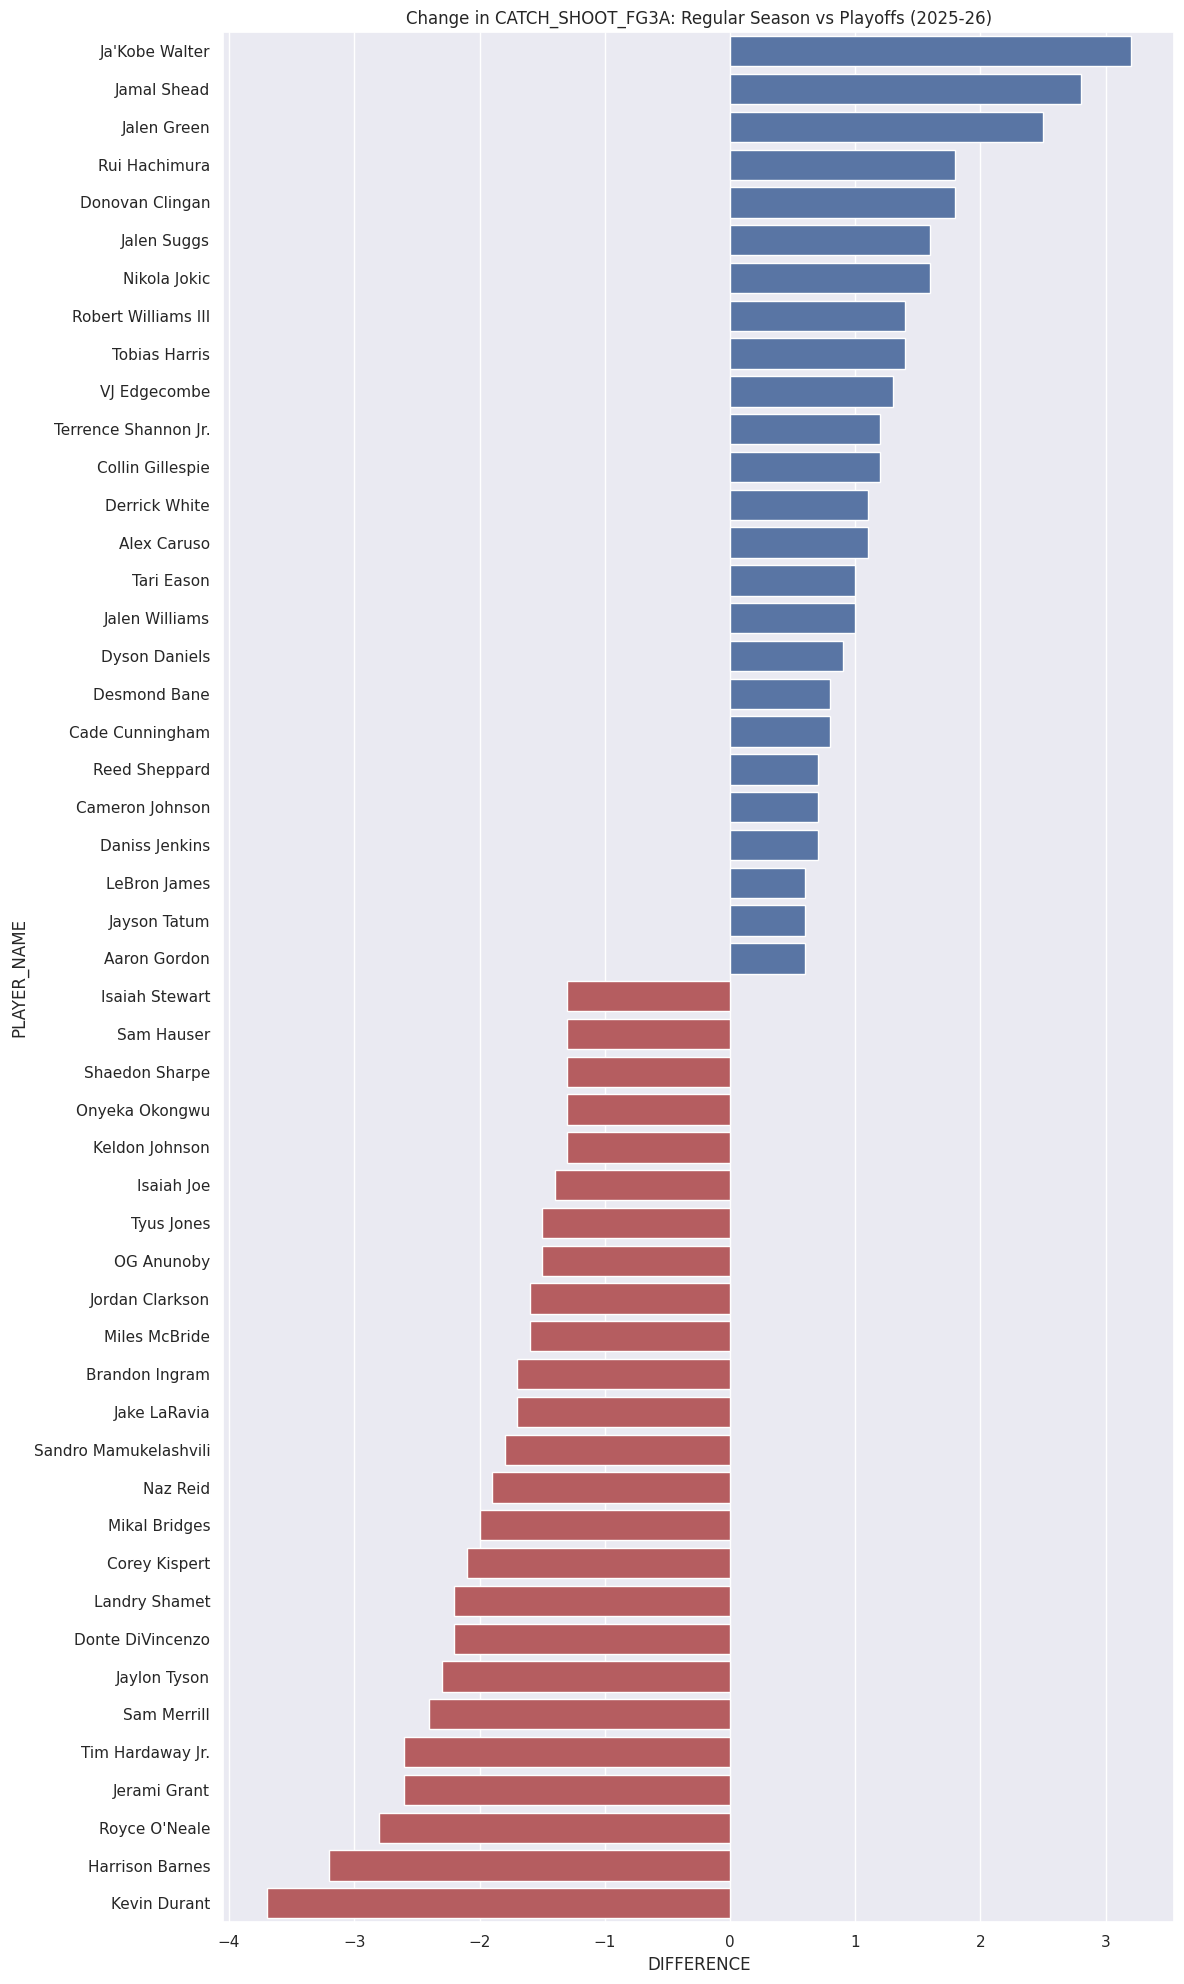

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='CATCH_SHOOT_FG3A',
        query_conditions=["MIN >= 10"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

In [ ]:
df_master.query('CATCH_SHOOT_FG3A>=2 & GP>=55 & MIN >=20')['CATCH_SHOOT_FG3_PCT'].describe()

In [ ]:
plot = plot_interactive_barh(
    df=catch_shoot_df.reset_index(), # reset_index if your data is MultiIndexed
    x_col='CATCH_SHOOT_FG3_PCT',
    y_col='PLAYER_NAME',
    season='2025-26',
    title="Interactive Catch & Shoot 3P% Leaderboard",
    query_condition="GP >= 20 & MIN >= 20 & CATCH_SHOOT_FG3A>=0.5"
)

plot

In [ ]:
scatter_nba_stats(df_master, 'CATCH_SHOOT_FG3_PCT', 'PULL_UP_FG3_PCT', '2025-26',
                  color_stat='PTS', min_pts=10, min_gp=60, custom_query = "PULL_UP_FG3A>=1",
                  title='Catch & Shoot 3P FG% vs Pull up 3P FG%')
plt.show()

### Passing

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Passing',
    ['2024-25', '2025-26']
)

DEBUG: Routing Passing to source: pt
🌐 Fetching fresh: nba_stats_pt_passing_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_passing_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_passing_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_passing_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Passing to source: pt
🌐 Fetching fresh: nba_stats_pt_passing_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_passing_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_passing_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_passing_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 529)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master

index  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749    0.0   
                       Aaron Gordon    203932    DEN               1610612743    1.0   
                       Aaron Holiday   1628988   HOU               1610612745    2.0   
                       Aaron Nesmith   1630174   IND               1610612754    3.0   
                       Aaron Wiggins   1630598   OKC               1610612760    4.0   
...                                                                              ...   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  577.0   
                       Zeke Nnaji      1630192   DEN               1610612743  578.0   
                       Ziaire Williams 1630533   BKN               1610612751  579.0   
                       Zion Williamson 1629627   NOP               1610612740  580.0   
                       Zyon Pullin     1642389   MIN               1610612750  581.0   

                                                                               GP  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   5   
                       Aaron Gordon    203932    DEN               1610612743  14   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  23   
                       Aaron Wiggins   1630598   OKC               1610612760  22   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  39   
                       Zeke Nnaji      1630192   DEN               1610612743  52   
                       Ziaire Williams 1630533   BKN               1610612751  56   
                       Zion Williamson 1629627   NOP               1610612740  62   
                       Zyon Pullin     1642389   MIN               1610612750   5   

                                                                                W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   1   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  15   
                       Aaron Wiggins   1630598   OKC               1610612760  15   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   4   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   0   
                       Aaron Nesmith   1630174   IND               1610612754   8   
                       Aaron Wiggins   1630598   OKC               1610612760   7   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203

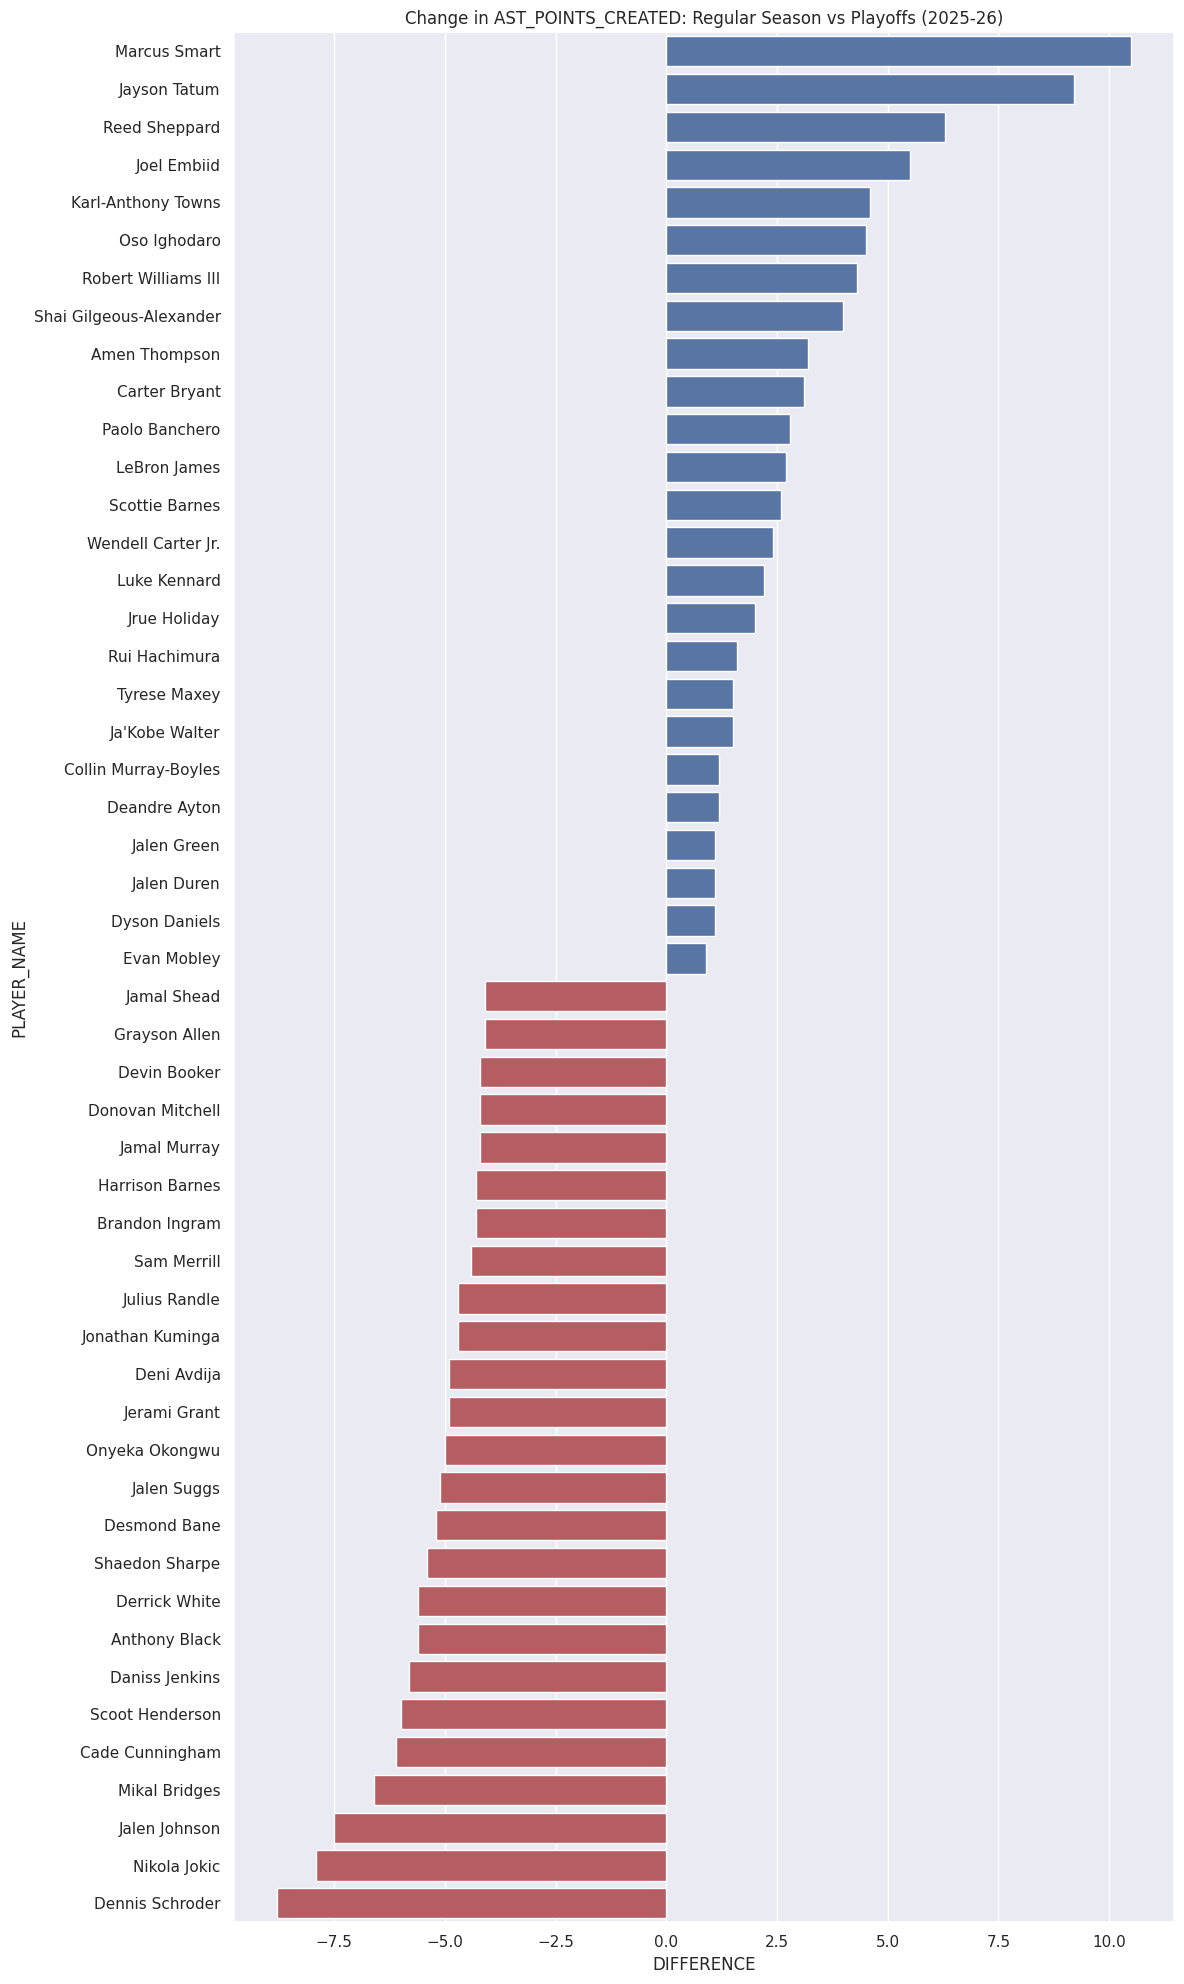

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='AST_POINTS_CREATED',
        query_conditions=["MIN >= 10"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

In [ ]:
analyze_player_season_changes(df_master, 'POTENTIAL_AST', query_conditions="GP>=60 & MIN>=20 & SEASON =='2025-26'", n=20)

In [ ]:
df_master

### Defensive Impact

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Defense',
    ['2024-25', '2025-26']
)

DEBUG: Routing Defense to source: pt
🌐 Fetching fresh: nba_stats_pt_defense_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_defense_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_defense_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_defense_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing Defense to source: pt
🌐 Fetching fresh: nba_stats_pt_defense_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_defense_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_defense_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_defense_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 577)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master

GP  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   5   
                       Aaron Gordon    203932    DEN               1610612743  14   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  23   
                       Aaron Wiggins   1630598   OKC               1610612760  22   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  39   
                       Zeke Nnaji      1630192   DEN               1610612743  52   
                       Ziaire Williams 1630533   BKN               1610612751  56   
                       Zion Williamson 1629627   NOP               1610612740  62   
                       Zyon Pullin     1642389   MIN               1610612750   5   

                                                                                W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   1   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  15   
                       Aaron Wiggins   1630598   OKC               1610612760  15   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   4   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   0   
                       Aaron Nesmith   1630174   IND               1610612754   8   
                       Aaron Wiggins   1630598   OKC               1610612760   7   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  30   
                       Zeke Nnaji      1630192   DEN               1610612743  14   
                       Ziaire Williams 1630533   BKN               1610612751  43   
                       Zion Williamson 1629627   NOP               1610612740  40   
                       Zyon Pullin     1642389   MIN               1610612750   1   

                                                                               W_PCT  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749  0.200   
                       Aaron Gordon    203932    DEN               1610612743  0.500   
                       Aaron Holiday   1628988   HOU               1610612745  1.000   
                       Aaron Nesmith   1630174   IND               1610612754  0.652   
                       Aaron Wiggins   1630598   OKC               1610612760  0.682   
...                                                                              ...   
2025-26 Regular Season Zach LaVine     203897    SAC     

In [ ]:
df_master.query("SEASON=='2025-26' & MIN>=15")['DEF_RIM_FGA'].describe()

,DEF_RIM_FGA
count,515.000000
mean,2.810291
std,1.458902
min,0.300000
25%,1.800000
50%,2.400000
75%,3.500000
max,8.900000


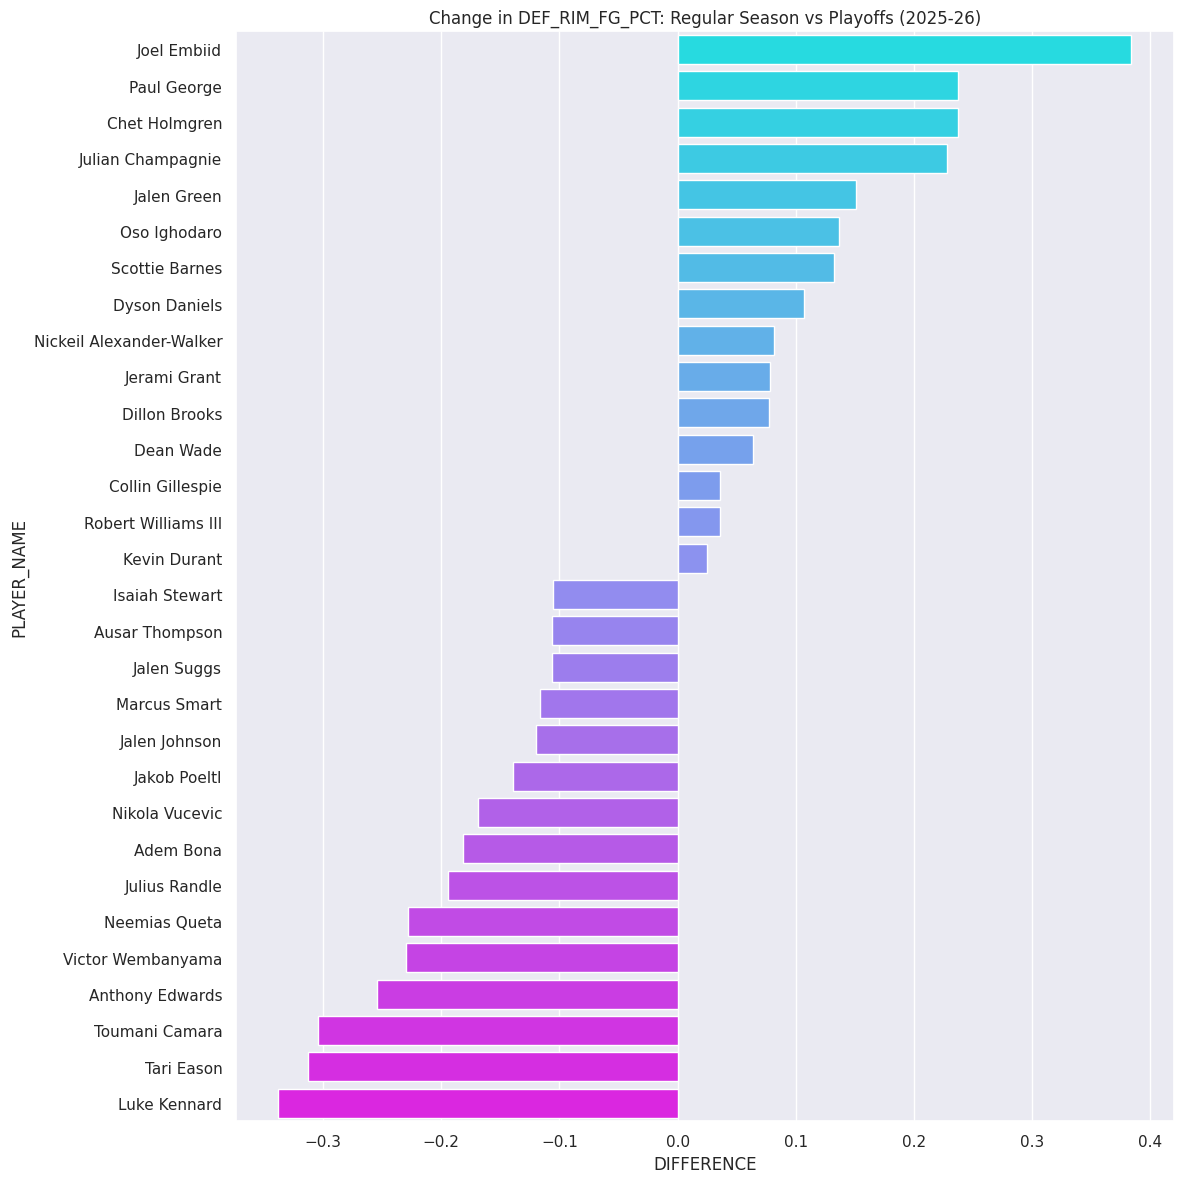

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='DEF_RIM_FG_PCT',
        query_conditions=["MIN >= 15 & DEF_RIM_FGA>=3"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26',
        palette = 'cool',
        n=15
    )

In [ ]:
plot_interactive_barh(
    df_master,
    x_col='DEF_RIM_FG_PCT', # This is the numeric stat
    y_col='PLAYER_NAME',      # This is the categorical label
    season='2025-26',
    query_condition="GP >= 50 & MIN >= 20 & DEF_RIM_FGA >=3"
)

In [ ]:
scatter_nba_stats(df_master,
                  'DEF_RIM_FG_PCT',
                  'PCT_PLUSMINUS',
                  season = '2025-26',
                  min_min =20,
                  min_gp = 65)

###Paint Touches

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'PaintTouch',
    ['2024-25', '2025-26']
)

DEBUG: Routing PaintTouch to source: pt
🌐 Fetching fresh: nba_stats_pt_painttouch_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_painttouch_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_painttouch_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_painttouch_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing PaintTouch to source: pt
🌐 Fetching fresh: nba_stats_pt_painttouch_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_painttouch_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_painttouch_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_painttouch_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 608)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


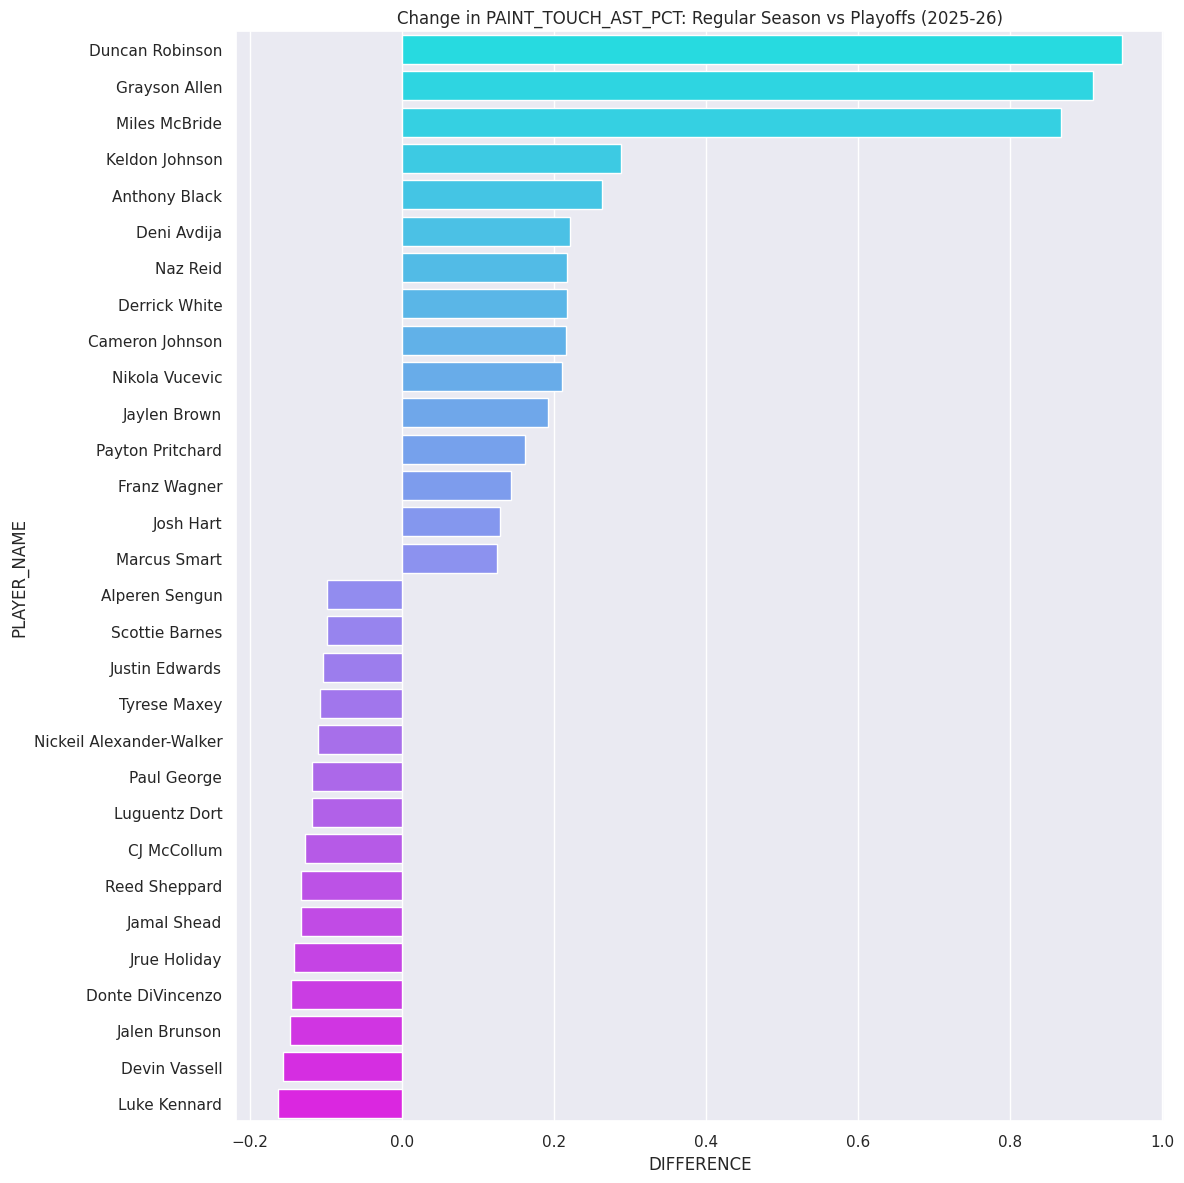

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='PAINT_TOUCH_AST_PCT',
        query_conditions=["MIN >= 15"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26',
        palette = 'cool',
        n=15
    )

In [ ]:
scatter_nba_stats(df_master[df_master['PLAYER_POSITION'].str.contains('G', na=False)],
                  'DRIVES', 'PAINT_TOUCHES', '2025-26', min_min = 20, min_gp = 55)

###Elbow Touches

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'ElbowTouch',
    ['2024-25', '2025-26']
)

DEBUG: Routing ElbowTouch to source: pt
🌐 Fetching fresh: nba_stats_pt_elbowtouch_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_elbowtouch_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_elbowtouch_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_elbowtouch_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing ElbowTouch to source: pt
🌐 Fetching fresh: nba_stats_pt_elbowtouch_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_elbowtouch_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_elbowtouch_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_elbowtouch_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 624)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


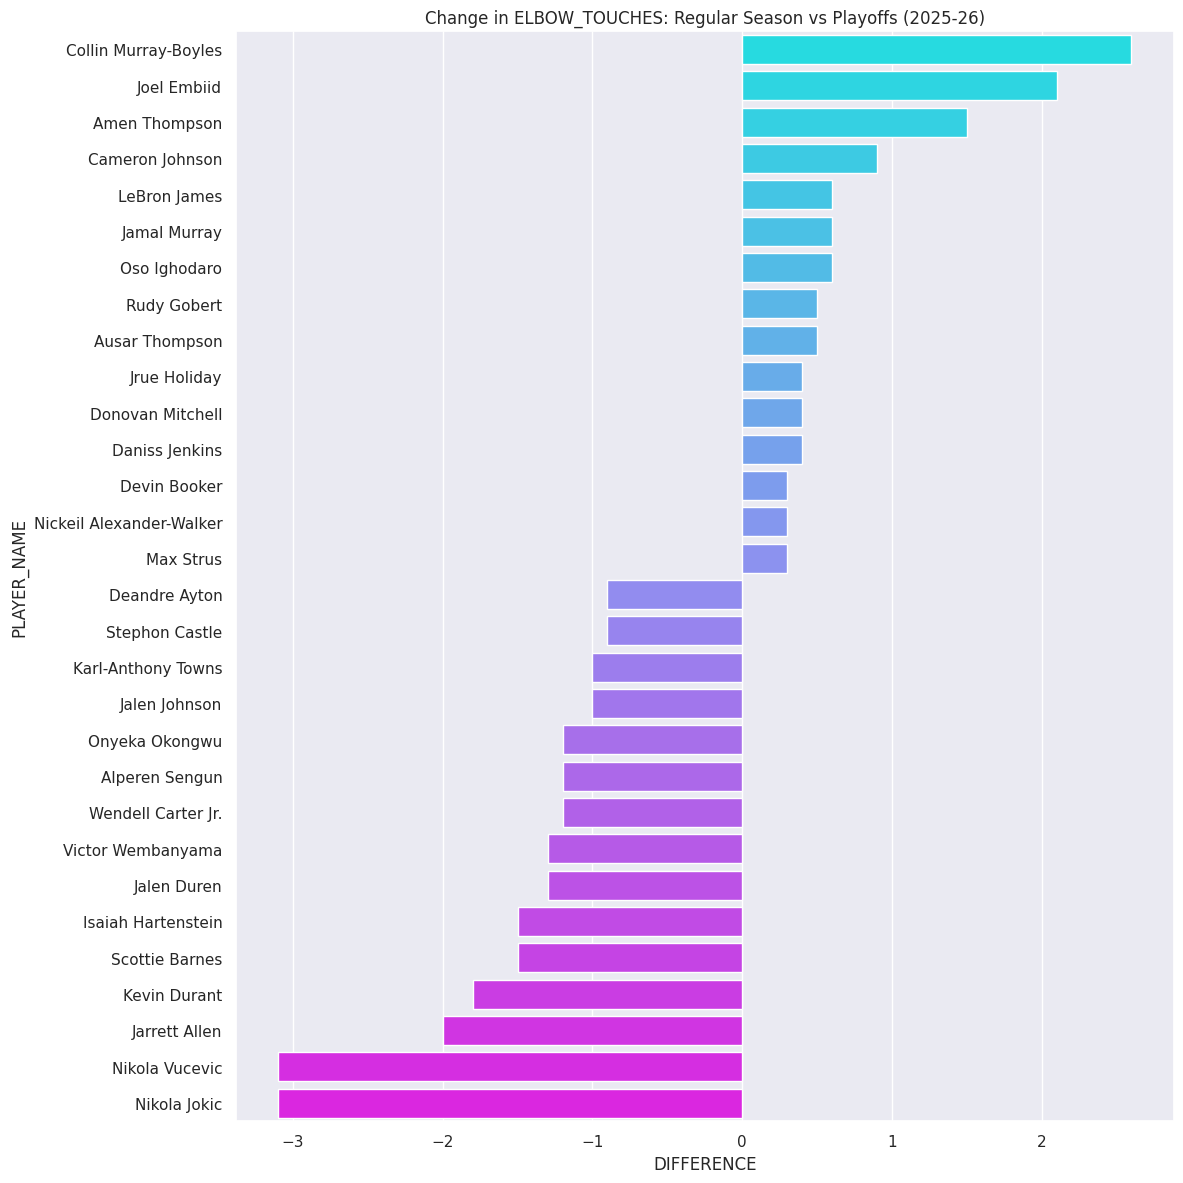

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='ELBOW_TOUCHES',
        query_conditions=["MIN >= 15"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26',
        palette = 'cool',
        n=15
    )

###Speed & Distance

In [ ]:
speed_df = fetch_nba_stats(
    'SpeedDistance',
    ['2024-25', '2025-26'],
    season_types=('Regular Season', 'Playoffs'),
    timeout=180
)

DEBUG: Routing SpeedDistance to source: pt
🌐 Fetching fresh: nba_stats_pt_speeddistance_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_speeddistance_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_speeddistance_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_speeddistance_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_speeddistance_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_speeddistance_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_speeddistance_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_speeddistance_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025

In [ ]:
speed_df

W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Regular Season A.J. Lawson     1630639   TOR               1610612761  14   
                       AJ Green        1631260   MIL               1610612749  44   
                       AJ Johnson      1642358   WAS               1610612764   8   
                       Aaron Gordon    203932    DEN               1610612743  33   
                       Aaron Holiday   1628988   HOU               1610612745  39   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Regular Season A.J. Lawson     1630639   TOR               1610612761  12   
                       AJ Green        1631260   MIL               1610612749  29   
                       AJ Johnson      1642358   WAS               1610612764  21   
                       Aaron Gordon    203932    DEN               1610612743  18   
                       Aaron Holiday   1628988   HOU               1610612745  23   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  30   
                       Zeke Nnaji      1630192   DEN               1610612743  14   
                       Ziaire Williams 1630533   BKN               1610612751  43   
                       Zion Williamson 1629627   NOP               1610612740  40   
                       Zyon Pullin     1642389   MIN               1610612750   1   

                                                                                MIN  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID            
2024-25 Regular Season A.J. Lawson     1630639   TOR               1610612761  18.7   
                       AJ Green        1631260   MIL               1610612749  22.7   
                       AJ Johnson      1642358   WAS               1610612764  22.0   
                       Aaron Gordon    203932    DEN               1610612743  28.4   
                       Aaron Holiday   1628988   HOU               1610612745  12.8   
...                                                                             ...   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  31.4   
                       Zeke Nnaji      1630192   DEN               1610612743  12.0   
                       Ziaire Williams 1630533   BKN               1610612751  22.9   
                       Zion Williamson 1629627   NOP               1610612740  29.7   
                       Zyon Pullin     1642389   MIN               1610612750   8.5   

                                                                               DIST_FEET  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID                 
2024-25 Regular Season A.J. Lawson     1630639   TOR               1610612761     8472.4   
                       AJ Green        1631260   MIL               1610612749     9547.5   
                       AJ Johnson      1642358   WAS               1610612764     9316.1   
                       Aaron Gordon    203932    DEN               1610612743    10697.8   
                       Aaron Holiday   1628988   HOU               1610612745     5042.9   
...                                                                                  ...   


In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'SpeedDistance',
    ['2024-25', '2025-26']
)

DEBUG: Routing SpeedDistance to source: pt
📂 Loading cache: nba_stats_pt_speeddistance_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_pt_speeddistance_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing SpeedDistance to source: pt
📂 Loading cache: nba_stats_pt_speeddistance_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_speeddistance_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_speeddistance_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 683)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.reset_index().to_parquet(
    DATA_DIR / "df_master_current.parquet",
    index=False
)

###Rebounding

In [ ]:
rebounding_df = fetch_nba_stats(
    'Rebounding',
    ['2024-25', '2025-26'],
    season_types=('Regular Season', 'Playoffs'),
    timeout=180
)

DEBUG: Routing Rebounding to source: pt
🌐 Fetching fresh: nba_stats_pt_rebounding_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_rebounding_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 564 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_rebounding_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_rebounding_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 206 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_rebounding_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_rebounding_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 578 rows for 2025-26 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_rebounding_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_rebounding_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 210 rows for 2025-26 (Playoffs)


In [ ]:
rebounding_df.columns

Index(['W', 'L', 'MIN', 'OREB', 'OREB_CONTEST', 'OREB_UNCONTEST',
       'OREB_CONTEST_PCT', 'OREB_CHANCES', 'OREB_CHANCE_PCT',
       'OREB_CHANCE_DEFER', 'OREB_CHANCE_PCT_ADJ', 'AVG_OREB_DIST', 'DREB',
       'DREB_CONTEST', 'DREB_UNCONTEST', 'DREB_CONTEST_PCT', 'DREB_CHANCES',
       'DREB_CHANCE_PCT', 'DREB_CHANCE_DEFER', 'DREB_CHANCE_PCT_ADJ',
       'AVG_DREB_DIST', 'REB', 'REB_CONTEST', 'REB_UNCONTEST',
       'REB_CONTEST_PCT', 'REB_CHANCES', 'REB_CHANCE_PCT', 'REB_CHANCE_DEFER',
       'REB_CHANCE_PCT_ADJ', 'AVG_REB_DIST'],
      dtype='object')

In [ ]:
reb_cols = [
    'OREB_CONTEST', 'OREB_UNCONTEST',
       'OREB_CONTEST_PCT', 'OREB_CHANCES', 'OREB_CHANCE_PCT',
       'OREB_CHANCE_DEFER', 'OREB_CHANCE_PCT_ADJ', 'AVG_OREB_DIST',
       'DREB_CONTEST', 'DREB_UNCONTEST', 'DREB_CONTEST_PCT', 'DREB_CHANCES',
       'DREB_CHANCE_PCT', 'DREB_CHANCE_DEFER', 'DREB_CHANCE_PCT_ADJ',
       'AVG_DREB_DIST', 'REB_CONTEST', 'REB_UNCONTEST',
       'REB_CONTEST_PCT', 'REB_CHANCES', 'REB_CHANCE_PCT', 'REB_CHANCE_DEFER',
       'REB_CHANCE_PCT_ADJ', 'AVG_REB_DIST'
]

df_master = ingest_nba_stat(
    df_master,
    'Rebounding',
    ['2024-25', '2025-26'],
    keep_cols=reb_cols,
    timeout=120
)

DEBUG: Routing Rebounding to source: pt
📂 Loading cache: nba_stats_pt_rebounding_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 564 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_pt_rebounding_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 578 rows for 2025-26 (Regular Season)
DEBUG: Routing Rebounding to source: pt
📂 Loading cache: nba_stats_pt_rebounding_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 206 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_rebounding_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_rebounding_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 210 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 707)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.reset_index().to_parquet(
    DATA_DIR / "df_master_current.parquet",
    index=False
)

###Post Touches

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'PostTouch',
    ['2024-25', '2025-26']
)

DEBUG: Routing PostTouch to source: pt
📂 Loading cache: nba_stats_pt_posttouch_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 569 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_pt_posttouch_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing PostTouch to source: pt
📂 Loading cache: nba_stats_pt_posttouch_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 219 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_posttouch_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_posttouch_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 230 rows for 2025-26 (Playoffs)


In [ ]:
df_master.columns[700:]

Index(['REB_UNCONTEST', 'REB_CONTEST_PCT', 'REB_CHANCES', 'REB_CHANCE_PCT',
       'REB_CHANCE_DEFER', 'REB_CHANCE_PCT_ADJ', 'AVG_REB_DIST',
       'POST_TOUCH_FGM', 'POST_TOUCH_FGA', 'POST_TOUCH_FG_PCT',
       'POST_TOUCH_FTM', 'POST_TOUCH_FTA', 'POST_TOUCH_FT_PCT',
       'POST_TOUCH_PTS', 'POST_TOUCH_PTS_PCT', 'POST_TOUCH_PASSES',
       'POST_TOUCH_PASSES_PCT', 'POST_TOUCH_AST', 'POST_TOUCH_AST_PCT',
       'POST_TOUCH_TOV', 'POST_TOUCH_TOV_PCT', 'POST_TOUCH_FOULS',
       'POST_TOUCH_FOULS_PCT'],
      dtype='object')

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 721)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.reset_index().to_parquet(
    DATA_DIR / "df_master_current.parquet",
    index=False
)

##Synergy Play Types

### Pick & Roll Ball Handler

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'PRBallHandler',
    ['2024-25', '2025-26']
)

DEBUG: Routing PRBallHandler to source: synergy
🌐 Fetching fresh: nba_stats_synergy_prballhandler_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prballhandler_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 338 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_prballhandler_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prballhandler_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 347 rows for 2025-26 (Regular Season)
DEBUG: Routing PRBallHandler to source: synergy
🌐 Fetching fresh: nba_stats_synergy_prballhandler_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prballhandler_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 60 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_prballhandler_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prba

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 258)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.query("GP>=55 & MIN>=20")['PICK_ROLL_BH_POSS'].describe()

In [ ]:
scatter_nba_stats(df_master, 'AVG_SEC_PER_TOUCH', 'PICK_ROLL_BH_PPP', '2025-26',
                  color_stat='PTS', min_pts=10, min_gp=20, custom_query = "PICK_ROLL_BH_POSS>=1",
                  title='% of Unassisted FGM vs Pick & Roll BH')

In [ ]:
df_master.columns

Index(['GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       ...
       'PNRBH_TOV_POSS_PCT', 'PNRBH_SF_POSS_PCT', 'PNRBH_PLUSONE_POSS_PCT',
       'PNRBH_SCORE_POSS_PCT', 'PNRBH_EFG_PCT', 'PNRBH_POSS', 'PNRBH_PTS',
       'PNRBH_FGM', 'PNRBH_FGA', 'PNRBH_FGMX'],
      dtype='object', length=259)

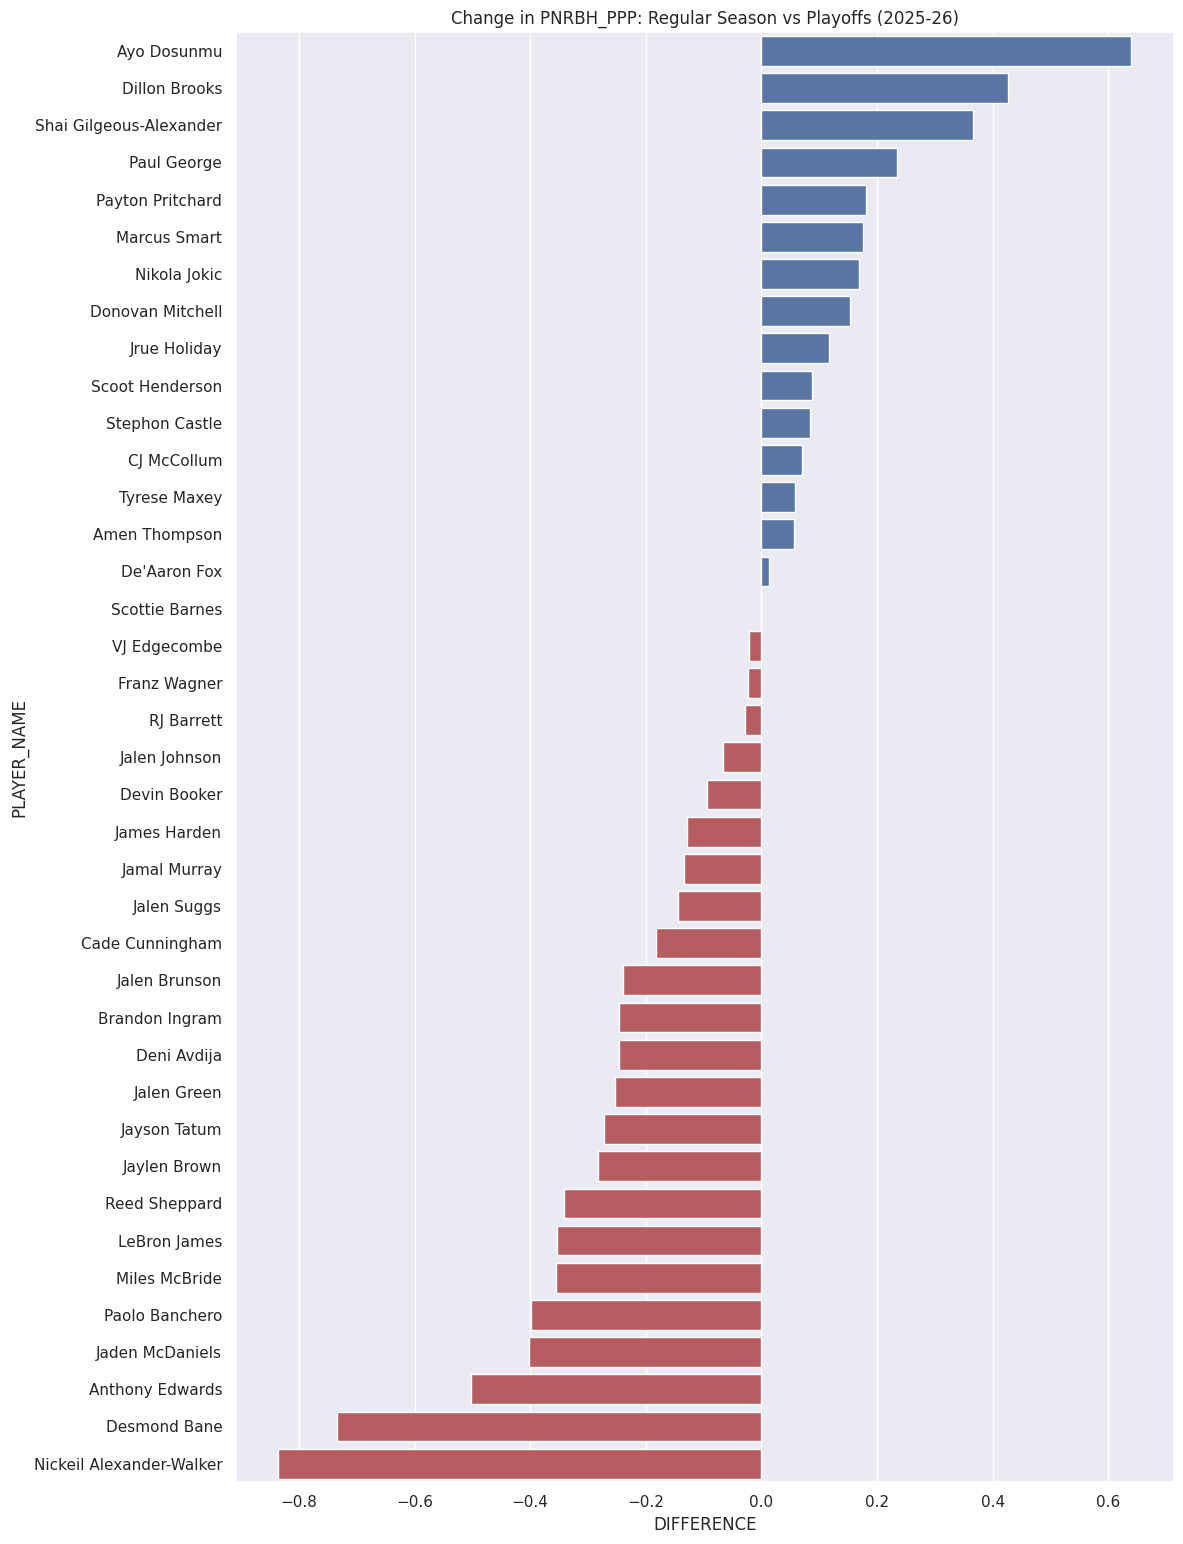

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='PNRBH_PPP',
        query_conditions=["MIN >= 10"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

In [ ]:
plot_interactive_barh(
    pick_and_roll_ball_handler_df,
    x_col='PPP', # This is the numeric stat
    y_col='PLAYER_NAME',      # This is the categorical label
    season='2025-26',
    query_condition="GP >= 50 & POSS >=0.75"
)

### Pick & Roll Roll Man

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'PRRollman',
    ['2024-25', '2025-26']
)

DEBUG: Routing PRRollman to source: synergy
🌐 Fetching fresh: nba_stats_synergy_prrollman_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prrollman_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 279 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_prrollman_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prrollman_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 269 rows for 2025-26 (Regular Season)
DEBUG: Routing PRRollman to source: synergy
🌐 Fetching fresh: nba_stats_synergy_prrollman_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prrollman_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 29 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_prrollman_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_prrollman_2025-26_playoffs_player_pergam

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 639)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
prrollman_po = fetch_nba_stats(
    'PRRollman',
    ['2024-25', '2025-26'],
    season_type='Playoffs',
    timeout=180
)

DEBUG: Routing PRRollman to source: synergy
DEBUG: Fetched 29 rows for 2024-25
DEBUG: Fetched 6 rows for 2025-26


In [ ]:
df_master = sync_and_patch_stat(
    df_master,
    prrollman_po
)

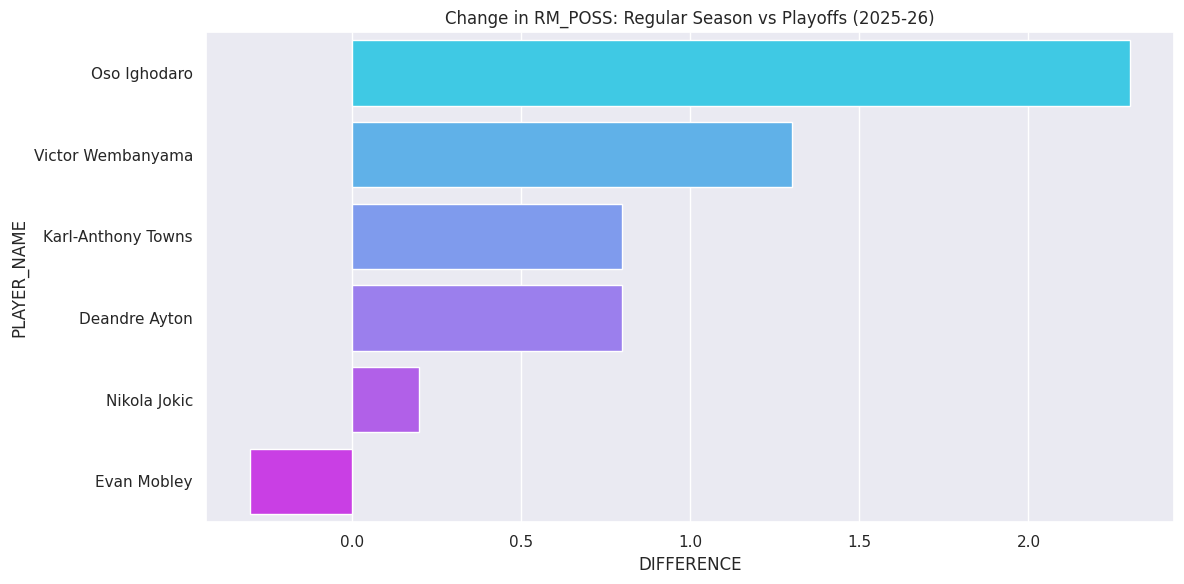

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='RM_POSS',
        query_conditions=["MIN >= 15"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26',
        palette = 'cool',
        n=15
    )

In [ ]:
df_master.query("SEASON == '2025-26' & GP>= 58 & MIN >= 20 & RM_FGA>=0.25").sort_values(by='RM_PPP', ascending=False).iloc[0:60, 490:]

In [ ]:
analyze_player_season_changes(df_master,
                              'RM_PPP',
                              query_conditions="GP>=60 & MIN>=15 & SEASON =='2025-26' & RM_FGA>=0.25", n=20)

### Isolation

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Isolation',
    ['2024-25', '2025-26']
)

DEBUG: Routing Isolation to source: synergy
🌐 Fetching fresh: nba_stats_synergy_isolation_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_isolation_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 281 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_isolation_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_isolation_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 284 rows for 2025-26 (Regular Season)
DEBUG: Routing Isolation to source: synergy
🌐 Fetching fresh: nba_stats_synergy_isolation_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_isolation_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 45 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_isolation_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_isolation_2025-26_playoffs_player_pergam

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 273)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


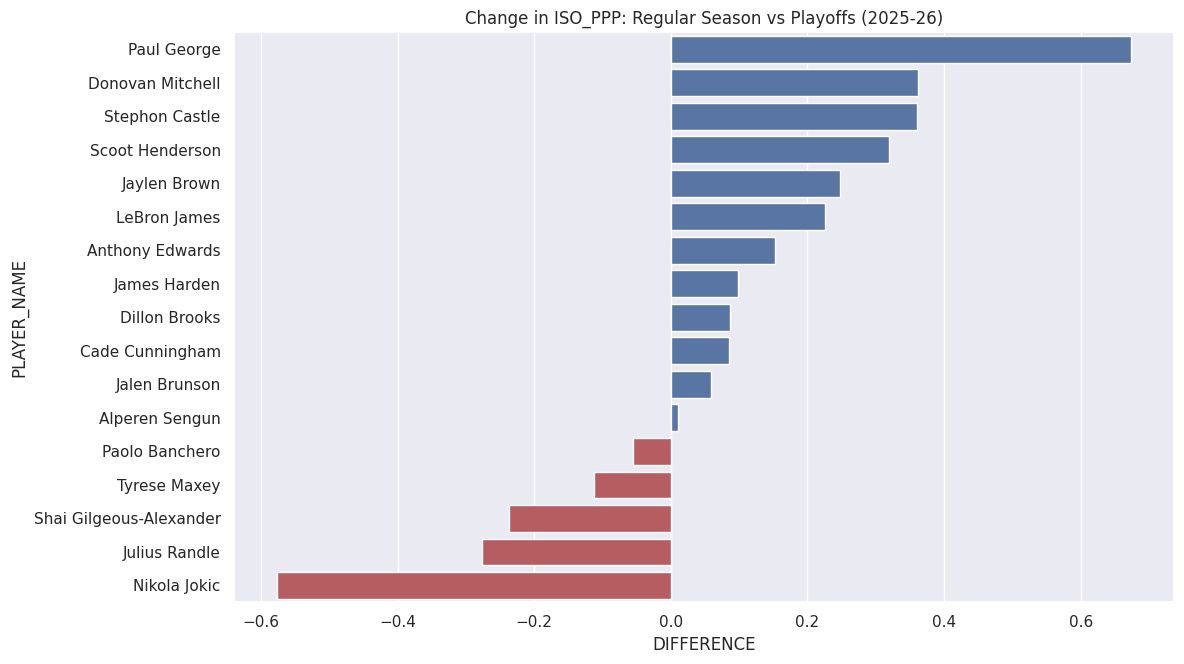

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='ISO_PPP',
        query_conditions=["MIN >= 10"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26'
    )

In [ ]:
scatter_nba_stats(df_master, 'PCT_UAST_FGM', 'ISO_PPP', '2025-26',
                  color_stat='PTS', min_pts=10, min_gp=20, custom_query = "PICK_ROLL_BH_POSS>=1 & ISO_POSS>=0.5",
                  title='% OF FGM UNASSISTED vs Isolation')

### Handoff

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Handoff',
    ['2024-25', '2025-26']
)

DEBUG: Routing Handoff to source: synergy
🌐 Fetching fresh: nba_stats_synergy_handoff_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_handoff_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 282 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_handoff_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_handoff_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 276 rows for 2025-26 (Regular Season)
DEBUG: Routing Handoff to source: synergy
🌐 Fetching fresh: nba_stats_synergy_handoff_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_handoff_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 18 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_handoff_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_handoff_2025-26_playoffs_player_pergame_offensive.parquet


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 544)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.query("SEASON=='2025-26' & GP >= 60 & MIN>=20 & DHO_POSS>=0.5").sort_values(by='DHO_PPP', ascending=False).iloc[0:60, 400:]

In [ ]:
scatter_nba_stats(df_master, 'PNRBH_PPP', 'DHO_PPP', '2025-26',
                  color_stat='PTS', min_pts=10, min_gp=20, custom_query = "PNRBH_POSS>=1 & DHO_POSS>=0.5",
                  title='Pick & Roll vs Dribble Handoff')

In [ ]:
analyze_player_season_changes(df_master,
                              'DHO_POSS', query_conditions="GP>=60 & MIN>=15 & SEASON =='2025-26' & DHO_POSS>=0.5", n=20)

###Post Up

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Postup',
    ['2024-25', '2025-26']
)

DEBUG: Routing Postup to source: synergy
🌐 Fetching fresh: nba_stats_synergy_postup_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_postup_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 145 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_postup_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_postup_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 149 rows for 2025-26 (Regular Season)
DEBUG: Routing Postup to source: synergy
🌐 Fetching fresh: nba_stats_synergy_postup_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_postup_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 21 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_postup_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_postup_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fet

In [ ]:
check_master_integrity

<function nba_viz_utils.check_master_integrity(df)>

In [ ]:
df_master.columns[350:]

In [ ]:
df_master.query("GP >= 50 & SEASON == '2025-26' & MIN >= 20")['POST_POSS'].describe()

In [ ]:
plot_interactive_barh(
    df_master,
    x_col='POST_PPP', # This is the numeric stat
    y_col='PLAYER_NAME',      # This is the categorical label
    season='2025-26',
    query_condition="GP >= 50 & MIN >= 20 & POST_POSS >= 0.25"
)

###Off-Screen

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'OffScreen',
    ['2024-25', '2025-26']
)

DEBUG: Routing OffScreen to source: synergy
🌐 Fetching fresh: nba_stats_synergy_offscreen_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offscreen_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 221 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_offscreen_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offscreen_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 215 rows for 2025-26 (Regular Season)
DEBUG: Routing OffScreen to source: synergy
🌐 Fetching fresh: nba_stats_synergy_offscreen_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offscreen_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 19 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_offscreen_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offscreen_2025-26_playoffs_player_pergam

In [ ]:
offscreen_2425_po = fetch_nba_stats(
    'OffScreen',
    ['2024-25'],
    season_type='Playoffs',
    timeout=180
)

DEBUG: Routing OffScreen to source: synergy
DEBUG: Fetched 19 rows for 2024-25


In [ ]:
df_master = sync_and_patch_stat(
    df_master,
    offscreen_2425_po
)

In [ ]:
df_master

index  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749    0.0   
                       Aaron Gordon    203932    DEN               1610612743    1.0   
                       Aaron Holiday   1628988   HOU               1610612745    2.0   
                       Aaron Nesmith   1630174   IND               1610612754    3.0   
                       Aaron Wiggins   1630598   OKC               1610612760    4.0   
...                                                                              ...   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  577.0   
                       Zeke Nnaji      1630192   DEN               1610612743  578.0   
                       Ziaire Williams 1630533   BKN               1610612751  579.0   
                       Zion Williamson 1629627   NOP               1610612740  580.0   
                       Zyon Pullin     1642389   MIN               1610612750  581.0   

                                                                               GP  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   5   
                       Aaron Gordon    203932    DEN               1610612743  14   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  23   
                       Aaron Wiggins   1630598   OKC               1610612760  22   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  39   
                       Zeke Nnaji      1630192   DEN               1610612743  52   
                       Ziaire Williams 1630533   BKN               1610612751  56   
                       Zion Williamson 1629627   NOP               1610612740  62   
                       Zyon Pullin     1642389   MIN               1610612750   5   

                                                                                W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   1   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  15   
                       Aaron Wiggins   1630598   OKC               1610612760  15   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   4   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   0   
                       Aaron Nesmith   1630174   IND               1610612754   8   
                       Aaron Wiggins   1630598   OKC               1610612760   7   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203

In [ ]:
check_master_integrity

<function nba_viz_utils.check_master_integrity(df)>

In [ ]:
df_master.query("SEASON=='2025-26'").sort_values(by="OFFSCREEN_PTS",ascending=False).iloc[0:60]

###Transition

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Transition',
    ['2024-25', '2025-26']
)

DEBUG: Routing Transition to source: synergy
🌐 Fetching fresh: nba_stats_synergy_transition_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_transition_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 405 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_transition_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_transition_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 409 rows for 2025-26 (Regular Season)
DEBUG: Routing Transition to source: synergy
🌐 Fetching fresh: nba_stats_synergy_transition_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_transition_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 87 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_transition_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_transition_2025-26_playoffs_pla

In [ ]:
transition_po = fetch_nba_stats(
    'Transition',
    ['2024-25'],
    season_type='Playoffs',
    timeout=180
)

df_master = sync_and_patch_stat(
    df_master,
    transition_po
)

DEBUG: Routing Transition to source: synergy
DEBUG: Fetched 87 rows for 2024-25


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 654)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.query("SEASON=='2025-26' & MIN>=20 & GP>=58 & TRANS_FGA>=2")['TRANS_PPP'].sort_values(ascending=False).iloc[0:60]

In [ ]:
players = [
    # 'James Harden',  'Jalen Brunson',
    # 'Jamal Murray', 'LaMelo Ball', 'Tyrese Maxey', 'Donovan Mitchell',
    # 'Kevin Durant', 'Jaylen Brown', 'Cade Cunningham', 'Kawhi Leonard'
    'Jalen Johnson', 'Deni Avdija', 'Scottie Barnes', 'Paolo Banchero',
    'Amen Thompson', 'Brandon Miller'
]

df_master.query("SEASON == '2025-26'").loc[df_master.query("SEASON == '2025-26'").index.get_level_values('PLAYER_NAME').isin(players)]\
[['EFG_PCT', 'TS_PCT','Restricted_Area_FGM', 'Restricted_Area_FGA',
       'Restricted_Area_FG_PCT', 'In_The_Paint_Non_RA_FGM',
       'In_The_Paint_Non_RA_FGA', 'In_The_Paint_Non_RA_FG_PCT',
       'Mid_Range_FGM', 'Mid_Range_FGA', 'Mid_Range_FG_PCT', 'Above_the_Break_3_FGM',
    'Above_the_Break_3_FGA', 'Above_the_Break_3_FG_PCT', 'SHOT_FG2_PCT', 'PCT_PTS_FB','AST_PCT', 'TM_TOV_PCT', 'AST_TO','AST_POINTS_CREATED', 'SECONDARY_AST','DRIVE_PTS',\
      'AVG_SEC_PER_TOUCH', 'PNRBH_PPP', 'ISO_PPP', 'DHO_PPP', 'OFFSCREEN_PPP','PCT_UAST_FGM', 'PULL_UP_FG3_PCT',
  'PAINT_TOUCH_PTS_PCT', 'PAINT_TOUCH_PASSES_PCT','CATCH_SHOOT_FG3_PCT', 'PTS_PER_ELBOW_TOUCH', 'DRIBB_3_6_FG2A', 'DRIBB_3_6_FG2_PCT',]].iloc[:,0:20]

###Spot Up

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Spotup',
    ['2024-25', '2025-26']
)

DEBUG: Routing Spotup to source: synergy
🌐 Fetching fresh: nba_stats_synergy_spotup_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_spotup_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 399 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_spotup_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_spotup_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 400 rows for 2025-26 (Regular Season)
DEBUG: Routing Spotup to source: synergy
🌐 Fetching fresh: nba_stats_synergy_spotup_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_spotup_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 113 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_spotup_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_spotup_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fe

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 676)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.reset_index().to_parquet(
    DATA_DIR / "df_master_current.parquet",
    index=False
)

### Cuts

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'Cut',
    ['2024-25', '2025-26']
)

DEBUG: Routing Cut to source: synergy
🌐 Fetching fresh: nba_stats_synergy_cut_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_cut_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 338 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_cut_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_cut_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 339 rows for 2025-26 (Regular Season)
DEBUG: Routing Cut to source: synergy
🌐 Fetching fresh: nba_stats_synergy_cut_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_cut_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 40 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_cut_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_cut_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 29 rows for 2025-26 (Play

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 559)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.columns[310:]

In [ ]:
analyze_player_season_changes(df_master, 'CUT_POSS', query_conditions="GP>=60 & MIN>=20 & SEASON =='2025-26' & CUT_POSS>=0.5", n=20)

In [ ]:
plot_interactive_barh(df_master[df_master['PLAYER_POSITION'].str.contains('G', na=False)],
                      x_col = 'CUT_POSS',
                      y_col = 'PLAYER_NAME',
                      season = '2025-26',
                      query_condition = "GP>=50 & CUT_POSS>=0.25",
                      title = "Cuts PPP")

### Putbacks

In [ ]:
putback_df = fetch_nba_stats(
    'OffRebound',
    ['2024-25', '2025-26'],
    season_types=('Regular Season', 'Playoffs'),
    timeout=180
)

DEBUG: Routing OffRebound to source: synergy
📂 Loading cache: nba_stats_synergy_offrebound_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 316 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_synergy_offrebound_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 33 rows for 2024-25 (Playoffs)
📂 Loading cache: nba_stats_synergy_offrebound_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 301 rows for 2025-26 (Regular Season)
🌐 Fetching fresh: nba_stats_synergy_offrebound_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offrebound_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 23 rows for 2025-26 (Playoffs)


In [ ]:
putback_df.columns

Index(['index', 'SEASON_ID', 'TEAM_NAME', 'PLAY_TYPE', 'TYPE_GROUPING',
       'PUTBACK_PERCENTILE', 'PUTBACK_POSS_PCT', 'PUTBACK_PPP',
       'PUTBACK_FG_PCT', 'PUTBACK_FT_POSS_PCT', 'PUTBACK_TOV_POSS_PCT',
       'PUTBACK_SF_POSS_PCT', 'PUTBACK_PLUSONE_POSS_PCT',
       'PUTBACK_SCORE_POSS_PCT', 'PUTBACK_EFG_PCT', 'PUTBACK_POSS',
       'PUTBACK_PTS', 'PUTBACK_FGM', 'PUTBACK_FGA', 'PUTBACK_FGMX'],
      dtype='object')

In [ ]:
df_master = ingest_nba_stat(
    df_master,
    'OffRebound',
    ['2024-25', '2025-26']
)

DEBUG: Routing OffRebound to source: synergy
📂 Loading cache: nba_stats_synergy_offrebound_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 316 rows for 2024-25 (Regular Season)
📂 Loading cache: nba_stats_synergy_offrebound_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 301 rows for 2025-26 (Regular Season)
DEBUG: Routing OffRebound to source: synergy
📂 Loading cache: nba_stats_synergy_offrebound_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 33 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_synergy_offrebound_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offrebound_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 23 rows for 2025-26 (Playoffs)


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 737)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
for st in ['Regular Season', 'Playoffs']:
    df_master = refresh_and_patch_nba_stat(
        df_master, 'OffRebound', '2025-26', st,
        force_refresh=True,
    )

DEBUG: Routing OffRebound to source: synergy
🌐 Fetching fresh: nba_stats_synergy_offrebound_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offrebound_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 301 rows for 2025-26 (Regular Season)
DEBUG: Routing OffRebound to source: synergy
🌐 Fetching fresh: nba_stats_synergy_offrebound_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_synergy_offrebound_2025-26_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 29 rows for 2025-26 (Playoffs)


In [ ]:
s = df_master.xs('2025-26', level='SEASON')
s.groupby(level='SEASON_TYPE')['PUTBACK_POSS'].apply(lambda x: x.isna().mean())

,PUTBACK_POSS
SEASON_TYPE,
Playoffs,0.873913
Regular Season,0.529210


In [ ]:
df_master = normalize_master(df_master)
df_master.groupby(level='SEASON').size()       # sanity-check the per-season counts
# df_master.to_parquet(DATA_DIR / "df_master_current.parquet")

,0
SEASON,
2015-16,691
2016-17,701
2017-18,750
2018-19,742
2019-20,746
2020-21,779
2021-22,822
2022-23,756
2023-24,786


## Shot Dashboard

### General

In [ ]:
general_shots_cols = [
    'SHOT_FG2A_FREQUENCY',
    'SHOT_FG2M',
    'SHOT_FG2A',
    'SHOT_FG2_PCT',
    'SHOT_FG3A_FREQUENCY',
]

df_master = ingest_nba_stat(
    df_master,
    'General',
    ['2024-25', '2025-26'],
    suffix='gen_shots',
    keep_cols=general_shots_cols
)

DEBUG: Routing General to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_general_2024-25_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_shot_general_2024-25_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 566 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_shot_general_2025-26_regular_season_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_shot_general_2025-26_regular_season_player_pergame_offensive.parquet
DEBUG: Fetched 582 rows for 2025-26 (Regular Season)
DEBUG: Routing General to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_general_2024-25_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_shot_general_2024-25_playoffs_player_pergame_offensive.parquet
DEBUG: Fetched 217 rows for 2024-25 (Playoffs)
🌐 Fetching fresh: nba_stats_pt_shot_general_2025-26_playoffs_player_pergame_offensive.parquet
💾 Saved cache: nba_stats_pt_shot_general_2025-26_playoffs_player_pergame_offensive.parquet

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 278)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


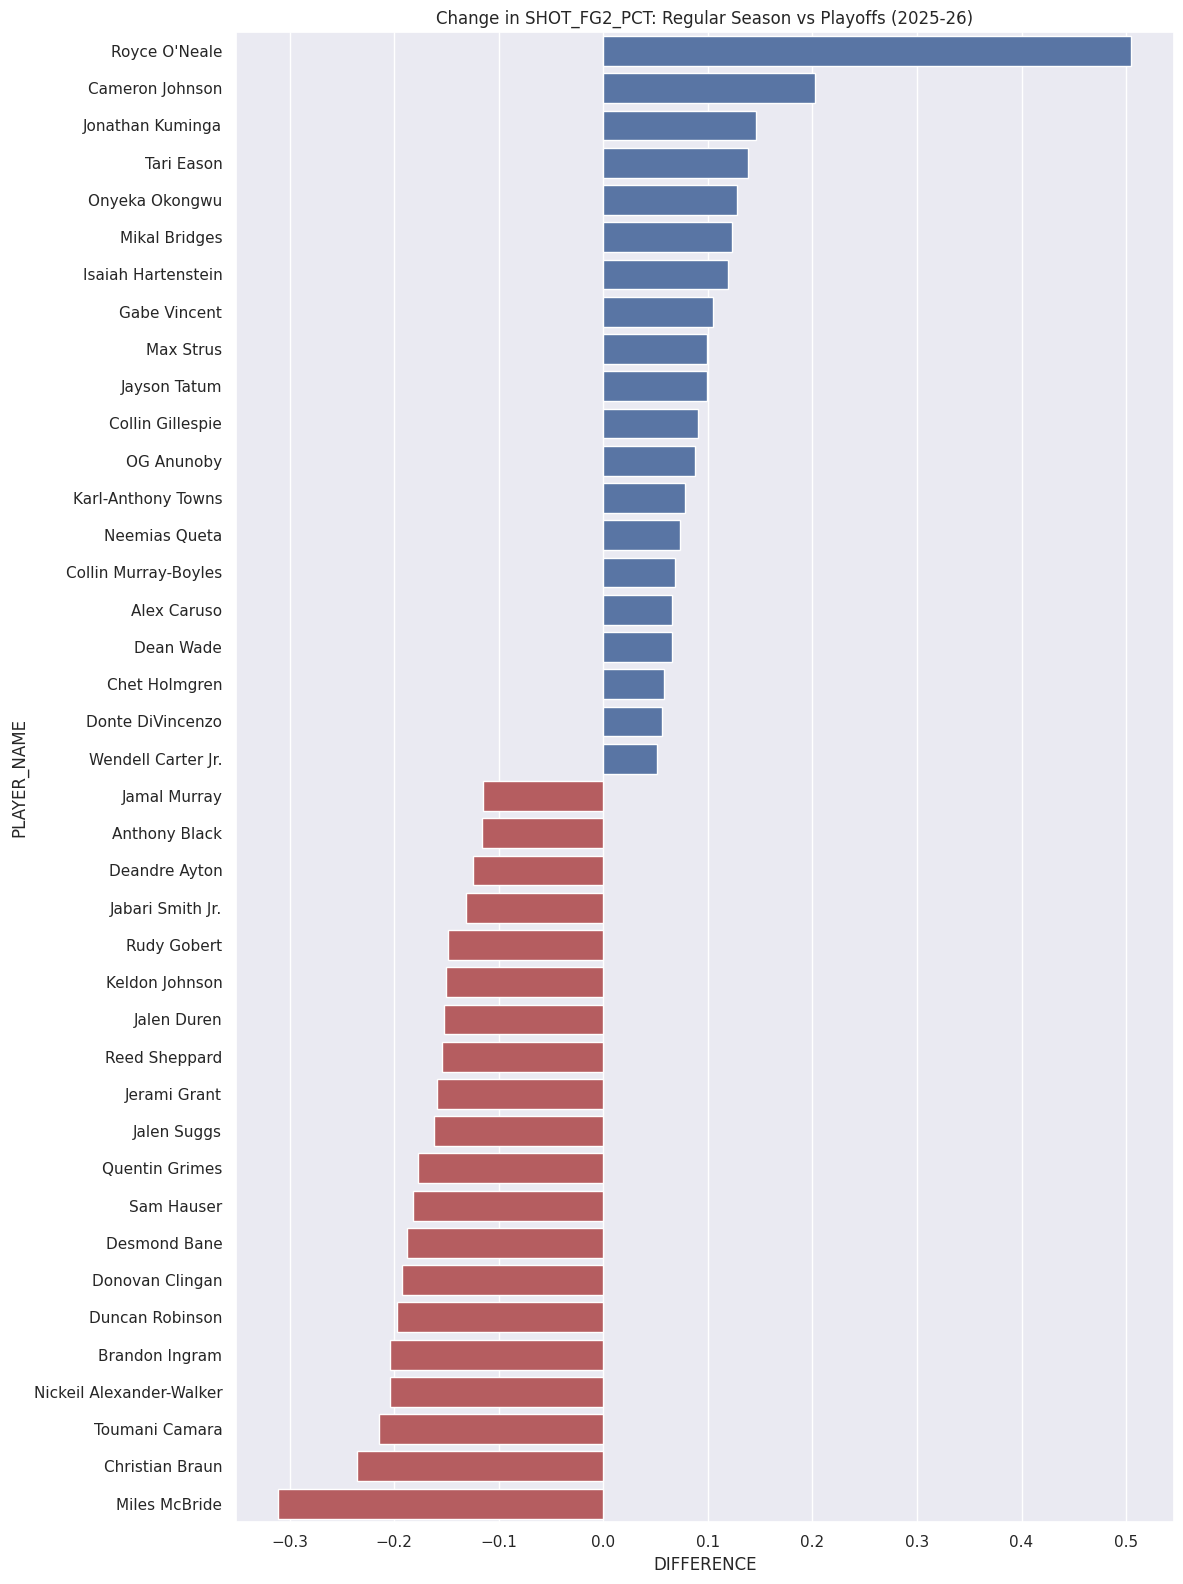

In [ ]:
df_results, fig = analyze_player_changes(
        df=df_master,
        stat_column='SHOT_FG2_PCT',
        query_conditions=["MIN >= 15 & GP>=3"],
        compare_col='SEASON_TYPE',
        base='Regular Season',
        comp='Playoffs',
        season_filter='2025-26',
        n=20
    )

### Dribbles

In [ ]:
dribble_df = build_bucketed_features(
    stat_type='Dribble',
    seasons=['2024-25','2025-26'],
    buckets=['0 Dribbles', '1 Dribble', '2 Dribbles', '3-6 Dribbles', '7+ Dribbles'],
    prefix='DRIBB_',
    param_name='dribble_range_nullable',
    fetch_fn=fetch_nba_stats
)

🚀 Dribble: 0 Dribbles (Regular Season)
DEBUG: Routing Dribble to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_dribble_2024-25_regular_season_player_pergame_offensive_dribble_range_nullable_0_dribbles.parquet
💾 Saved cache: nba_stats_pt_shot_dribble_2024-25_regular_season_player_pergame_offensive_dribble_range_nullable_0_dribbles.parquet
DEBUG: Fetched 562 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_shot_dribble_2025-26_regular_season_player_pergame_offensive_dribble_range_nullable_0_dribbles.parquet
💾 Saved cache: nba_stats_pt_shot_dribble_2025-26_regular_season_player_pergame_offensive_dribble_range_nullable_0_dribbles.parquet
DEBUG: Fetched 578 rows for 2025-26 (Regular Season)
✅ Added 0 Dribbles (Regular Season)
🚀 Dribble: 1 Dribble (Regular Season)
DEBUG: Routing Dribble to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_dribble_2024-25_regular_season_player_pergame_offensive_dribble_range_nullable_1_dribble.parquet
💾 Saved cache: nba_stats_pt_shot_d

In [ ]:
df_master = update_master_df(df_master, dribble_df, suffix='dribble')

check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 343)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
dupes = df_master.reset_index().duplicated(
    subset=INDEX_COLS,
    keep=False
)

df_master.reset_index()[dupes].sort_values(INDEX_COLS)

,SEASON,SEASON_TYPE,PLAYER_NAME,PLAYER_ID,TEAM_ABBREVIATION,TEAM_ID,index,GP,W,L,...,DRIBB_7P_FG_PCT,DRIBB_7P_EFG_PCT,DRIBB_7P_FG2A_FREQUENCY,DRIBB_7P_FG2M,DRIBB_7P_FG2A,DRIBB_7P_FG2_PCT,DRIBB_7P_FG3A_FREQUENCY,DRIBB_7P_FG3M,DRIBB_7P_FG3A,DRIBB_7P_FG3_PCT


### Touch Time

In [ ]:
touch_time_df = build_bucketed_features(
    stat_type='TouchTime',
    seasons=['2024-25','2025-26'],
    buckets=['Touch < 2 Seconds', 'Touch 2-6 Seconds', 'Touch 6+ Seconds'],
    prefix='TOUCH_',
    param_name='touch_time_range_nullable',
    fetch_fn=fetch_nba_stats,
    sleep_time=5                    # Keep this at 5 to avoid API rate limits
)

🚀 TouchTime: Touch < 2 Seconds (Regular Season)
DEBUG: Routing TouchTime to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_touchtime_2024-25_regular_season_player_pergame_offensive_touch_time_range_nullable_touch_<_2_seconds.parquet
💾 Saved cache: nba_stats_pt_shot_touchtime_2024-25_regular_season_player_pergame_offensive_touch_time_range_nullable_touch_<_2_seconds.parquet
DEBUG: Fetched 563 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_shot_touchtime_2025-26_regular_season_player_pergame_offensive_touch_time_range_nullable_touch_<_2_seconds.parquet
💾 Saved cache: nba_stats_pt_shot_touchtime_2025-26_regular_season_player_pergame_offensive_touch_time_range_nullable_touch_<_2_seconds.parquet
DEBUG: Fetched 579 rows for 2025-26 (Regular Season)
✅ Added Touch < 2 Seconds (Regular Season)
🚀 TouchTime: Touch 2-6 Seconds (Regular Season)
DEBUG: Routing TouchTime to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_touchtime_2024-25_regular_season_player_pergame_offen

In [ ]:
df_master = update_master_df(df_master, touch_time_df, suffix='touchtime')

check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 382)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.xs(('2025-26', 'Playoffs', ),
                         level=('SEASON', 'SEASON_TYPE'))\
                         .sort_values('PTS', ascending=False)\
                          [['GP','MIN', 'PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV',\
                            'FG_PCT', 'SHOT_FG2_PCT','FG3_PCT','EFG_PCT','TS_PCT','USG_PCT',\
                            'TM_TOV_PCT', 'AVG_SEC_PER_TOUCH', 'DRIVES',\
                            'Restricted_Area_FG_PCT','Above_the_Break_3_FG_PCT',\
                            'PNRBH_PPP', 'ISO_PPP']].iloc[0:60, 1:]

,,,,MIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,SHOT_FG2_PCT,FG3_PCT,EFG_PCT,TS_PCT,USG_PCT,TM_TOV_PCT,AVG_SEC_PER_TOUCH,DRIVES,Restricted_Area_FG_PCT,Above_the_Break_3_FG_PCT,PNRBH_PPP,ISO_PPP
PLAYER_NAME,PLAYER_ID,TEAM_ABBREVIATION,TEAM_ID,,,,,,,,,,,,,,,,,,,,
Cade Cunningham,1630595,DET,1610612765,41.1,30.0,5.5,7.7,1.1,0.7,5.8,0.444,0.454,0.424,0.514,0.586,0.325,14.8,5.55,19.7,0.682,0.413,0.917,0.762
Shai Gilgeous-Alexander,1628983,OKC,1610612760,34.8,29.1,3.0,7.1,0.8,0.9,3.0,0.514,0.564,0.323,0.547,0.631,0.321,9.0,5.57,18.1,0.639,0.321,1.254,1.060
Jalen Brunson,1628973,NYK,1610612752,34.7,27.4,2.6,6.1,0.9,0.0,2.2,0.485,0.522,0.409,0.552,0.601,0.310,7.1,5.76,15.4,0.582,0.426,1.010,1.158
Donovan Mitchell,1628378,CLE,1610612739,36.2,26.3,5.3,2.9,0.8,0.2,2.5,0.455,0.560,0.308,0.519,0.559,0.304,8.6,4.80,12.7,0.604,0.322,1.068,1.019
Paolo Banchero,1631094,ORL,1610612753,39.0,26.3,9.0,6.3,1.4,0.7,3.4,0.420,0.455,0.333,0.469,0.524,0.314,9.9,4.47,18.6,0.516,0.333,0.818,0.780
Dillon Brooks,1628415,PHX,1610612756,37.3,26.0,6.0,1.8,0.3,0.3,1.5,0.459,0.472,0.438,0.541,0.576,0.268,5.9,3.47,10.5,0.400,0.500,1.462,0.789
Nikola Jokic,203999,DEN,1610612743,39.5,25.8,13.2,9.5,1.0,0.8,3.8,0.446,0.553,0.194,0.475,0.554,0.295,10.5,2.95,8.3,0.655,0.219,0.963,0.571
Jaylen Brown,1627759,BOS,1610612738,35.6,25.7,5.7,3.3,0.9,1.1,3.6,0.455,0.475,0.405,0.514,0.551,0.325,11.9,4.29,18.1,0.643,0.429,0.762,0.935
Scottie Barnes,1630567,TOR,1610612761,39.0,24.1,6.1,8.6,1.1,1.7,3.4,0.509,0.537,0.381,0.543,0.605,0.256,10.7,4.37,16.7,0.641,0.350,0.811,0.800


### Shot Clock

In [ ]:
shot_clock_df = build_bucketed_features(
    stat_type='ShotClock',
    seasons=['2024-25','2025-26'],
    buckets=['24-22', '22-18 Very Early', '18-15 Early', '15-7 Average', '7-4 Late', '4-0 Very Late'],
    prefix='SC_',
    param_name='shot_clock_range_nullable',
    fetch_fn=fetch_nba_stats,
    sleep_time=5                    # Keep this at 5 to avoid API rate limits
)

🚀 ShotClock: 24-22 (Regular Season)
DEBUG: Routing ShotClock to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_shotclock_2024-25_regular_season_player_pergame_offensive_shot_clock_range_nullable_24-22.parquet
💾 Saved cache: nba_stats_pt_shot_shotclock_2024-25_regular_season_player_pergame_offensive_shot_clock_range_nullable_24-22.parquet
DEBUG: Fetched 488 rows for 2024-25 (Regular Season)
🌐 Fetching fresh: nba_stats_pt_shot_shotclock_2025-26_regular_season_player_pergame_offensive_shot_clock_range_nullable_24-22.parquet
💾 Saved cache: nba_stats_pt_shot_shotclock_2025-26_regular_season_player_pergame_offensive_shot_clock_range_nullable_24-22.parquet
DEBUG: Fetched 511 rows for 2025-26 (Regular Season)
✅ Added 24-22 (Regular Season)
🚀 ShotClock: 22-18 Very Early (Regular Season)
DEBUG: Routing ShotClock to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_shotclock_2024-25_regular_season_player_pergame_offensive_shot_clock_range_nullable_22-18_very_early.parquet
💾 Saved cache: nb

In [ ]:
df_master = update_master_df(df_master, shot_clock_df, suffix='shotclock')

check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 460)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


### Closest Defender

In [ ]:
closest_defender_df = build_bucketed_features(
    stat_type='ClosestDefender',
    seasons=['2024-25','2025-26'],
    buckets=['0-2 Feet - Very Tight', '2-4 Feet - Tight', '4-6 Feet - Open', '6+ Feet - Wide Open'],
    prefix='CLOSESTDEF_',
    param_name='close_def_dist_range_nullable',
    fetch_fn=fetch_nba_stats,
    sleep_time=5                    # Keep this at 5 to avoid API rate limits
)

🚀 ClosestDefender: 0-2 Feet - Very Tight (Regular Season)
DEBUG: Routing ClosestDefender to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_closestdefender_2024-25_regular_season_player_pergame_offensive_close_def_dist_range_nullable_0-2_feet_-_very_tight.parquet
DEBUG: API Error for ClosestDefender in 2024-25 (Regular Season): Expecting value: line 1 column 1 (char 0)
🌐 Fetching fresh: nba_stats_pt_shot_closestdefender_2025-26_regular_season_player_pergame_offensive_close_def_dist_range_nullable_0-2_feet_-_very_tight.parquet
💾 Saved cache: nba_stats_pt_shot_closestdefender_2025-26_regular_season_player_pergame_offensive_close_def_dist_range_nullable_0-2_feet_-_very_tight.parquet
DEBUG: Fetched 536 rows for 2025-26 (Regular Season)
✅ Added 0-2 Feet - Very Tight (Regular Season)
🚀 ClosestDefender: 2-4 Feet - Tight (Regular Season)
DEBUG: Routing ClosestDefender to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_closestdefender_2024-25_regular_season_player_pergame_offensive_clos

In [ ]:
df_master = update_master_df(df_master, closest_defender_df, suffix='closestdef')

check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 512)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
cd = build_bucketed_features(
    stat_type='ClosestDefender',
    seasons=['2024-25'],
    buckets=['0-2 Feet - Very Tight', '2-4 Feet - Tight',
             '4-6 Feet - Open', '6+ Feet - Wide Open'],
    prefix='CLOSESTDEF_',
    param_name='close_def_dist_range_nullable',
    fetch_fn=fetch_nba_stats,
    force_refresh=True,
)
cd_cols = [c for c in cd.columns if c.startswith('CLOSESTDEF_')]
df_master = sync_and_patch_stat(df_master, cd[cd_cols])

🚀 ClosestDefender: 0-2 Feet - Very Tight (Regular Season)
DEBUG: Routing ClosestDefender to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_closestdefender_2024-25_regular_season_player_pergame_offensive_close_def_dist_range_nullable_0-2_feet_-_very_tight.parquet
💾 Saved cache: nba_stats_pt_shot_closestdefender_2024-25_regular_season_player_pergame_offensive_close_def_dist_range_nullable_0-2_feet_-_very_tight.parquet
DEBUG: Fetched 528 rows for 2024-25 (Regular Season)
✅ Added 0-2 Feet - Very Tight (Regular Season)
🚀 ClosestDefender: 2-4 Feet - Tight (Regular Season)
DEBUG: Routing ClosestDefender to source: pt_shot
🌐 Fetching fresh: nba_stats_pt_shot_closestdefender_2024-25_regular_season_player_pergame_offensive_close_def_dist_range_nullable_2-4_feet_-_tight.parquet
💾 Saved cache: nba_stats_pt_shot_closestdefender_2024-25_regular_season_player_pergame_offensive_close_def_dist_range_nullable_2-4_feet_-_tight.parquet
DEBUG: Fetched 558 rows for 2024-25 (Regular Season)
✅ Added 2-4 

In [ ]:
df_master.reset_index().to_parquet(
    DATA_DIR / "df_master_current.parquet",
    index=False
)

## Defensive Dashboard

In [ ]:
def_cols

['D_FGM', 'D_FGA', 'D_FG_PCT', 'PCT_PLUSMINUS', 'PLAYER_POSITION']

In [ ]:
df_master = ingest_stat(
    df_master,
    fetch_nba_defensive_dashboard,
    seasons=['2024-25', '2025-26'],
    suffix='def',
    keep_cols=def_cols,
    timeout=120
)

🛡️ Fetching Defensive Dashboard for 2024-25 (Regular Season)...
📂 Loading cache: defensive_dashboard_2024-25_regular_season_pergame.parquet
🛡️ Fetching Defensive Dashboard for 2025-26 (Regular Season)...
📂 Loading cache: defensive_dashboard_2025-26_regular_season_pergame.parquet
🛡️ Fetching Defensive Dashboard for 2024-25 (Playoffs)...
📂 Loading cache: defensive_dashboard_2024-25_playoffs_pergame.parquet
🛡️ Fetching Defensive Dashboard for 2025-26 (Playoffs)...
🌐 Fetching fresh: defensive_dashboard_2025-26_playoffs_pergame.parquet
💾 Saved cache: defensive_dashboard_2025-26_playoffs_pergame.parquet


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 640)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master = ingest_stat(
    df_master,
    fetch_nba_defensive_breakdowns,
    seasons=['2024-25', '2025-26'],
    suffix='def_breakdown',
    season_types=("Regular Season", "Playoffs"),
    force_refresh=False,
)

🛡️ Defense [2 Pointers] — 2024-25 (Regular Season)
🌐 Fetching fresh: def_breakdown_2_pointers_2024-25_regular_season_pergame.parquet
💾 Saved cache: def_breakdown_2_pointers_2024-25_regular_season_pergame.parquet
🛡️ Defense [3 Pointers] — 2024-25 (Regular Season)
🌐 Fetching fresh: def_breakdown_3_pointers_2024-25_regular_season_pergame.parquet
💾 Saved cache: def_breakdown_3_pointers_2024-25_regular_season_pergame.parquet
🛡️ Defense [Less Than 6Ft] — 2024-25 (Regular Season)
🌐 Fetching fresh: def_breakdown_less_than_6ft_2024-25_regular_season_pergame.parquet
💾 Saved cache: def_breakdown_less_than_6ft_2024-25_regular_season_pergame.parquet
🛡️ Defense [Less Than 10Ft] — 2024-25 (Regular Season)
🌐 Fetching fresh: def_breakdown_less_than_10ft_2024-25_regular_season_pergame.parquet
💾 Saved cache: def_breakdown_less_than_10ft_2024-25_regular_season_pergame.parquet
🛡️ Defense [Greater Than 15Ft] — 2024-25 (Regular Season)
🌐 Fetching fresh: def_breakdown_greater_than_15ft_2024-25_regular_season_

In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 670)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.columns[600:]

Index(['REB_CHANCES', 'REB_CHANCE_PCT', 'REB_CHANCE_DEFER',
       'REB_CHANCE_PCT_ADJ', 'AVG_REB_DIST', 'POST_TOUCH_FGM',
       'POST_TOUCH_FGA', 'POST_TOUCH_FG_PCT', 'POST_TOUCH_FTM',
       'POST_TOUCH_FTA', 'POST_TOUCH_FT_PCT', 'POST_TOUCH_PTS',
       'POST_TOUCH_PTS_PCT', 'POST_TOUCH_PASSES', 'POST_TOUCH_PASSES_PCT',
       'POST_TOUCH_AST', 'POST_TOUCH_AST_PCT', 'POST_TOUCH_TOV',
       'POST_TOUCH_TOV_PCT', 'POST_TOUCH_FOULS', 'POST_TOUCH_FOULS_PCT',
       'PUTBACK_PERCENTILE', 'PUTBACK_POSS_PCT', 'PUTBACK_PPP',
       'PUTBACK_FG_PCT', 'PUTBACK_FT_POSS_PCT', 'PUTBACK_TOV_POSS_PCT',
       'PUTBACK_SF_POSS_PCT', 'PUTBACK_PLUSONE_POSS_PCT',
       'PUTBACK_SCORE_POSS_PCT', 'PUTBACK_EFG_PCT', 'PUTBACK_POSS',
       'PUTBACK_PTS', 'PUTBACK_FGM', 'PUTBACK_FGA', 'PUTBACK_FGMX', 'index',
       'TEAM_NAME', 'DEF_WS', 'PLAYER_POSITION', 'DEF2_FREQ', 'DEF2_FG2M',
       'DEF2_FG2A', 'DEF2_FG2_PCT', 'DEF2_NS_FG2_PCT', 'DEF2_PLUSMINUS',
       'DEF3_FREQ', 'DEF3_FG3M', 'DEF3_FG3A', 'DE

In [ ]:
df_master.query("SEASON=='2025-26' & SEASON_TYPE=='Playoffs' & TEAM_ABBREVIATION=='DEN'")[['PLAYER_POSITION', 'D_FGM', 'D_FGA', 'D_FG_PCT', 'PCT_PLUSMINUS']]

PLAYER_POSITION  \
SEASON  SEASON_TYPE PLAYER_NAME       PLAYER_ID TEAM_ABBREVIATION TEAM_ID                      
2025-26 Playoffs    Aaron Gordon      203932    DEN               1610612743               F   
                    Bruce Brown       1628971   DEN               1610612743             G-F   
                    Cameron Johnson   1629661   DEN               1610612743               F   
                    Christian Braun   1631128   DEN               1610612743               G   
                    DaRon Holmes II   1641747   DEN               1610612743               F   
                    Jalen Pickett     1629618   DEN               1610612743               G   
                    Jamal Murray      1627750   DEN               1610612743               G   
                    Jonas Valanciunas 202685    DEN               1610612743               C   
                    Julian Strawther  1631124   DEN               1610612743               G   
                    Nikola Jokic      203999    DEN               1610612743               C   
                    Spencer Jones     1642461   DEN               1610612743               F   
                    Tim Hardaway Jr.  203501    DEN               1610612743             G-F   
                    Tyus Jones        1626145   DEN               1610612743               G   
                    Zeke Nnaji        1630192   DEN               1610612743             F-C   

                                                                              D_FGM  \
SEASON  SEASON_TYPE PLAYER_NAME       PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2025-26 Playoffs    Aaron Gordon      203932    DEN               1610612743   8.00   
                    Bruce Brown       1628971   DEN               1610612743   3.25   
                    Cameron Johnson   1629661   DEN               1610612743   3.75   
                    Christian Braun   1631128   DEN               1610612743   4.25   
                    DaRon Holmes II   1641747   DEN               1610612743   1.00   
                    Jalen Pickett     1629618   DEN               1610612743   0.00   
                    Jamal Murray      1627750   DEN               1610612743   6.75   
                    Jonas Valanciunas 202685    DEN               1610612743   3.00   
                    Julian Strawther  1631124   DEN               1610612743   6.00   
                    Nikola Jokic      203999    DEN               1610612743  11.00   
                    Spencer Jones     1642461   DEN               1610612743   2.00   
                    Tim Hardaway Jr.  203501    DEN               1610612743   4.50   
                    Tyus Jones        1626145   DEN               1610612743   1.00   
                    Zeke Nnaji        1630192   DEN               1610612743   2.00   

                                                                              D_FGA  \
SEASON  SEASON_TYPE PLAYER_NAME       PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2025-26 Playoffs    Aaron Gordon      203932    DEN               1610612743  16.33   
                    Bruce Brown       1628971   DEN               1610612743   6.50   
                    Cameron Johnson   1629661   DEN               1610612743   9.00   
                    Christian Braun   1631128   DEN               1610612743  10.50   
                    DaRon Holmes II   1641747   DEN               1610612743   3.00   
                    Jalen Pickett     1629618   DEN               1610612743   3.00   
                    Jamal Murray      1627750   DEN               1610612743  12.75   
                    Jonas Valanciunas 202685    DEN               1610612743   6.50   
                    Julian Strawther  1631124   DEN               1610612743   8.00   
                    Nikola Jokic      203999    DEN               1610612743  22.75   
                    Spencer Jones     1642461   DEN               1610612743   7.00   
                

In [ ]:
plot = plot_interactive_barh(
    df=df_master.reset_index(), # reset_index if your data is MultiIndexed
    x_col='PCT_PLUSMINUS',
    y_col='PLAYER_NAME',
    season='2025-26',
    season_type = 'Playoffs',
    title="Interactive Defensive FG% Leaderboard",
    query_condition="MIN >= 20"
)

plot

## Hustle

In [ ]:
hustle_df = fetch_nba_hustle_stats(
    ["2025-26"],
    season_type="Playoffs",
    per_mode="PerGame",
    force_refresh=True,
    timeout=180
)

hustle_df.columns.tolist()

🌐 Fetching fresh: hustle_stats_2025-26_playoffs_pergame.parquet
💾 Saved cache: hustle_stats_2025-26_playoffs_pergame.parquet


['CONTESTED_SHOTS',
 'CONTESTED_SHOTS_2PT',
 'CONTESTED_SHOTS_3PT',
 'DEFLECTIONS',
 'CHARGES_DRAWN',
 'SCREEN_ASSISTS',
 'SCREEN_AST_PTS',
 'OFF_LOOSE_BALLS_RECOVERED',
 'DEF_LOOSE_BALLS_RECOVERED',
 'LOOSE_BALLS_RECOVERED',
 'PCT_LOOSE_BALLS_RECOVERED_OFF',
 'PCT_LOOSE_BALLS_RECOVERED_DEF',
 'OFF_BOXOUTS',
 'DEF_BOXOUTS',
 'BOX_OUTS',
 'BOX_OUT_PLAYER_TEAM_REBS',
 'BOX_OUT_PLAYER_REBS',
 'PCT_BOX_OUTS_OFF',
 'PCT_BOX_OUTS_DEF',
 'PCT_BOX_OUTS_TEAM_REB',
 'PCT_BOX_OUTS_REB']

In [ ]:
hustle_df.columns

Index(['CONTESTED_SHOTS', 'CONTESTED_SHOTS_2PT', 'CONTESTED_SHOTS_3PT',
       'DEFLECTIONS', 'CHARGES_DRAWN', 'SCREEN_ASSISTS', 'SCREEN_AST_PTS',
       'OFF_LOOSE_BALLS_RECOVERED', 'DEF_LOOSE_BALLS_RECOVERED',
       'LOOSE_BALLS_RECOVERED', 'PCT_LOOSE_BALLS_RECOVERED_OFF',
       'PCT_LOOSE_BALLS_RECOVERED_DEF', 'OFF_BOXOUTS', 'DEF_BOXOUTS',
       'BOX_OUTS', 'BOX_OUT_PLAYER_TEAM_REBS', 'BOX_OUT_PLAYER_REBS',
       'PCT_BOX_OUTS_OFF', 'PCT_BOX_OUTS_DEF', 'PCT_BOX_OUTS_TEAM_REB',
       'PCT_BOX_OUTS_REB'],
      dtype='object')

In [ ]:
df_master = ingest_stat(
    df_master,
    fetch_nba_hustle_stats,
    seasons=["2024-25", "2025-26"],
    season_types=("Regular Season", "Playoffs"),
    suffix="hustle",
    keep_cols=None,
    timeout=180
)

🌐 Fetching fresh: hustle_stats_2024-25_regular_season_pergame.parquet
💾 Saved cache: hustle_stats_2024-25_regular_season_pergame.parquet
🌐 Fetching fresh: hustle_stats_2025-26_regular_season_pergame.parquet
💾 Saved cache: hustle_stats_2025-26_regular_season_pergame.parquet
🌐 Fetching fresh: hustle_stats_2024-25_playoffs_pergame.parquet
💾 Saved cache: hustle_stats_2024-25_playoffs_pergame.parquet
🌐 Fetching fresh: hustle_stats_2025-26_playoffs_pergame.parquet
💾 Saved cache: hustle_stats_2025-26_playoffs_pergame.parquet


In [ ]:
check_master_integrity(df_master)

📊 Integrity Check for df_master:
  - Shape: (1600, 691)
  - Total Players: 687
  - Seasons Present: ['2024-25', '2025-26']
  - ✅ No duplicate indices found.
  - ✅ All columns contain at least some data.


In [ ]:
df_master.columns

Index(['GP', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       ...
       'PCT_LOOSE_BALLS_RECOVERED_DEF', 'OFF_BOXOUTS', 'DEF_BOXOUTS',
       'BOX_OUTS', 'BOX_OUT_PLAYER_TEAM_REBS', 'BOX_OUT_PLAYER_REBS',
       'PCT_BOX_OUTS_OFF', 'PCT_BOX_OUTS_DEF', 'PCT_BOX_OUTS_TEAM_REB',
       'PCT_BOX_OUTS_REB'],
      dtype='object', length=691)

## Clutch

In [ ]:
clutch_df = fetch_nba_clutch_stats(
    ["2025-26"],
    season_type="Playoffs",
    per_mode="PerGame",
    force_refresh=True,
    timeout=180
)

clutch_df.columns

🕐 Clutch [Base] — 2025-26 (Playoffs)
🌐 Fetching fresh: clutch_base_2025-26_playoffs_pergame.parquet
💾 Saved cache: clutch_base_2025-26_playoffs_pergame.parquet
🕐 Clutch [Advanced] — 2025-26 (Playoffs)
🌐 Fetching fresh: clutch_advanced_2025-26_playoffs_pergame.parquet
💾 Saved cache: clutch_advanced_2025-26_playoffs_pergame.parquet


Index(['CLUTCH_FGM', 'CLUTCH_FGA', 'CLUTCH_FG_PCT', 'CLUTCH_FG3M',
       'CLUTCH_FG3A', 'CLUTCH_FG3_PCT', 'CLUTCH_FTM', 'CLUTCH_FTA',
       'CLUTCH_FT_PCT', 'CLUTCH_OREB', 'CLUTCH_DREB', 'CLUTCH_REB',
       'CLUTCH_AST', 'CLUTCH_TOV', 'CLUTCH_STL', 'CLUTCH_BLK', 'CLUTCH_BLKA',
       'CLUTCH_PF', 'CLUTCH_PFD', 'CLUTCH_PTS', 'CLUTCH_PLUS_MINUS',
       'CLUTCH_OFF_RATING', 'CLUTCH_DEF_RATING', 'CLUTCH_NET_RATING',
       'CLUTCH_AST_PCT', 'CLUTCH_AST_TO', 'CLUTCH_AST_RATIO',
       'CLUTCH_OREB_PCT', 'CLUTCH_DREB_PCT', 'CLUTCH_REB_PCT',
       'CLUTCH_TM_TOV_PCT', 'CLUTCH_EFG_PCT', 'CLUTCH_TS_PCT',
       'CLUTCH_USG_PCT', 'CLUTCH_E_PACE', 'CLUTCH_PACE', 'CLUTCH_PACE_PER40',
       'CLUTCH_PIE', 'CLUTCH_POSS', 'CLUTCH_FGM_PG', 'CLUTCH_FGA_PG'],
      dtype='object')

In [ ]:
df_master = ingest_stat(df_master, fetch_nba_clutch_stats,
                        seasons=['2024-25', '2025-26'], suffix='clutch',
                        keep_cols=None, timeout=120)

🕐 Clutch [Base] — 2024-25 (Regular Season)
🌐 Fetching fresh: clutch_base_2024-25_regular_season_pergame.parquet
💾 Saved cache: clutch_base_2024-25_regular_season_pergame.parquet
🕐 Clutch [Advanced] — 2024-25 (Regular Season)
🌐 Fetching fresh: clutch_advanced_2024-25_regular_season_pergame.parquet
💾 Saved cache: clutch_advanced_2024-25_regular_season_pergame.parquet
🕐 Clutch [Base] — 2025-26 (Regular Season)
🌐 Fetching fresh: clutch_base_2025-26_regular_season_pergame.parquet
💾 Saved cache: clutch_base_2025-26_regular_season_pergame.parquet
🕐 Clutch [Advanced] — 2025-26 (Regular Season)
🌐 Fetching fresh: clutch_advanced_2025-26_regular_season_pergame.parquet
💾 Saved cache: clutch_advanced_2025-26_regular_season_pergame.parquet
🕐 Clutch [Base] — 2024-25 (Playoffs)
🌐 Fetching fresh: clutch_base_2024-25_playoffs_pergame.parquet
💾 Saved cache: clutch_base_2024-25_playoffs_pergame.parquet
🕐 Clutch [Advanced] — 2024-25 (Playoffs)
🌐 Fetching fresh: clutch_advanced_2024-25_playoffs_pergame.parq

In [ ]:
df_master

GP  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   5   
                       Aaron Gordon    203932    DEN               1610612743  14   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  23   
                       Aaron Wiggins   1630598   OKC               1610612760  22   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  39   
                       Zeke Nnaji      1630192   DEN               1610612743  52   
                       Ziaire Williams 1630533   BKN               1610612751  56   
                       Zion Williamson 1629627   NOP               1610612740  62   
                       Zyon Pullin     1642389   MIN               1610612750   5   

                                                                                W  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   1   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   3   
                       Aaron Nesmith   1630174   IND               1610612754  15   
                       Aaron Wiggins   1630598   OKC               1610612760  15   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758   9   
                       Zeke Nnaji      1630192   DEN               1610612743  38   
                       Ziaire Williams 1630533   BKN               1610612751  13   
                       Zion Williamson 1629627   NOP               1610612740  22   
                       Zyon Pullin     1642389   MIN               1610612750   4   

                                                                                L  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID          
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749   4   
                       Aaron Gordon    203932    DEN               1610612743   7   
                       Aaron Holiday   1628988   HOU               1610612745   0   
                       Aaron Nesmith   1630174   IND               1610612754   8   
                       Aaron Wiggins   1630598   OKC               1610612760   7   
...                                                                            ..   
2025-26 Regular Season Zach LaVine     203897    SAC               1610612758  30   
                       Zeke Nnaji      1630192   DEN               1610612743  14   
                       Ziaire Williams 1630533   BKN               1610612751  43   
                       Zion Williamson 1629627   NOP               1610612740  40   
                       Zyon Pullin     1642389   MIN               1610612750   1   

                                                                               W_PCT  \
SEASON  SEASON_TYPE    PLAYER_NAME     PLAYER_ID TEAM_ABBREVIATION TEAM_ID             
2024-25 Playoffs       AJ Green        1631260   MIL               1610612749  0.200   
                       Aaron Gordon    203932    DEN               1610612743  0.500   
                       Aaron Holiday   1628988   HOU               1610612745  1.000   
                       Aaron Nesmith   1630174   IND               1610612754  0.652   
                       Aaron Wiggins   1630598   OKC               1610612760  0.682   
...                                                                              ...   
2025-26 Regular Season Zach LaVine     203897    SAC     

# Visualization Suite

## Season to Season Comparison

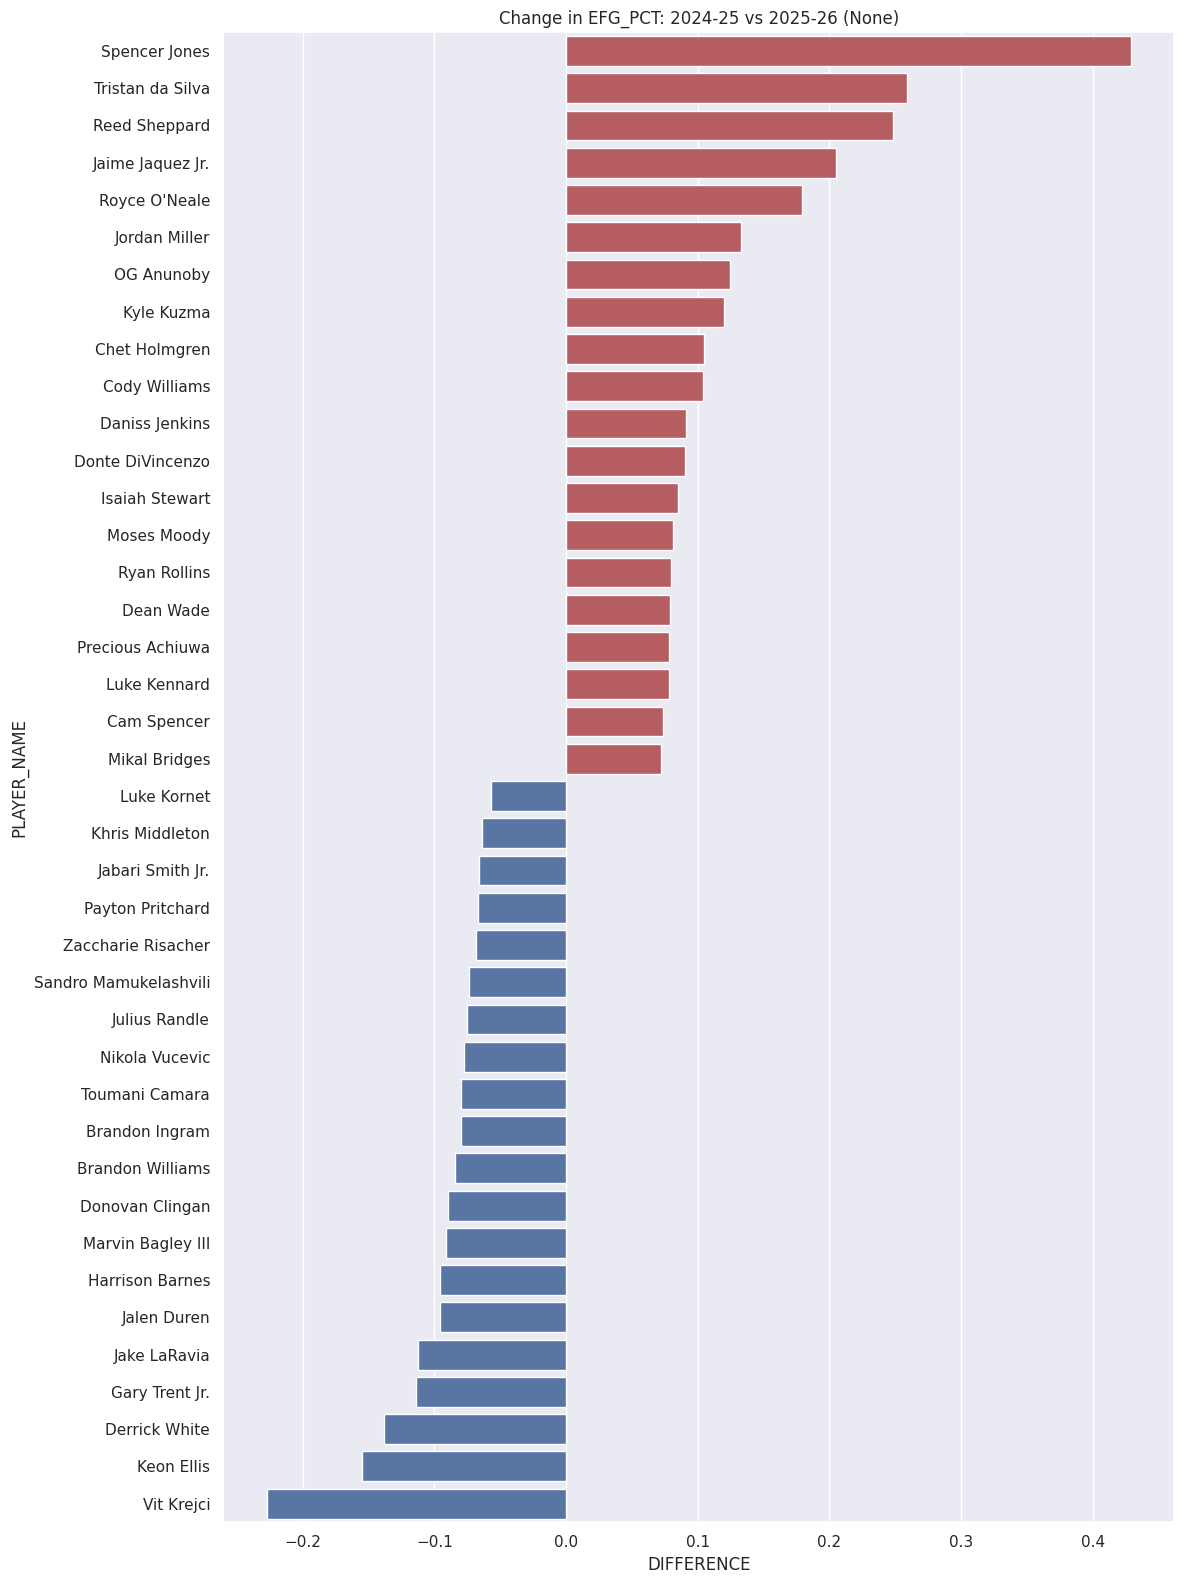

In [ ]:
filters = [
    "SEASON_TYPE == 'Regular Season'",
    "GP >= 58",
    "MIN >= 20"
]
df_results, fig = analyze_player_changes(
    df=df_master,
    compare_col='SEASON',
    base='2024-25',
    comp='2025-26',
    stat_column='EFG_PCT',
    query_conditions=filters,
    season_filter=None,# ← add this
    palette='coolwarm_r',
    n=20
)

## Season to Playoffs Comparison

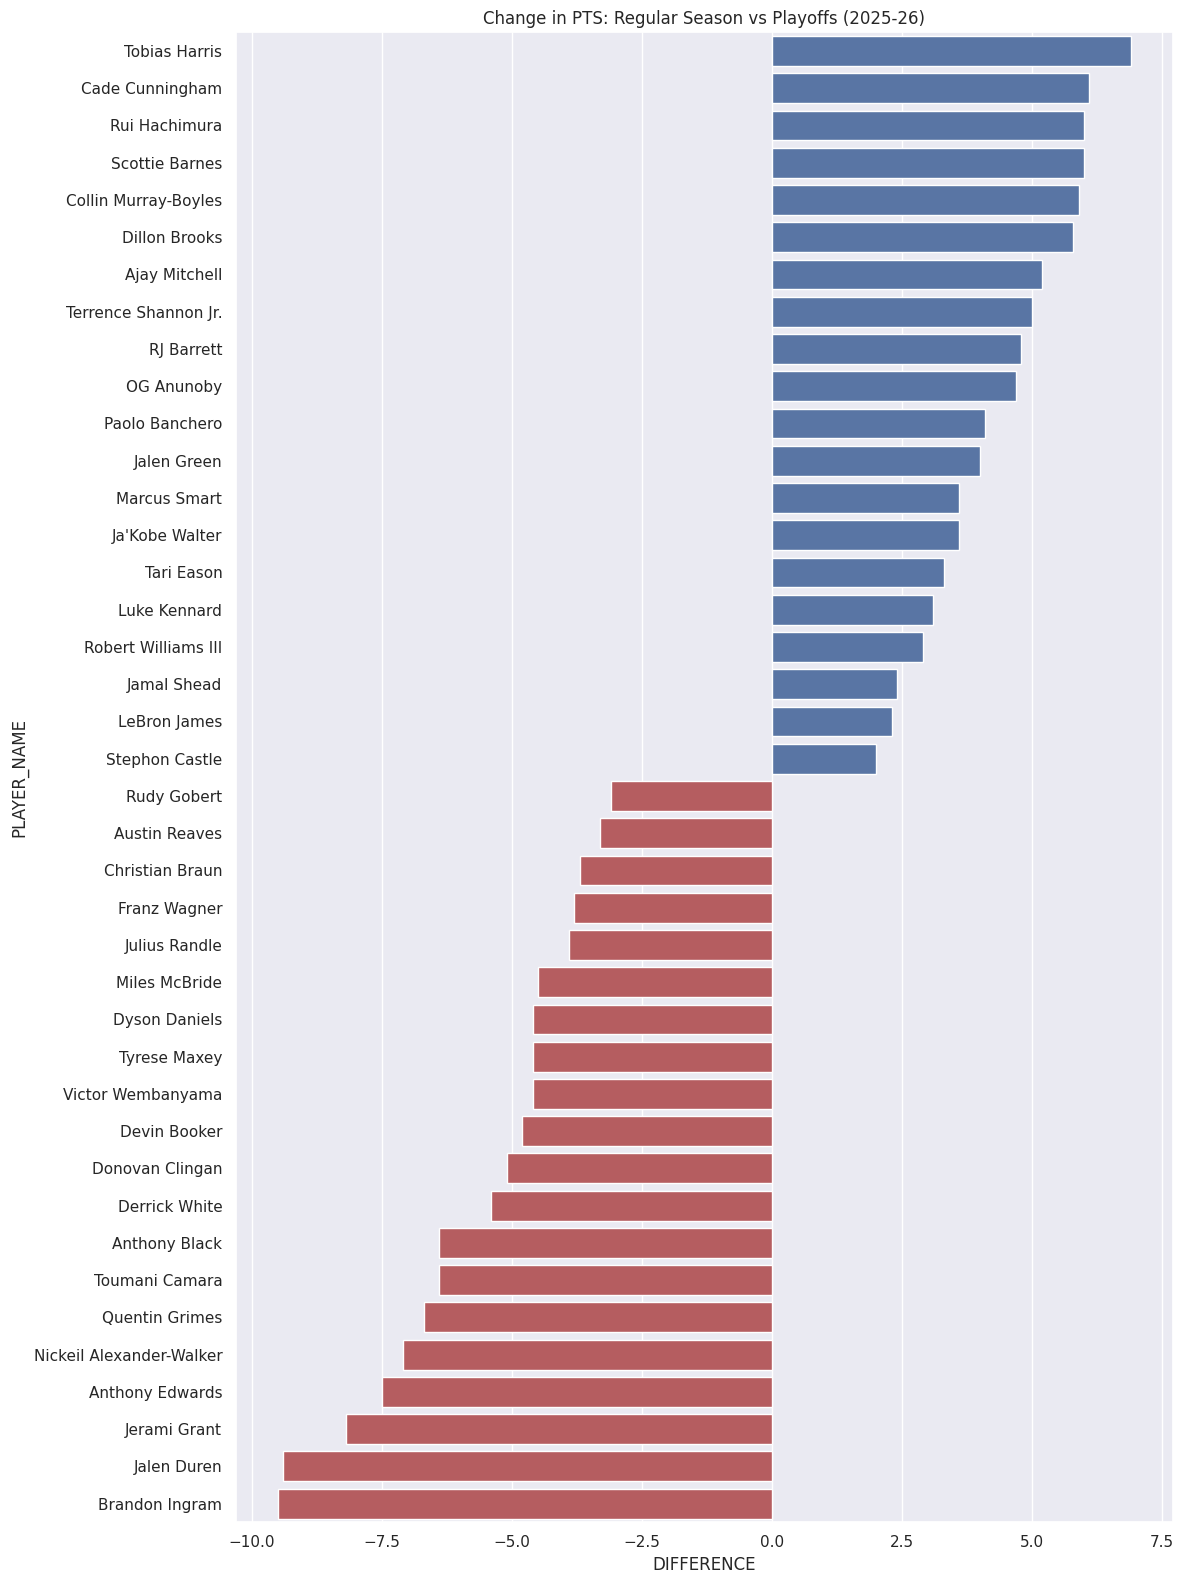

In [ ]:
# Define your filters clearly
filters = [
    "MIN >= 20",
    "GP >= 4",
    # "FG3A >= 2"
]

# Call the function
df_results, fig = analyze_player_changes(
    df=df_master,
    compare_col='SEASON_TYPE',
    base='Regular Season',
    comp='Playoffs',
    season_filter='2025-26',  # locks to one season internally
    stat_column='PTS',
    query_conditions=filters,
    palette='coolwarm',
    n=20
)

## Interactive Leaderboard

In [ ]:
plot = plot_interactive_barh(
    df=df_master.reset_index(), # reset_index if your data is MultiIndexed
    x_col='EFG_PCT',
    y_col='PLAYER_NAME',
    season='2025-26',
    season_type = 'Playoffs',
    title="Interactive EFG% Leaderboard",
    query_condition="MIN >= 20"
)

plot

## Scatter Plot

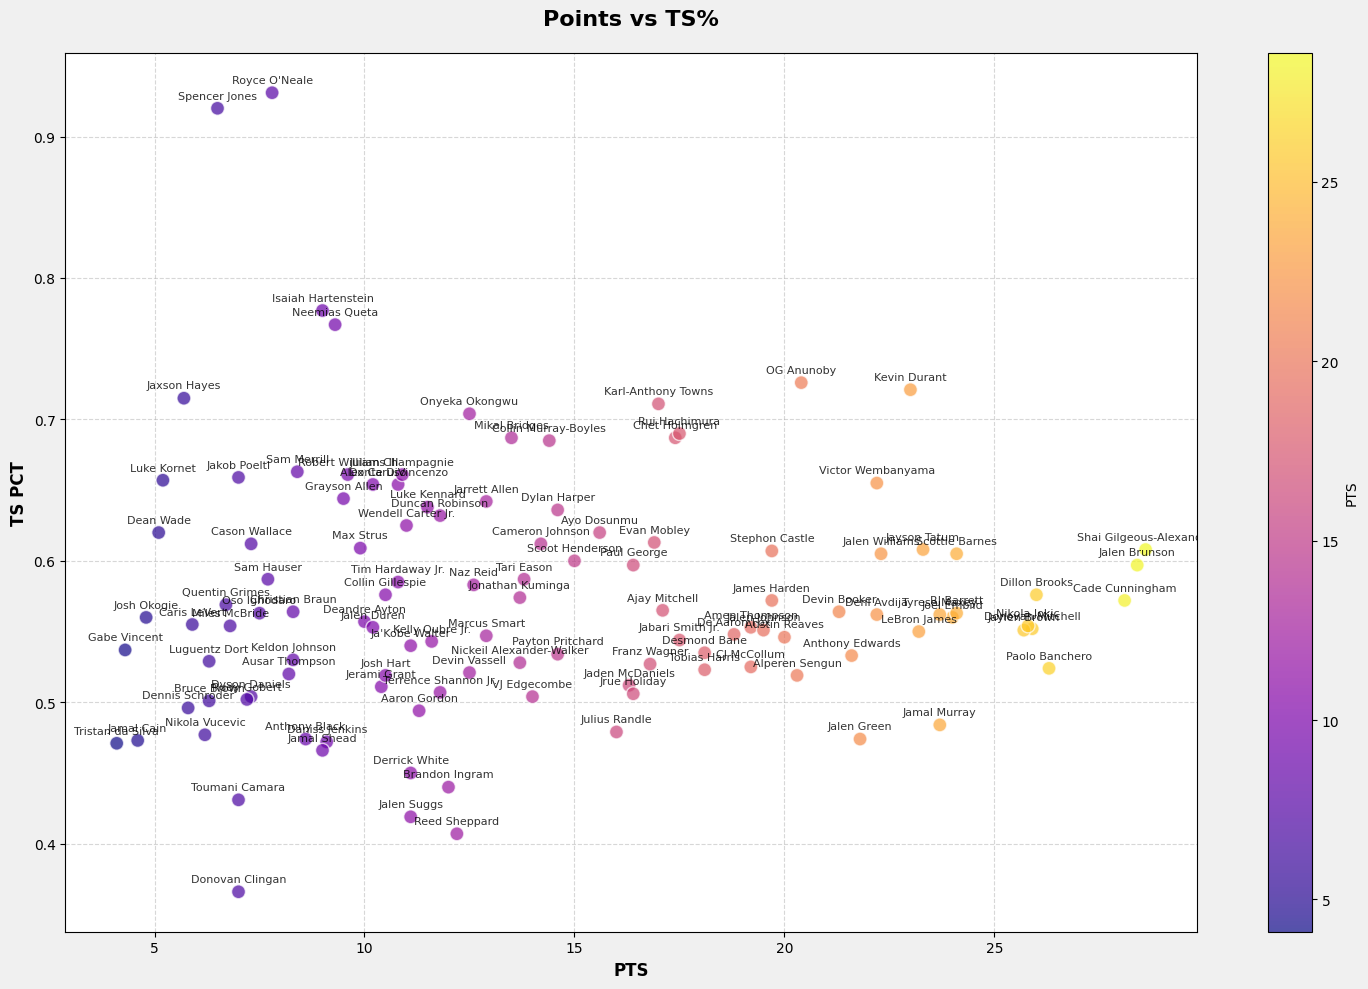

In [ ]:
scatter_nba_stats(df_master, 'PTS', 'TS_PCT', '2025-26',
                  season_type = 'Playoffs',
                  color_stat='PTS', min_min=15,
                  title='Points vs TS%')

## Violin Plot

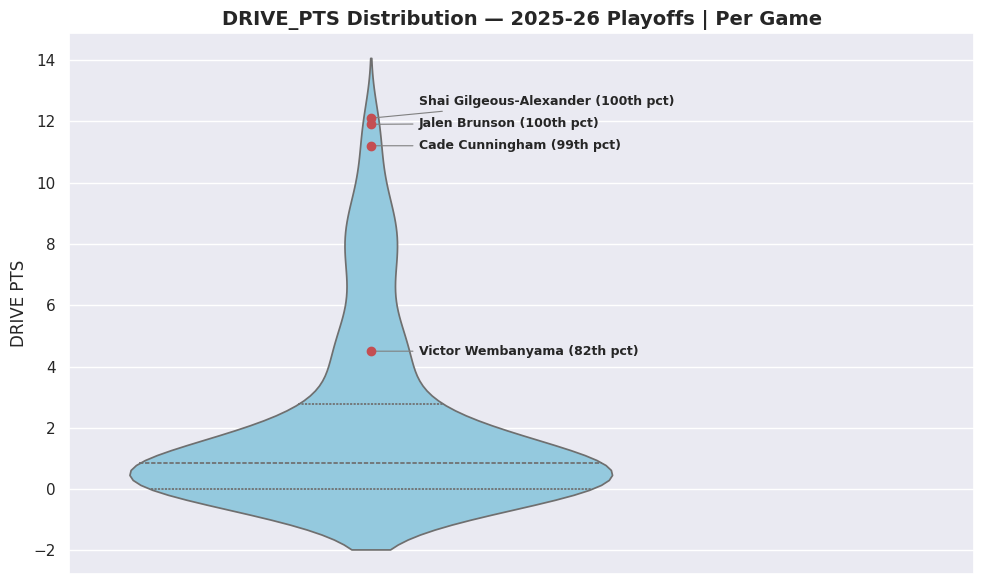

In [ ]:
plot_percentile_violin(
    df_master,
    stat="DRIVE_PTS",
    season="2025-26",
    season_type="Playoffs",
    highlight_players=[
        "Cade Cunningham",
        "Victor Wembanyama",
        "Shai Gilgeous-Alexander",
        "Jalen Brunson"
    ],
    min_label_gap=0.06
)

## Horizontal Stack Distribution Plot

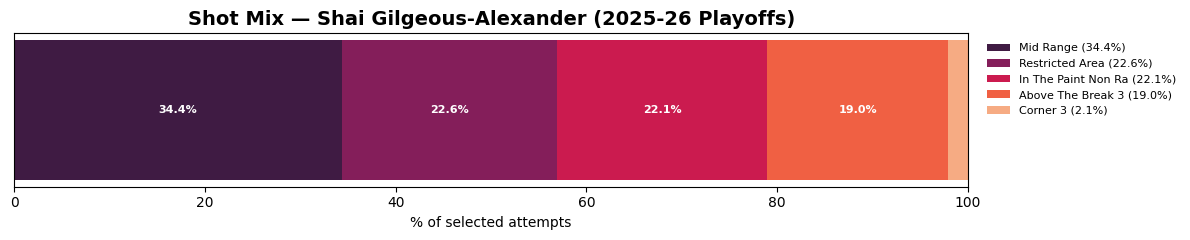

In [ ]:
plot_shot_mix(
    df_master,
    player_name="Shai Gilgeous-Alexander",
    season="2025-26",
    season_type="Playoffs",
    attempt_cols=SHOT_LOCATION_FGA_COLS
)

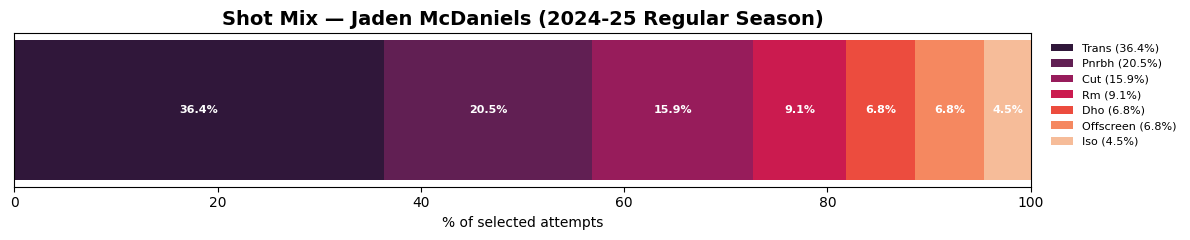

In [ ]:
plot_shot_mix(
    df_master,
    player_name="Jaden McDaniels",
    season="2024-25",
    season_type="Regular Season",
    attempt_cols=PLAY_TYPE_FGA_COLS
)

## Stat Over the Years

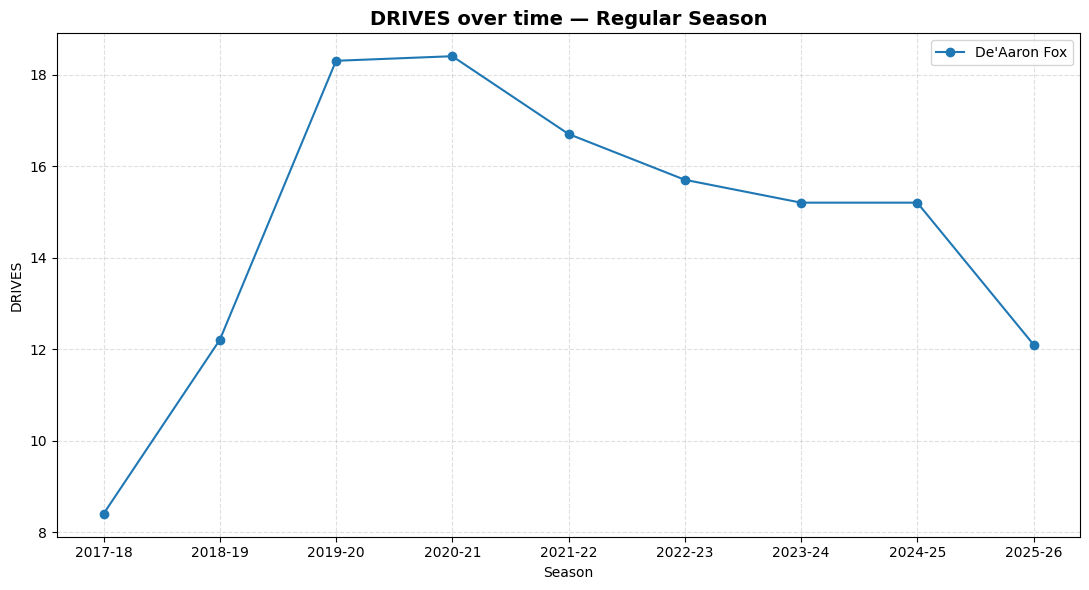

In [ ]:
plot_stat_over_time(df_master, ["De'Aaron Fox"], "DRIVES")

In [ ]:
fox = df_master.reset_index()
fox = fox[fox['PLAYER_NAME'] == "De'Aaron Fox"]
fox[['SEASON','SEASON_TYPE','TEAM_ABBREVIATION','PTS','Restricted_Area_FGA', 'Mid_Range_FGA','AVG_SEC_PER_TOUCH']].sort_values('SEASON')

,SEASON,SEASON_TYPE,TEAM_ABBREVIATION,PTS,Restricted_Area_FGA,Mid_Range_FGA,AVG_SEC_PER_TOUCH
1710,2017-18,Regular Season,SAC,11.6,3.0,3.3,4.65
2458,2018-19,Regular Season,SAC,17.3,4.6,2.7,4.53
3207,2019-20,Regular Season,SAC,21.1,6.2,1.8,5.26
3980,2020-21,Regular Season,SAC,25.2,5.6,3.0,5.16
4753,2021-22,Regular Season,SAC,23.2,4.8,3.6,4.57
5272,2022-23,Playoffs,SAC,27.4,2.6,3.9,4.94
5554,2022-23,Regular Season,SAC,25.0,3.9,3.4,5.04
6326,2023-24,Regular Season,SAC,26.6,3.5,3.0,4.68
7118,2024-25,Regular Season,SAS,23.5,NaN,NaN,4.18
7608,2025-26,Playoffs,SAS,15.9,3.4,1.5,4.35


In [ ]:
df_master['Restricted_Area_FGA']

SEASON   SEASON_TYPE     PLAYER_NAME      PLAYER_ID  TEAM_ABBREVIATION  TEAM_ID   
2015-16  Playoffs        Aaron Harrison   1626151    CHA                1610612766    0.0
                         Al Horford       201143     ATL                1610612737    3.6
                         Al Jefferson     2744       CHA                1610612766    4.4
                         Al-Farouq Aminu  202329     POR                1610612757    3.1
                         Allen Crabbe     203459     POR                1610612757    0.8
                                                                                     ... 
2025-26  Regular Season  Zach LaVine      203897     SAC                1610612758    NaN
                         Zeke Nnaji       1630192    DEN                1610612743    NaN
                         Ziaire Williams  1630533    BKN                1610612751    NaN
                         Zion Williamson  1629627    NOP                1610612740    NaN
                         Zyon Pullin      1642389    MIN                1610612750    NaN
Name: Restricted_Area_FGA, Length: 8373, dtype: float64

In [ ]:
sl = fetch_nba_shot_locations(['2024-25'], season_type='Regular Season')
sl.reset_index().query("PLAYER_NAME == \"De'Aaron Fox\"")[['TEAM_ABBREVIATION','Restricted_Area_FGA']]

Fetching Shot Locations for 2024-25 (Regular Season)...
📂 Loading cache: shot_locations_2024-25_regular_season_pergame.parquet


KeyError: "['Restricted_Area_FGA'] not in index"

In [ ]:
print(sl.columns.tolist())

["'',_np.str_'PLAYER_ID'", "'',_np.str_'PLAYER_NAME'", "'',_np.str_'TEAM_ID'", "'',_np.str_'TEAM_ABBREVIATION'", "'',_np.str_'AGE'", "'',_np.str_'NICKNAME'", "np.str_'Restricted_Area',_np.str_'FGM'", "np.str_'Restricted_Area',_np.str_'FGA'", "np.str_'Restricted_Area',_np.str_'FG_PCT'", "np.str_'In_The_Paint_Non_RA',_np.str_'FGM'", "np.str_'In_The_Paint_Non_RA',_np.str_'FGA'", "np.str_'In_The_Paint_Non_RA',_np.str_'FG_PCT'", "np.str_'Mid_Range',_np.str_'FGM'", "np.str_'Mid_Range',_np.str_'FGA'", "np.str_'Mid_Range',_np.str_'FG_PCT'", "np.str_'Left_Corner_3',_np.str_'FGM'", "np.str_'Left_Corner_3',_np.str_'FGA'", "np.str_'Left_Corner_3',_np.str_'FG_PCT'", "np.str_'Right_Corner_3',_np.str_'FGM'", "np.str_'Right_Corner_3',_np.str_'FGA'", "np.str_'Right_Corner_3',_np.str_'FG_PCT'", "np.str_'Above_the_Break_3',_np.str_'FGM'", "np.str_'Above_the_Break_3',_np.str_'FGA'", "np.str_'Above_the_Break_3',_np.str_'FG_PCT'", "np.str_'Backcourt',_np.str_'FGM'", "np.str_'Backcourt',_np.str_'FGA'", "np.s

In [ ]:
sl = fetch_nba_shot_locations(['2024-25'], season_type='Regular Season', force_refresh=True)
print('Restricted_Area_FGA' in sl.columns)   # should be True now
sl.reset_index().query("PLAYER_NAME == \"De'Aaron Fox\"")[['TEAM_ABBREVIATION','Restricted_Area_FGA']]

Fetching Shot Locations for 2024-25 (Regular Season)...
🌐 Fetching fresh: shot_locations_2024-25_regular_season_pergame.parquet
💾 Saved cache: shot_locations_2024-25_regular_season_pergame.parquet
True


,TEAM_ABBREVIATION,Restricted_Area_FGA
126,SAS,3.9


# Player Profiles

In [ ]:
PROFILE_GROUPS_V1 = {
    "Scoring Volume": [
        "PTS",
        "FGA",
        "USG_PCT",
        "MIN",
    ],

    "Scoring Efficiency": [
        "EFG_PCT",
        "TS_PCT",
        "FG_PCT",
        "FG3_PCT",
        "FT_PCT",
    ],

    "Rim Pressure": [
        "Restricted_Area_FGA",
        "Restricted_Area_FG_PCT",
        "DRIVE_PTS",
        "DRIVE_FGA",
        "FTA",
        "FT_RATE",
        "POST_TOUCHES",
        "DRIVES"
        "PAINT_TOUCHES"
    ],

    "Self-Created Shooting": [

        "UAST_FGM_PCT",
    ],

    "Playmaking": [
        "AST",
        "AST_PCT",
        "AST_TO",
        "SECONDARY_AST",
        "POTENTIAL_AST",
        "FT_AST",
        "PASSES_MADE"
        "AST_POINTS_CREATED",
        "DRIVE_AST"
    ],

    "Rebounding": [
        "REB",
        "REB_PCT",
        "OREB_PCT",
        "DREB_PCT",
        "DREB_CONTEST_PCT",
        'OREB_CONTEST_PCT',
        'OREB_CHANCE_PCT',
        'DREB_CHANCE_PCT'
    ],

    "Defense": [
        "D_FGA",
        "D_FG_PCT",
        "PCT_PLUSMINUS",
        "STL",
        "BLK",
        "DEF_RIM_FGA",
        "DEF_RIM_FG_PCT"
    ],

    "On-Ball Creation": [
        "ISO_PPP",
        "PNRBH_PPP",
        "DHO_PPP",
        "PULL_UP_FGA",
        "PULL_UP_FG_PCT",
        "PULL_UP_FG3A",
        "PULL_UP_FG3_PCT",
        "DRIBBLE_3_6_FGA",
        "DRIBBLE_7_PLUS_FGA",
        "AVG_SEC_PER_TOUCH"
    ],

    "Off-Ball Usage": [
        "SPOT_FGA",
        "OFFSCREEN_FGA",
        "CUT_FGA",
        "TRANS_FGA",
        "CATCH_SHOOT_FG3A",
    ],
}

In [ ]:
df_master['PCT_BLK']

SEASON   SEASON_TYPE     PLAYER_NAME      PLAYER_ID  TEAM_ABBREVIATION  TEAM_ID   
2024-25  Playoffs        AJ Green         1631260    MIL                1610612749    0.111
                         Aaron Gordon     203932     DEN                1610612743    0.119
                         Aaron Holiday    1628988    HOU                1610612745    0.000
                         Aaron Nesmith    1630174    IND                1610612754    0.214
                         Aaron Wiggins    1630598    OKC                1610612760    0.194
                                                                                      ...  
2025-26  Regular Season  Zach LaVine      203897     SAC                1610612758    0.102
                         Zeke Nnaji       1630192    DEN                1610612743    0.375
                         Ziaire Williams  1630533    BKN                1610612751    0.174
                         Zion Williamson  1629627    NOP                1610612740    0.152
                         Zyon Pullin      1642389    MIN                1610612750    0.000
Name: PCT_BLK, Length: 1600, dtype: float64